# Sytox file Saving

In [ ]:
import pandas as pd
import os
import re

# Directory containing files
folder = '/sise/assafzar-group/assafzar/Esraa/AllFOVsSegmentation/PureColoniesTracks/'
folder_tiff = '/sise/assafzar-group/assafzar/Esraa/PureSingleCellCroppedAnnotated/FullDICSingleCellCropped/'
saving_dir = '/sise/assafzar-group/assafzar/Esraa/FullFOVsData/May2025Data/csv_files/'
# Find the CSV file
csv_files = [f for f in os.listdir(folder) if f.endswith('.csv') and 'track' in f.lower()]
for file in csv_files:
    csv_path = os.path.join(folder, file)
    # Extract text between 'MASK_' and the second appearance of '_'
    mask_texts = re.search(r'MASK_(.*?)_', file).group(1) if re.search(r'MASK_(.*?)_', file) else None
    print(mask_texts)
    mask_texts += '_'
    df_tracks = pd.read_csv(csv_path)
    print(df_tracks.columns)
    tif_files = [f for f in os.listdir(folder_tiff) if f.endswith('.tif')]
    results = []
    for tif_file in tif_files:
        if mask_texts not in tif_file:
            continue
        pattern = r'#(\d+).*?-tod-(\d+)'
        
        match = re.search(pattern, tif_file)
        if not match:
            continue

        track_id = int(match.group(1))
        tod = int(match.group(2)) 
        subset = df_tracks[(df_tracks['TrackID'] == track_id) & (df_tracks['t'] == tod)]

        if not subset.empty:
            x, y = subset.iloc[0][['x', 'y']]
            x, y = int(round(x)), int(round(y))
            results.append({'TrackID': track_id, 'cell_x': x, 'cell_y': y, 'death_time': tod})
        else:
            raise TypeError
            print(f"No match in CSV for TrackID {track_id} at time {tod}")

        # Convert to DataFrame for further analysis or saving
    results_df = pd.DataFrame(results)

    results_df.to_csv(os.path.join(saving_dir, mask_texts+'.csv'))


In [ ]:
import pandas as pd
import os
import re

# Directory containing files
folder = '/sise/assafzar-group/assafzar/Esraa/AllFOVsSegmentation/PureColoniesTracks/'
folder_tiff = '/sise/assafzar-group/assafzar/Esraa/PureSingleCellCroppedAnnotated/FullDICSingleCellCropped/'
saving_dir = '/sise/assafzar-group/assafzar/Esraa/FullFOVsData/May2025Data/csv_files/'
# Find the CSV file
file = 'MASK_3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath2_FITC_track.csv'
csv_path = os.path.join(folder, file)
# Extract text between 'MASK_' and the second appearance of '_'
mask_texts = re.search(r'MASK_(.*?)_FITC_track', file).group(1)

print(mask_texts)
mask_texts += '_'
df_tracks = pd.read_csv(csv_path)
print(df_tracks.columns)
tif_files = [f for f in os.listdir(folder_tiff) if f.endswith('.tif')]
results = []
for tif_file in tif_files:
    if mask_texts not in tif_file:
        continue
    pattern = r'#(\d+).*?-tod-(\d+)'
    
    match = re.search(pattern, tif_file)
    if not match:
        continue

    track_id = int(match.group(1))
    tod = int(match.group(2)) 
    subset = df_tracks[(df_tracks['TrackID'] == track_id) & (df_tracks['t'] == tod)]

    if not subset.empty:
        x, y = subset.iloc[0][['x', 'y']]
        x, y = int(round(x)), int(round(y))
        results.append({'TrackID': track_id, 'cell_x': x, 'cell_y': y, 'death_time': tod})
    else:
        raise TypeError
        print(f"No match in CSV for TrackID {track_id} at time {tod}")

    # Convert to DataFrame for further analysis or saving
results_df = pd.DataFrame(results)

results_df.to_csv(os.path.join(saving_dir, mask_texts+'.csv'))


In [21]:
meta_data_path = '/sise/assafzar-group/assafzar/Esraa/FullFOVsData/May2025Data/trailMay2025metadata.csv'
metadata_df = pd.read_csv(meta_data_path)

folder_csv = '/sise/assafzar-group/assafzar/Esraa/FullFOVsData/May2025Data/csv_files/' 
saving_dir = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_sytox'
# Find the CSV file
csv_files = [f for f in os.listdir(folder_csv) if f.endswith('.csv') and 'sytox' in f.lower()]
for csv_file in csv_files:
    csv_df = pd.read_csv(os.path.join(folder_csv, csv_file))
    # Check if part of the csv_file name (excluding 'sytox_based') is contained in the 'Filename' column of metadata_df
    csv_file_base = csv_file.split('_sytox')[0]
    search_str = '3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath2'
    subset = metadata_df[metadata_df['Filename'].str.contains(re.escape(csv_file_base), regex=True)]
    spatial_res, temporal_res = subset[['PhysicalSizeX', 'Time Interval (min)']].values[0]  # Replace 'Column1', 'Column2', 'Column3' with actual column names
    csv_df["death_time"] = (csv_df["death_time"] * temporal_res).round().astype(int)
    csv_df["cell_x"] = (csv_df["cell_x"] * spatial_res).round(3)
    csv_df["cell_y"] = (csv_df["cell_y"] * spatial_res).round(3)

    csv_df.to_csv(os.path.join(saving_dir, csv_file))


# Means distribution

In [29]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("/sise/assafzar-group/assafzar/Esraa/CellDeathQuantification/")
from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [18]:
def plot_histogram_with_lines(values, observed, shuffled_5_per, bins=30, title="Value Distribution", xlabel="Value", ylabel="Frequency", text=None, text_position=(0.5, 0.9)):
    """
    Plot a histogram of the given values with two vertical lines for precomputed values and optional text.

    Parameters:
    - values: list or array of 1000 numeric values
    - observed: float, position of the first vertical reference line
    - shuffled_5_per: float, position of the second vertical reference line
    - bins: int, number of histogram bins
    - title: str, title of the plot
    - xlabel: str, label for the x-axis
    - ylabel: str, label for the y-axis
    - text: str, optional text to display on the plot
    - text_position: tuple, position of the text in axes coordinates (x, y)
    """

    # Set colorblind-friendly palette
    sns.set_palette("colorblind")
    sns.set_context("talk")  # For better font sizes
    sns.set_style("whitegrid")

    # Create the histogram
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(values, bins=bins, kde=False, color=sns.color_palette("colorblind")[0])

    # Plot vertical lines
    plt.axvline(observed, color=sns.color_palette("colorblind")[2], linestyle="--", linewidth=2, label=f"observed = {observed:.2f}")
    plt.axvline(shuffled_5_per, color=sns.color_palette("colorblind")[1], linestyle="--", linewidth=2, label=f"shuffled 5% = {shuffled_5_per:.2f}")

    # Add text to the plot if provided
    if text:
        plt.text(text_position[0], text_position[1], text, fontsize=14, transform=plt.gca().transAxes, ha='center')

    # Axis labels and title
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)
    # Set x and y limits
    # plt.xlim(0, 550)
    plt.ylim(0, 100)
    # Tick label formatting
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Legend
    plt.legend(fontsize=12, loc="upper right")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


## Mean

0.1662476429918291


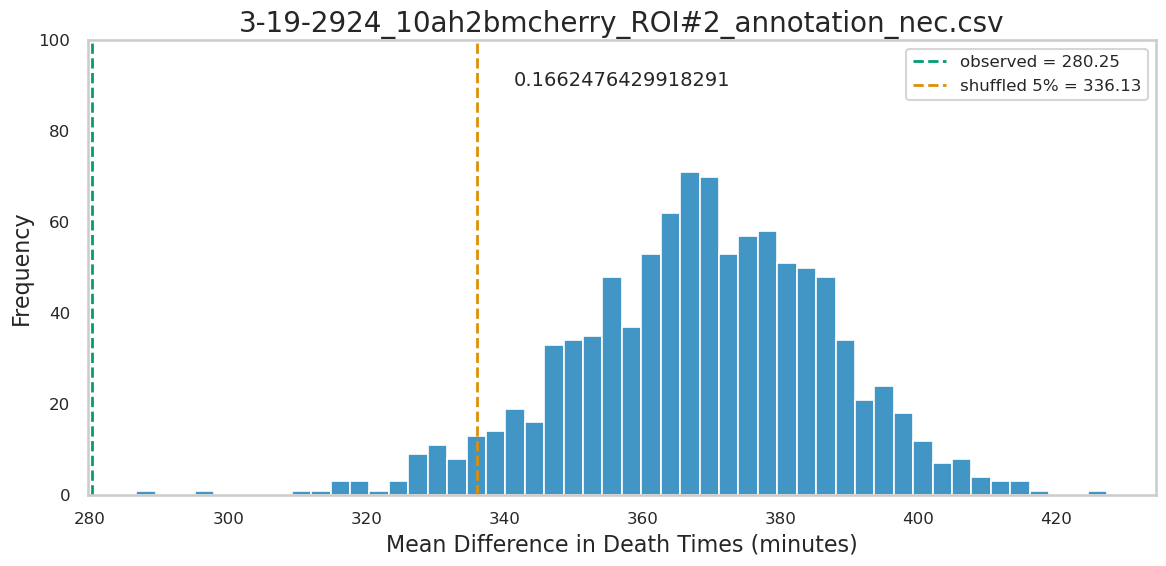

0.31029028656494234


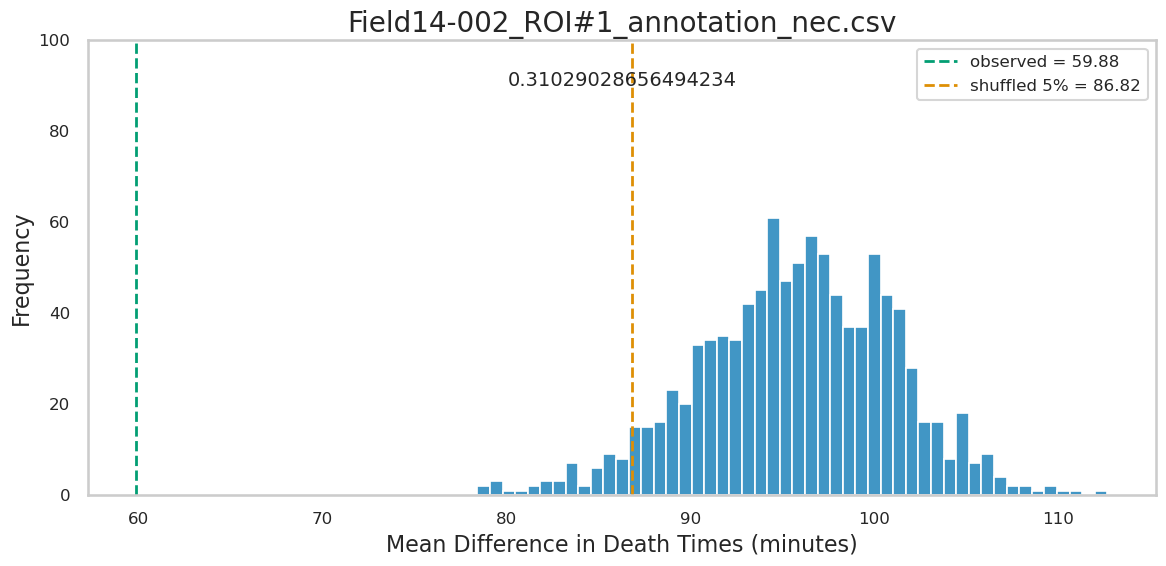

0.056338028169014086


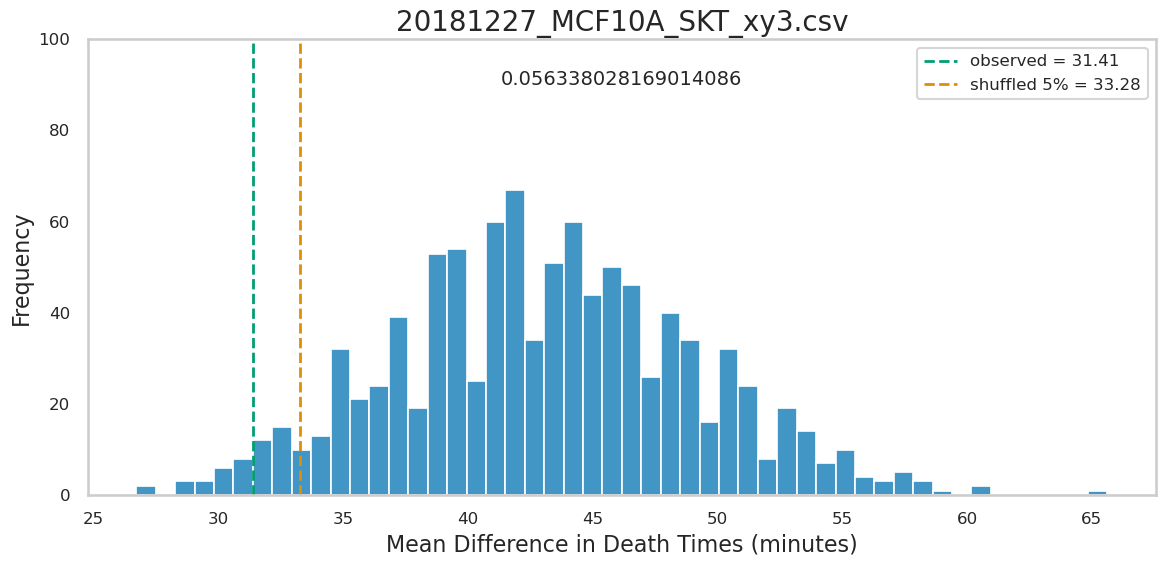

0.2972972972972973


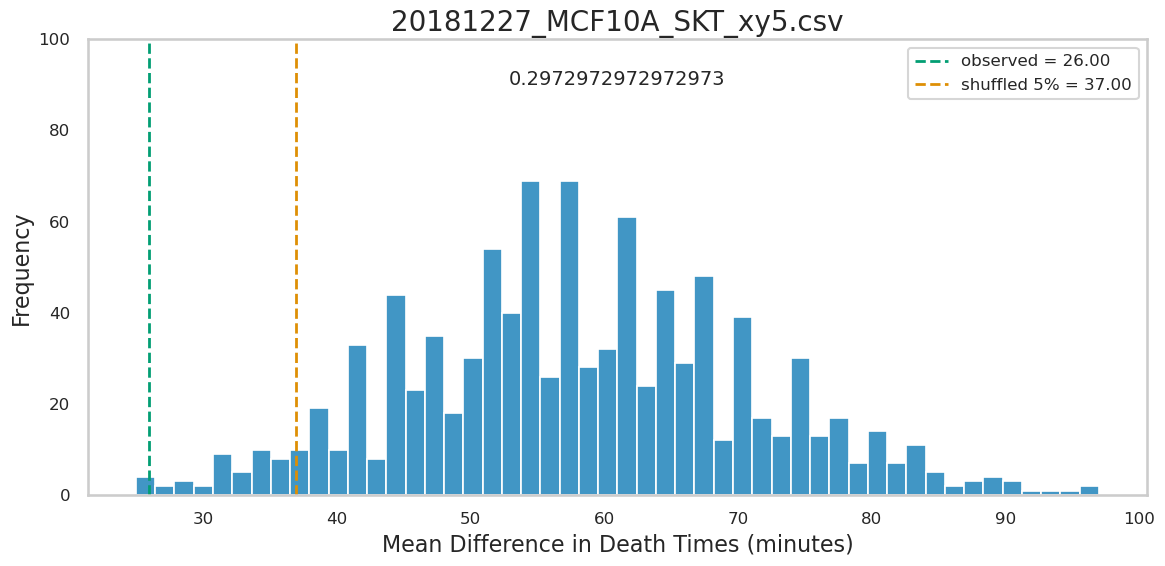

0.38329878141275214


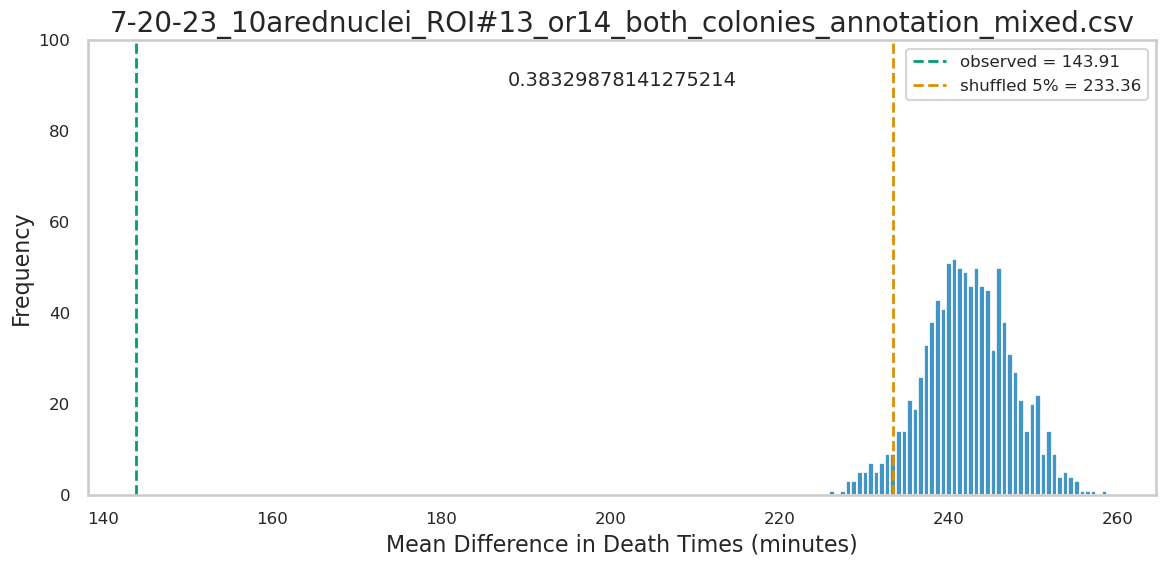

0.5768326804700615


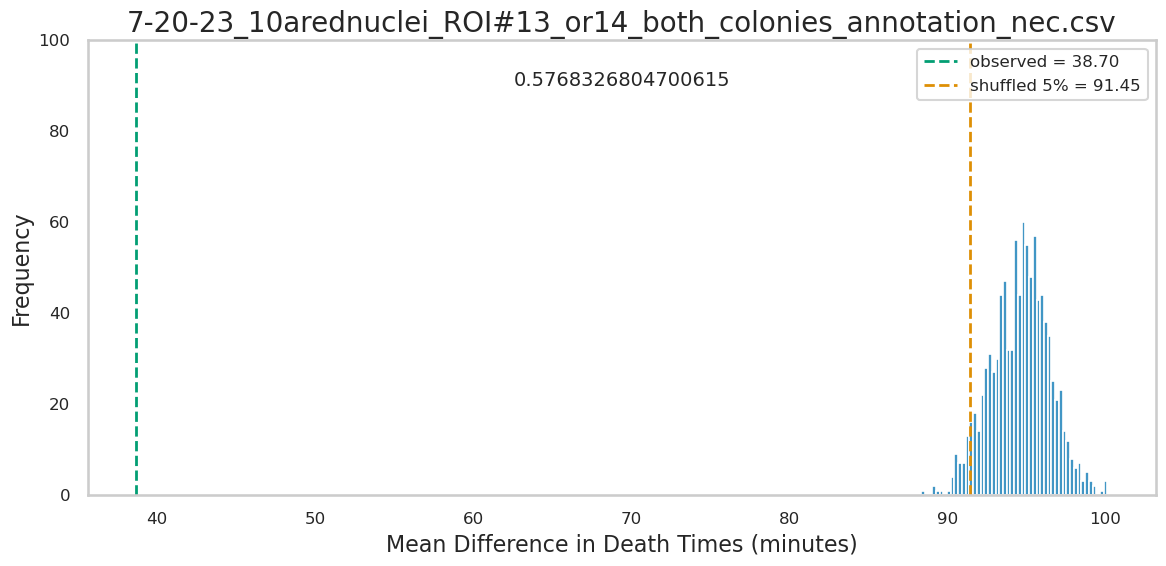

0.3683724367263994


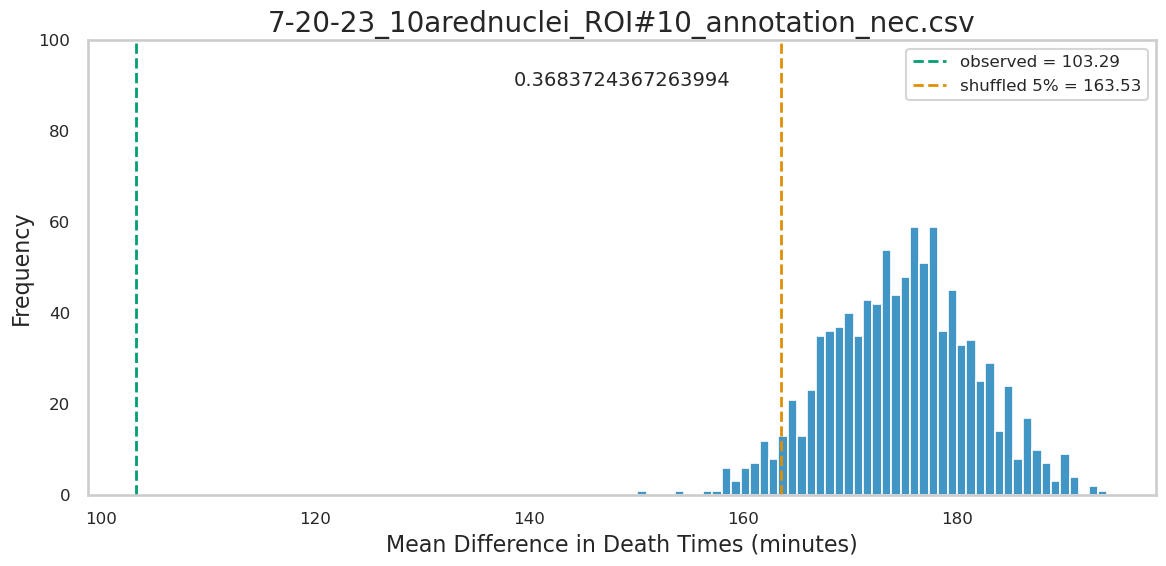

0.17093605546995377


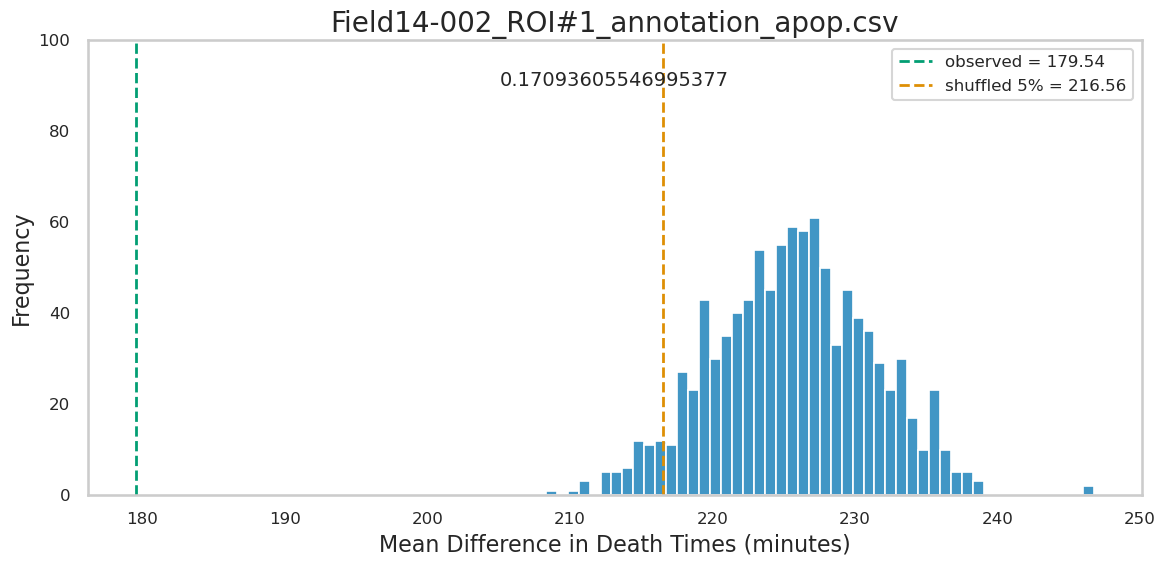

0.12307692307692306


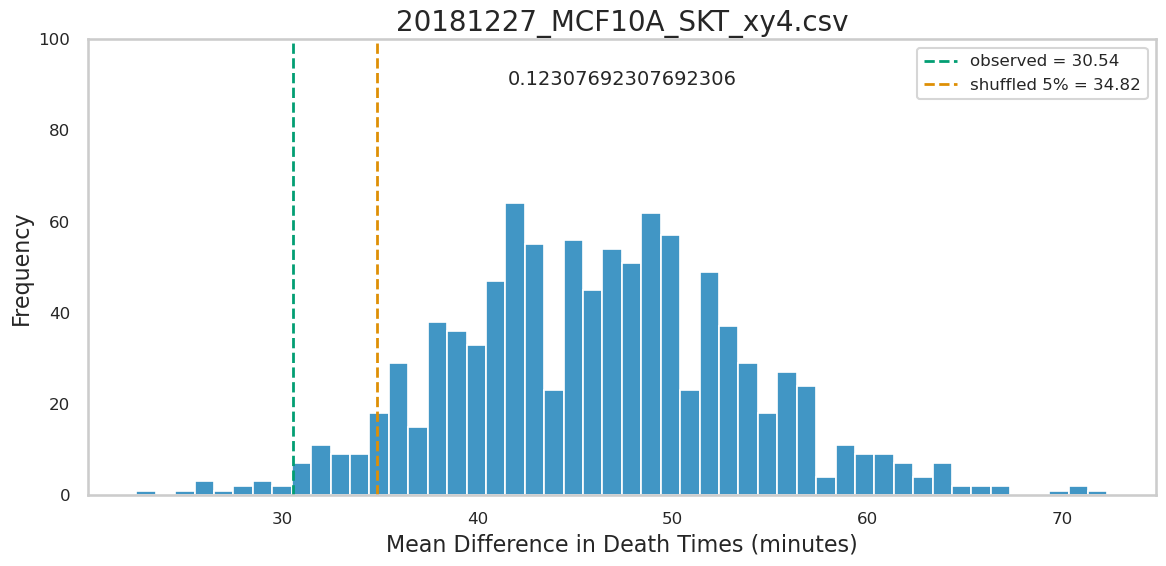

0.4412232084027751


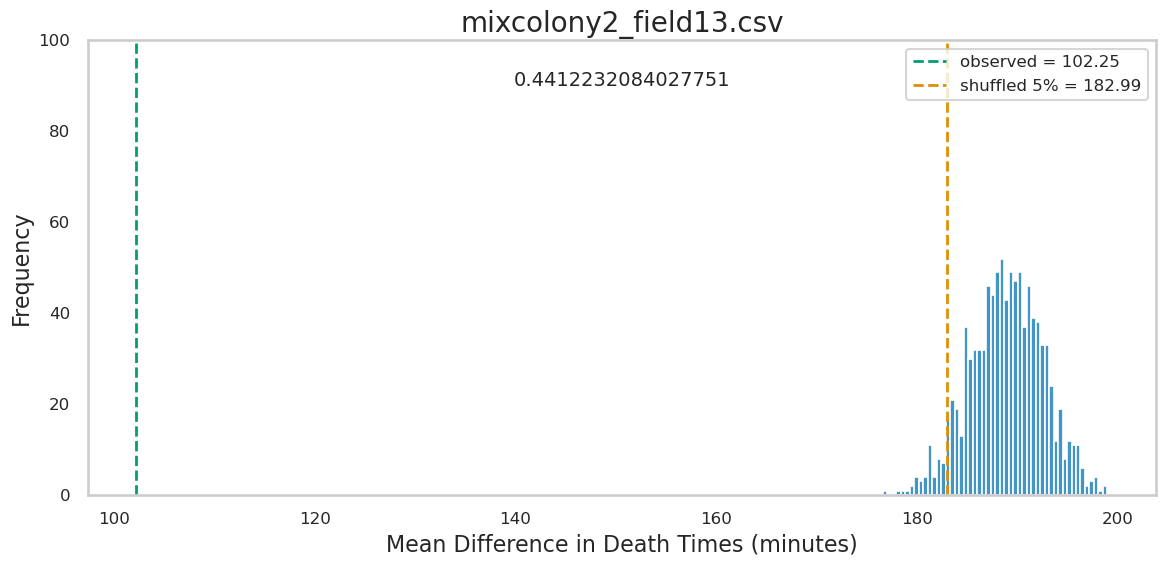

0.212785071676998


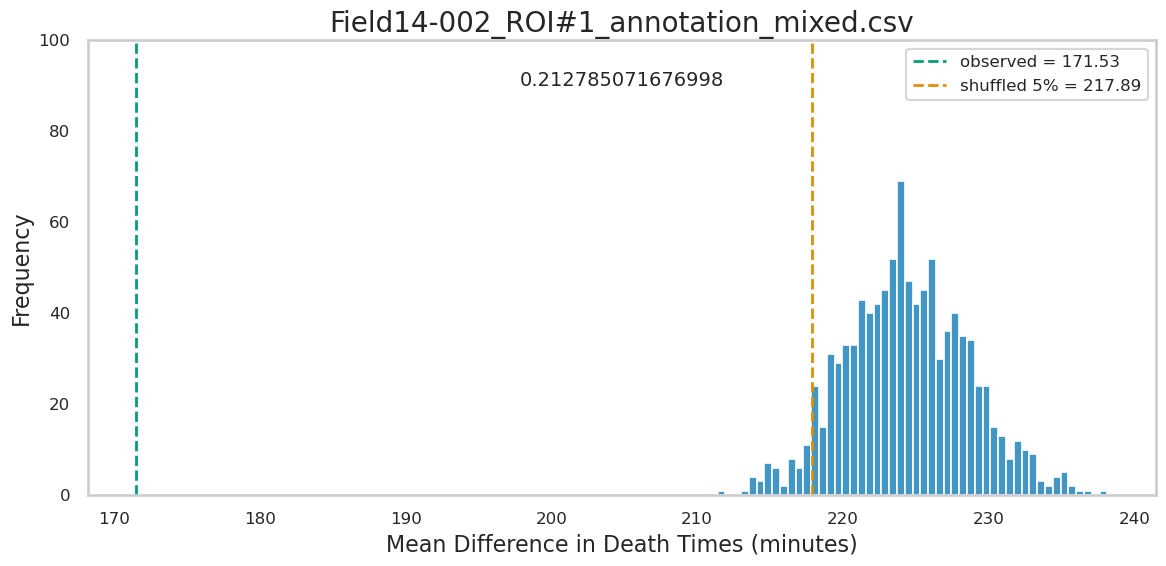

-0.5056542810985459


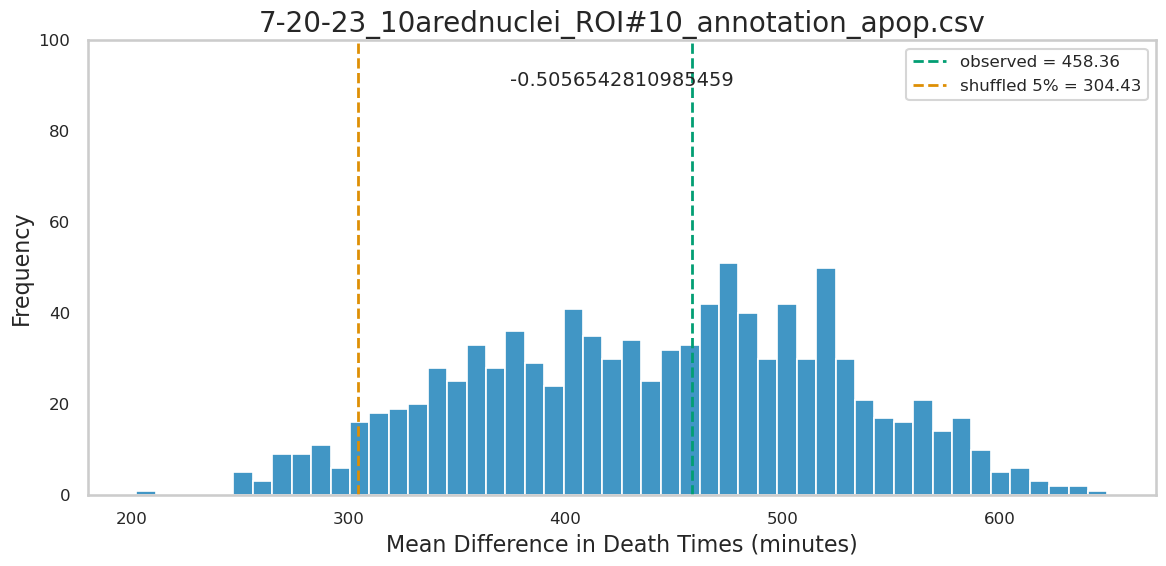

0.18440454506028284


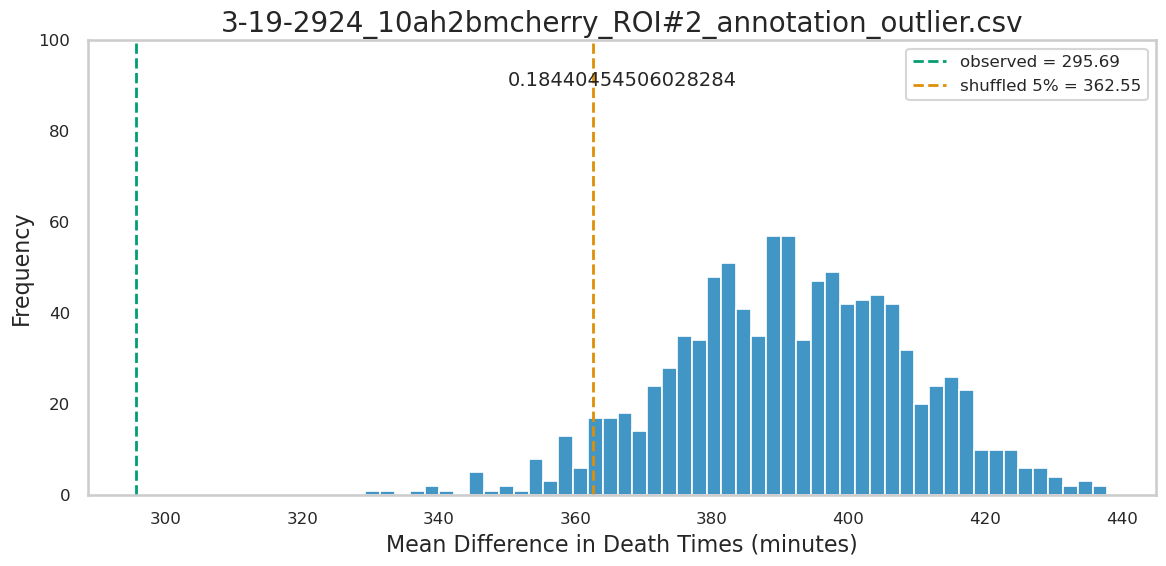

0.23745141118810206


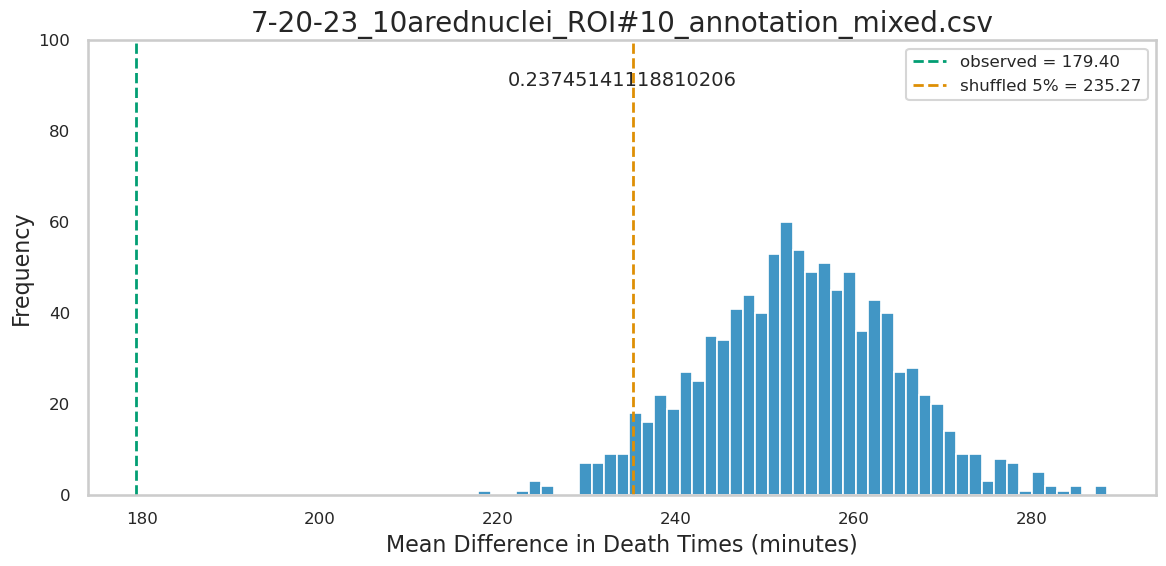

0.1717216590606194


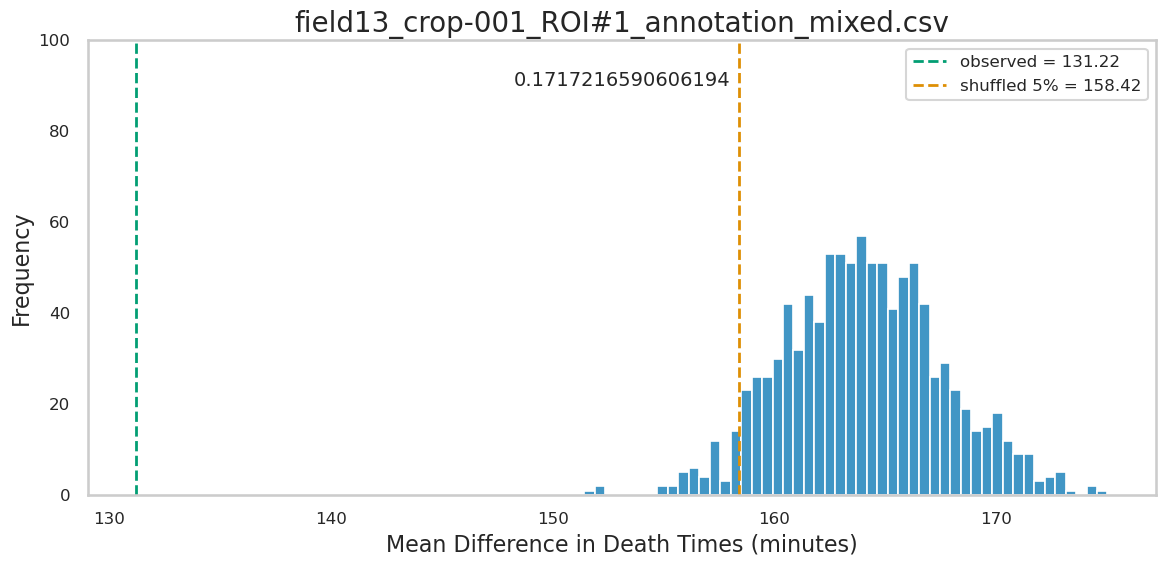

0.3135723039215687


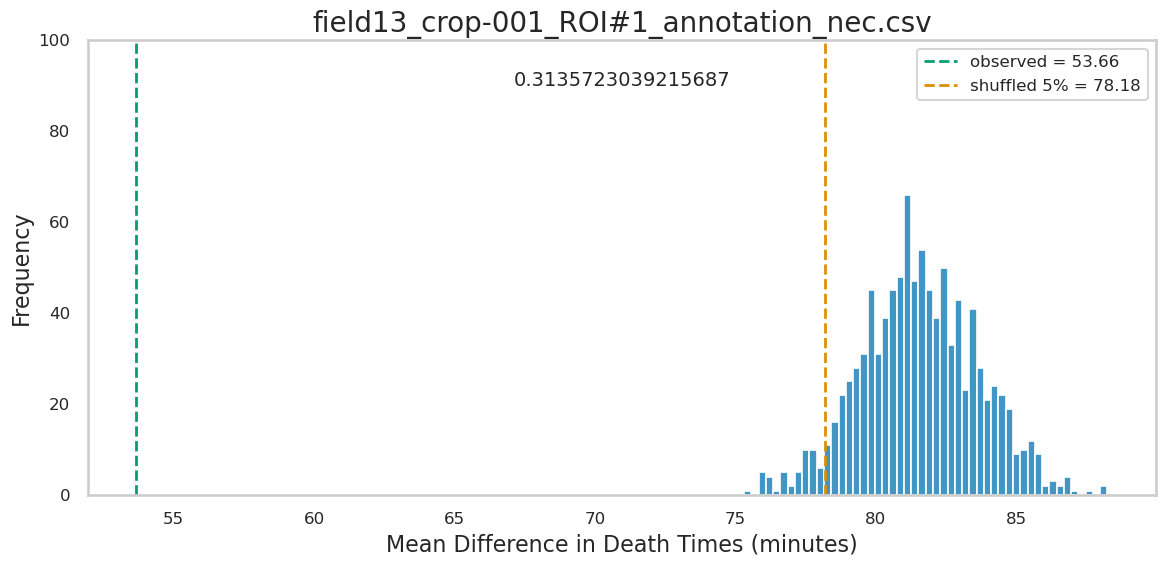

0.11943413729128027


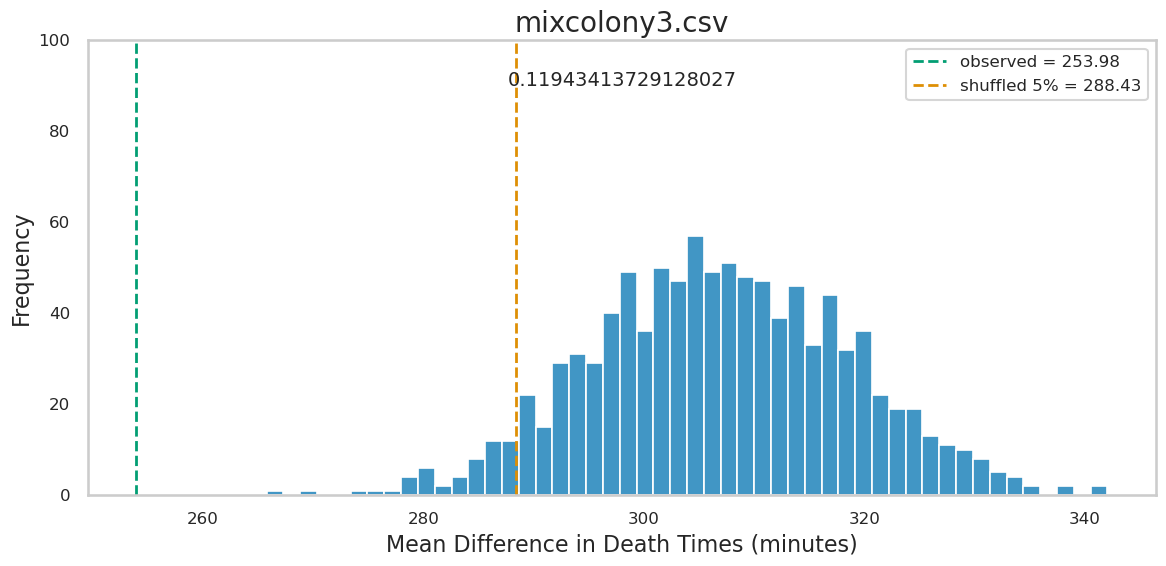

0.25195297686765267


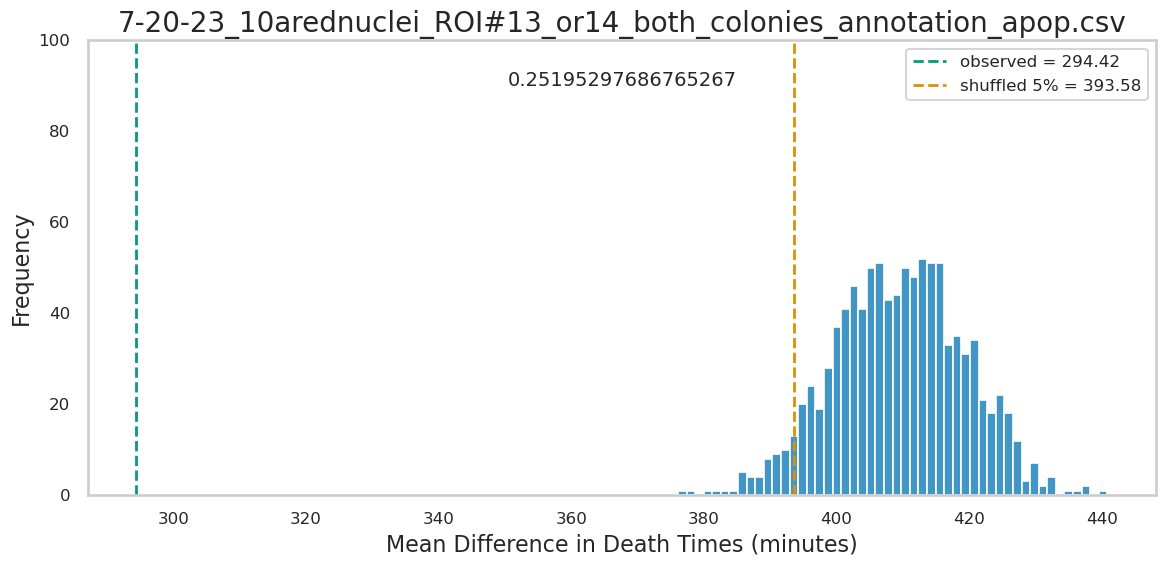

0.3712868588870116


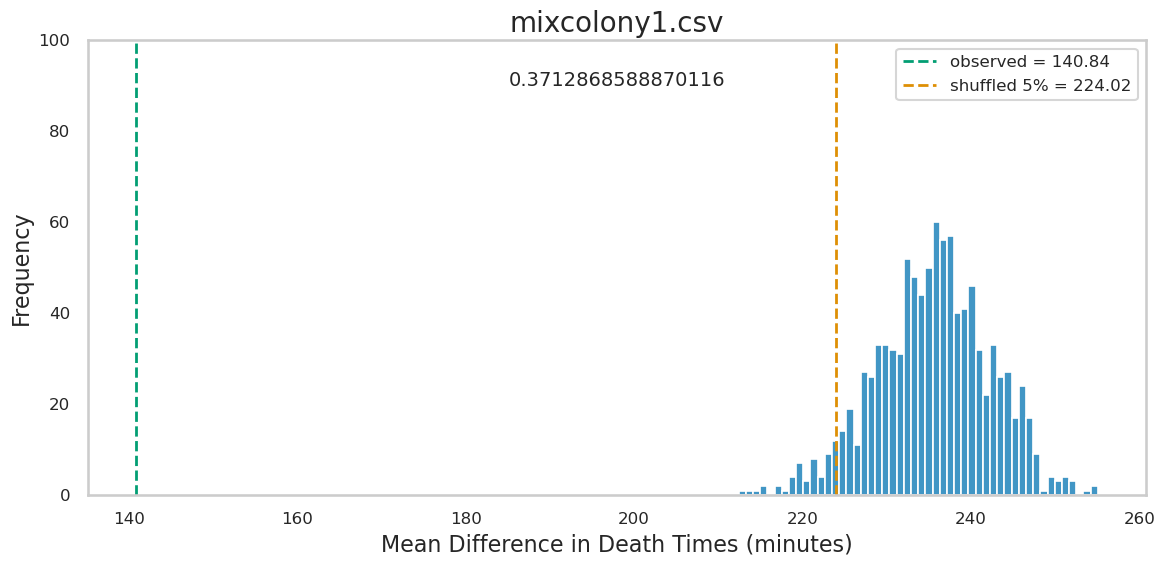

-86.0


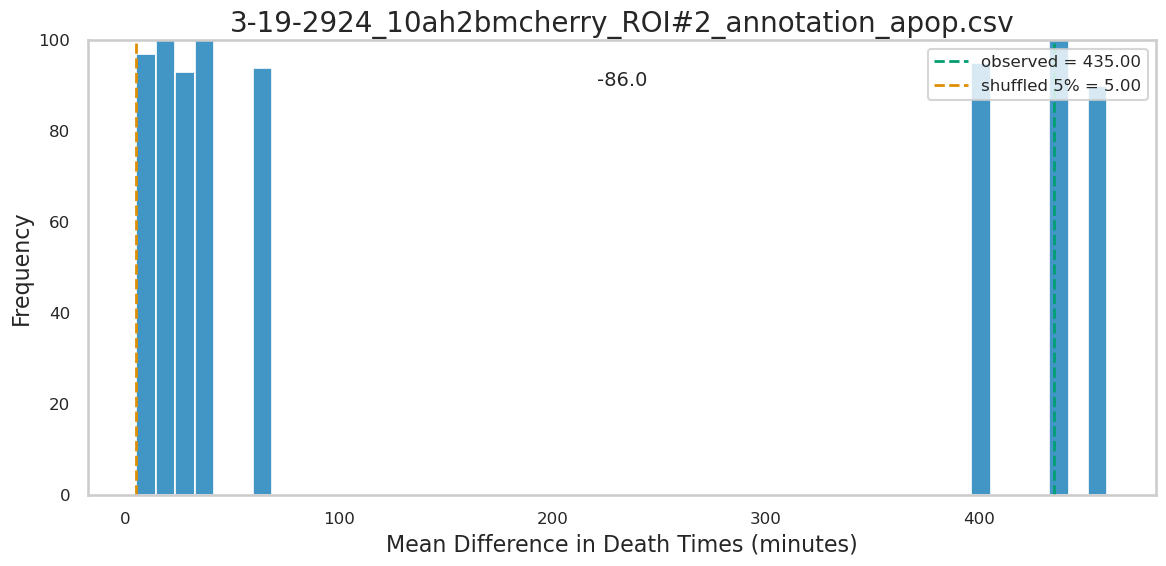

0.09260462095202752


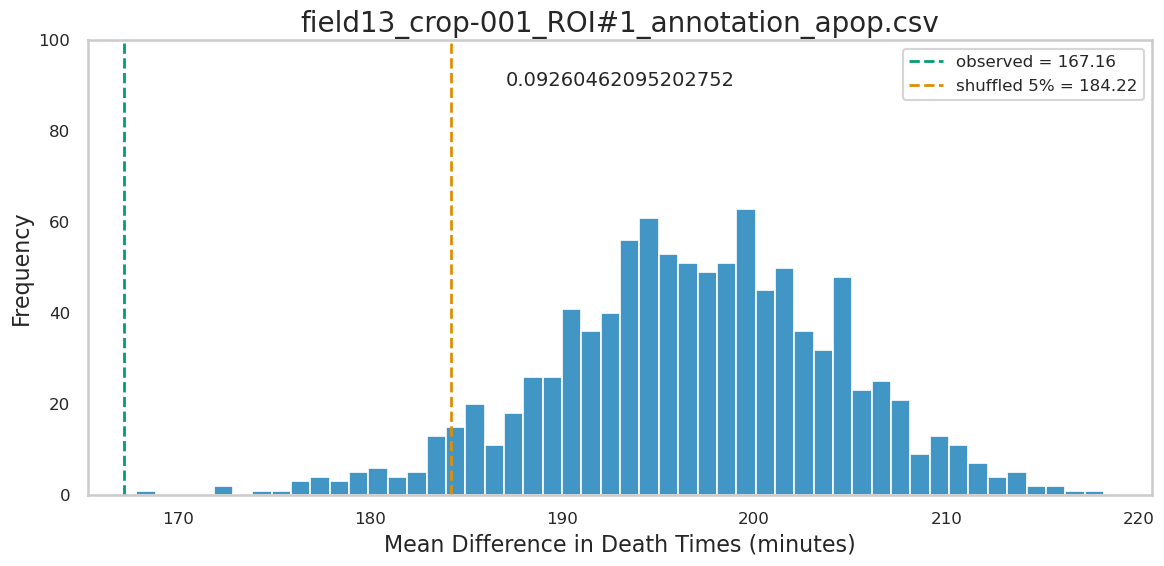

0.0028409090909090264


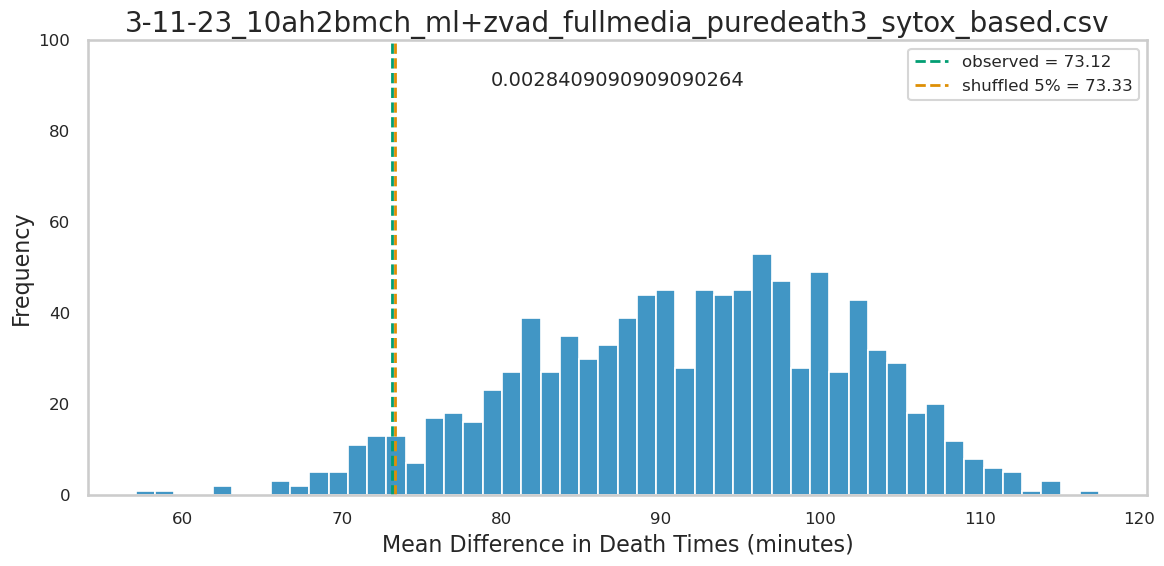

0.15524579282339623


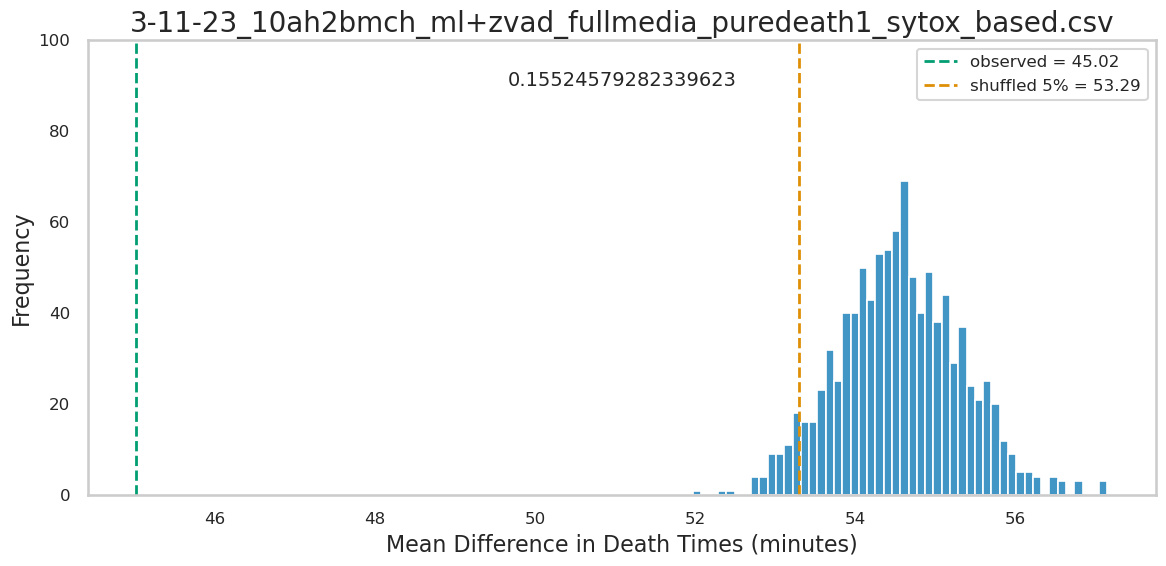

0.20129797051431148


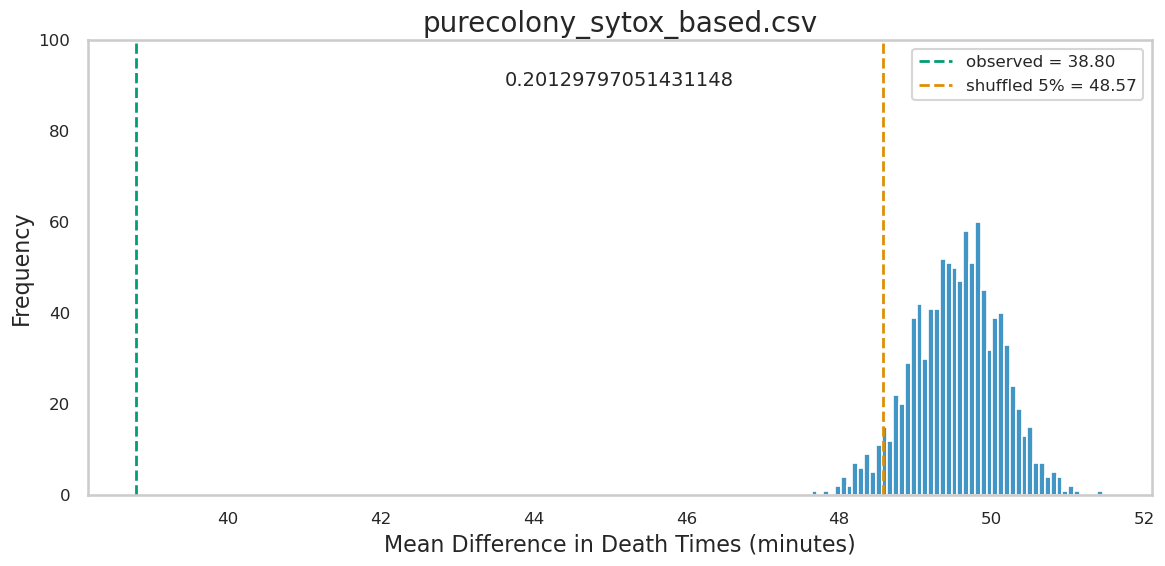

0.25599784347201


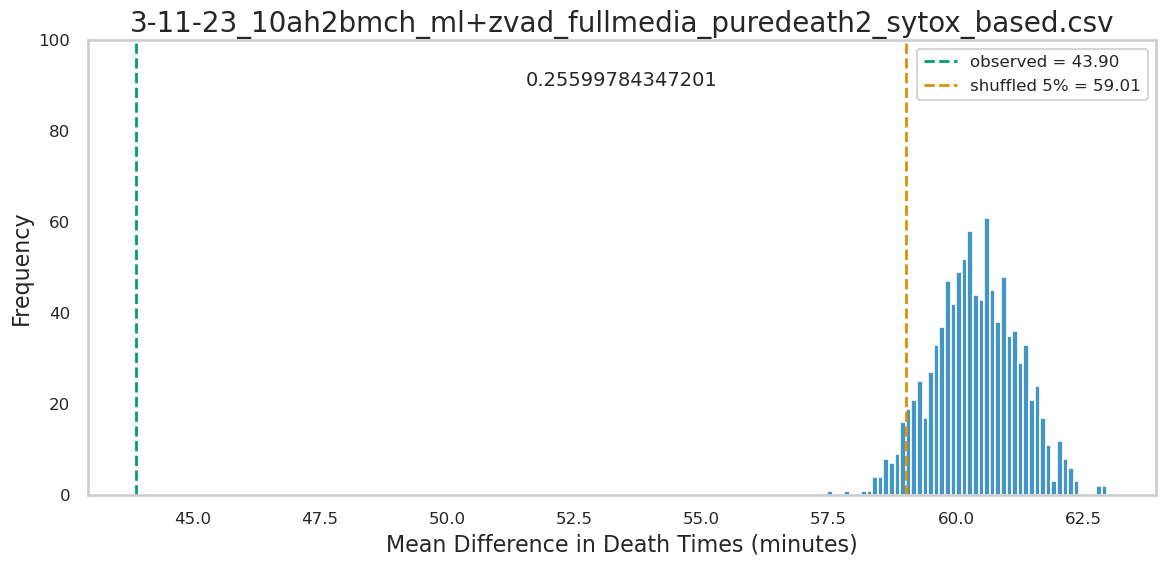

0.12743651471616055


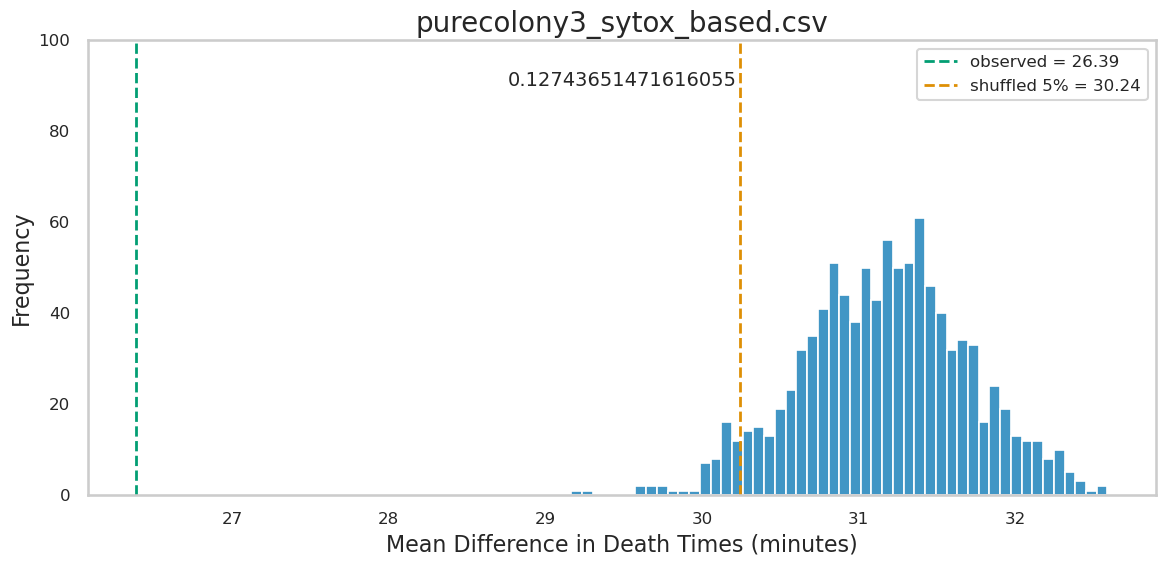

0.1251663181904581


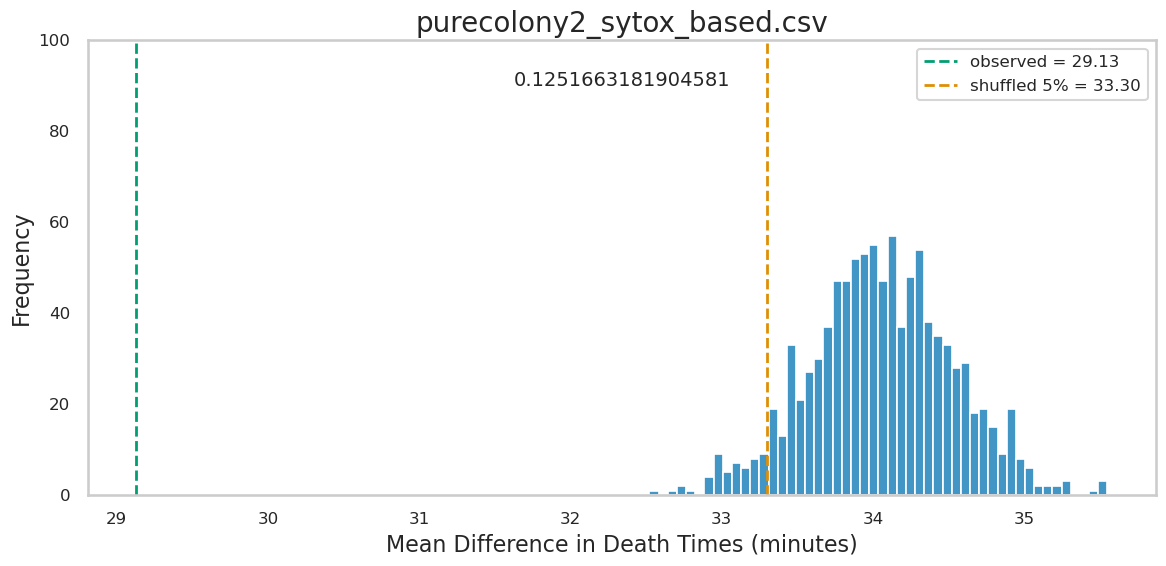

In [19]:
single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    if '_mixed' in file or 'outl' in file:
        cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
        csv = pd.read_csv(os.path.join(single_exp_full_paths, file))
        death_mode = csv["Mode"].values
        ob = mixSpiCalc(XY=cells_loci,
                            die_times=cells_times_of_death,
                            death_mode = death_mode,
                            treatment='ML162',
                            temporal_resolution=10,
                            n_scramble=1000,
                            draw=False,
                            dist_threshold=50, 
                            filter_neighbors_by_distance=True,
                            filter_neighbors_by_level= 1,
                            time_unit='minutes',)
        print(ob.get_uspis())
        mean_of_shuffles = ob.all_mean_shuffles_sorted
        # flattened_array = np.concatenate(mean_of_shuffles).ravel().tolist()
        flattened_array = np.array(mean_of_shuffles)
        # print(flattened_array)
        mean_5_pre =  ob.scramble_signficance_95
        mean_observed = ob.original_difference_death_times
        plot_histogram_with_lines(flattened_array, observed=mean_observed, shuffled_5_per= mean_5_pre, bins=50, title=file, xlabel="Mean Difference in Death Times (minutes)", ylabel="Frequency", text = str(ob.get_uspis()))
    else:
        ob = uSpiCalc(XY=cells_loci,
                            die_times=cells_times_of_death,
                            treatment='ML162',
                            temporal_resolution=10,
                            n_scramble=1000,
                            draw=False,
                            dist_threshold=50, 
                            filter_neighbors_by_distance=True,
                            filter_neighbors_by_level= 1,
                            time_unit='minutes',)
        print(ob.get_uspis())
        mean_of_shuffles = ob.all_mean_shuffles_sorted
        # flattened_array = np.concatenate(mean_of_shuffles).ravel().tolist()
        flattened_array = np.array(mean_of_shuffles)
        # print(flattened_array)
        mean_5_pre =  ob.scramble_signficance_95
        mean_observed = ob.original_difference_death_times
        plot_histogram_with_lines(flattened_array, observed=mean_observed, shuffled_5_per= mean_5_pre, bins=50, title=file, xlabel="Mean Difference in Death Times (minutes)", ylabel="Frequency", text = str(ob.get_uspis()))

### Mixed

0.2548922467178598


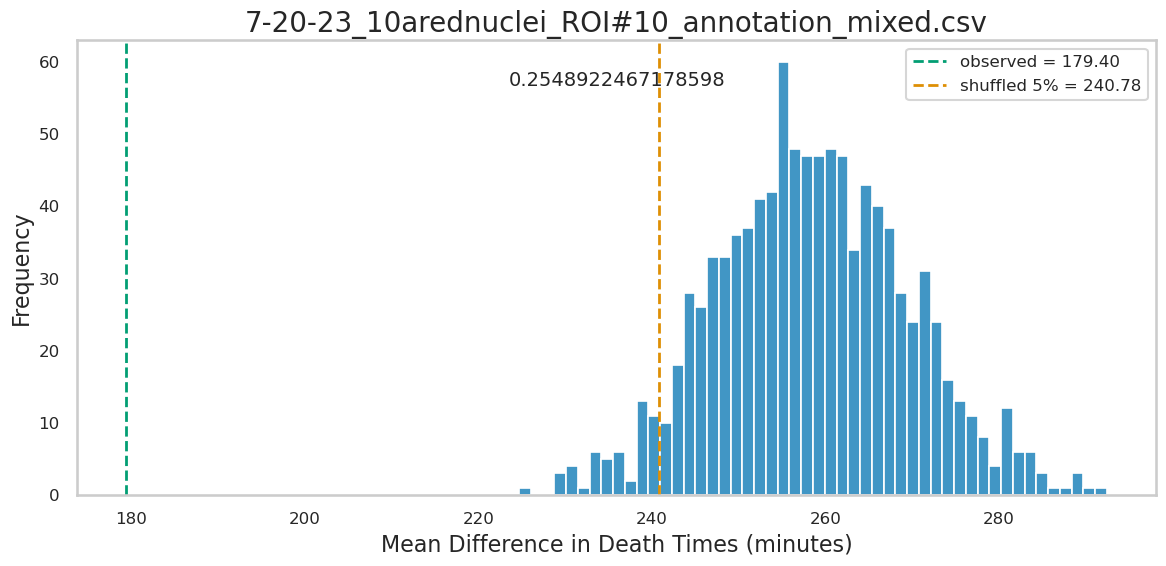

0.35184969937762195


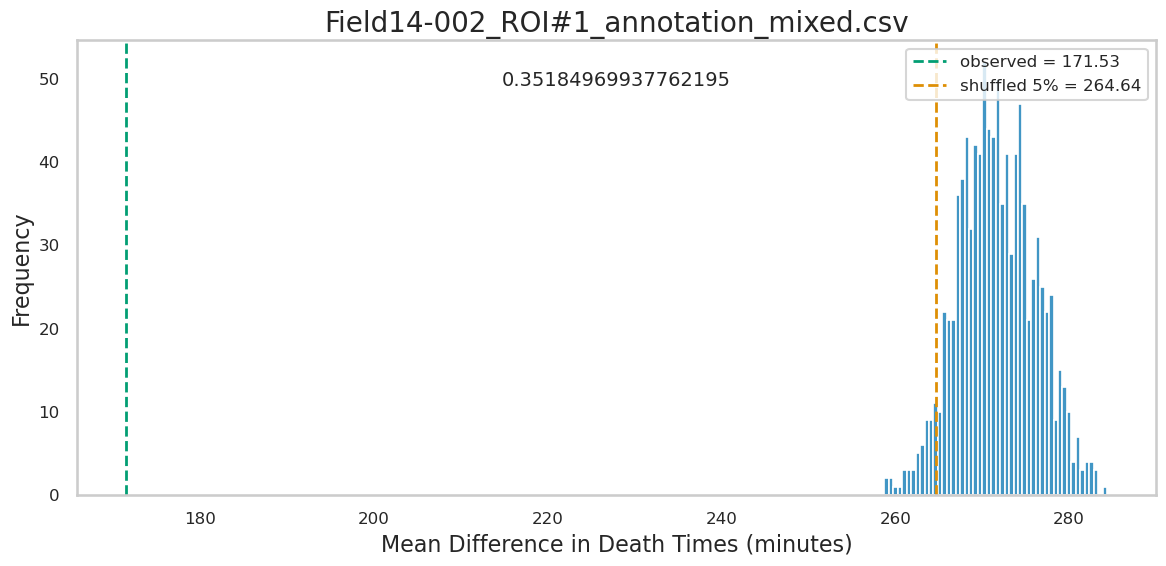

0.34990094302242647


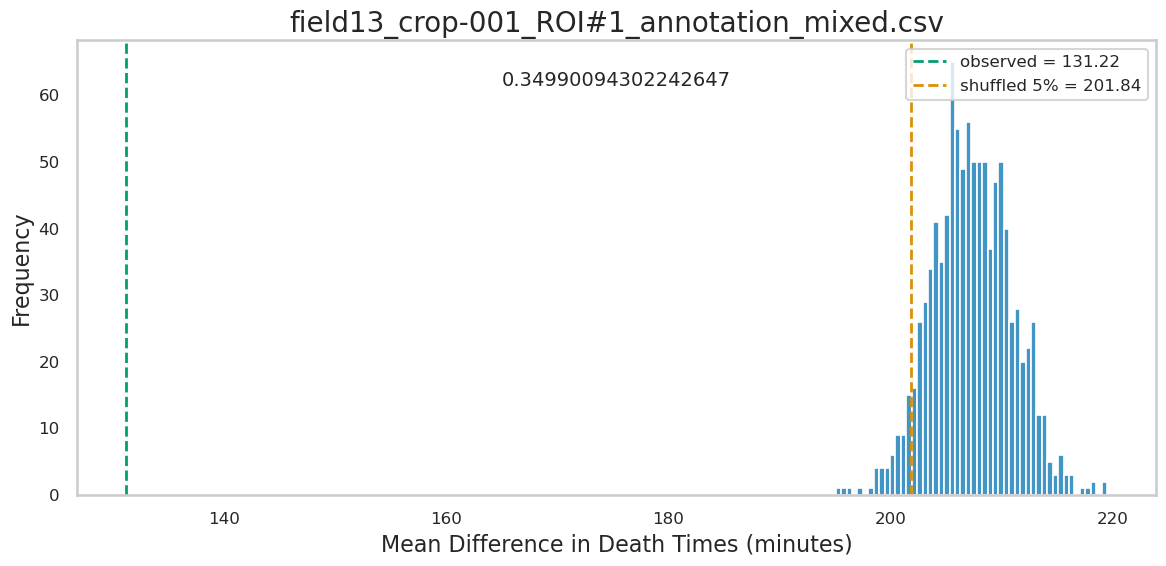

0.6166973082543723


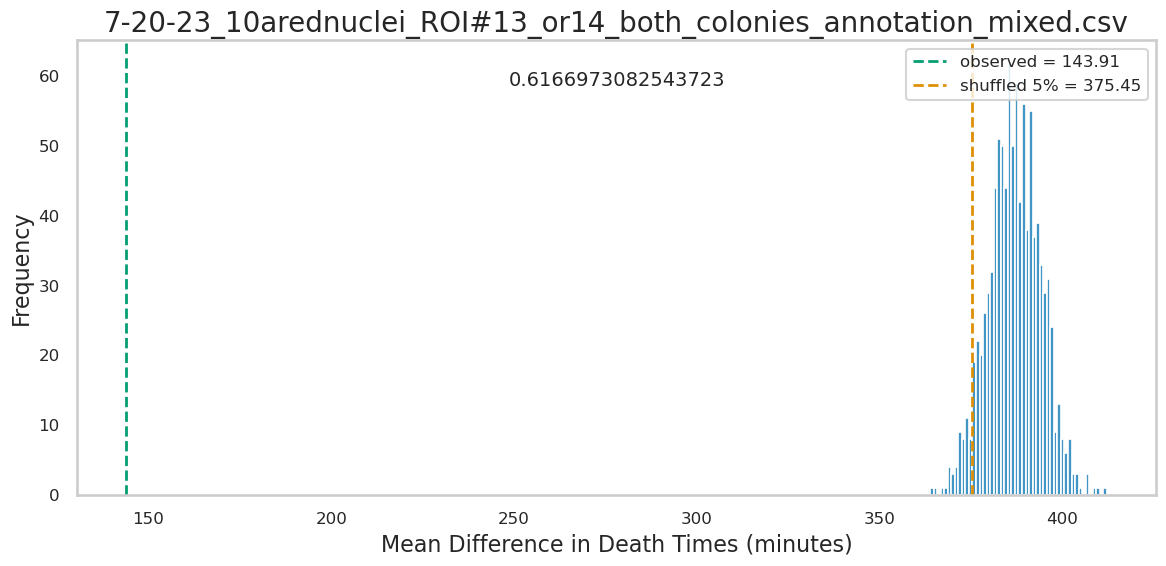

In [ ]:
single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only/'
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    if '_mixed' not in file:
        continue
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    csv = pd.read_csv(os.path.join(single_exp_full_paths, file))
    death_mode = csv["Mode"].values
    ob = mixSpiCalc(XY=cells_loci,
                        die_times=cells_times_of_death,
                        death_mode = death_mode,
                        treatment='ML162',
                        temporal_resolution=10,
                        n_scramble=1000,
                        draw=False,
                        dist_threshold=50, 
                        filter_neighbors_by_distance=True,
                        filter_neighbors_by_level= 1,
                        time_unit='minutes',)
    print(ob.get_uspis())
    mean_of_shuffles = ob.all_mean_shuffles_sorted
    # flattened_array = np.concatenate(mean_of_shuffles).ravel().tolist()
    flattened_array = np.array(mean_of_shuffles)
    # print(flattened_array)
    mean_5_pre =  ob.scramble_signficance_95
    mean_observed = ob.original_difference_death_times
    plot_histogram_with_lines(flattened_array, observed=mean_observed, shuffled_5_per= mean_5_pre, bins=50, title=file, xlabel="Mean Difference in Death Times (minutes)", ylabel="Frequency", text = str(ob.get_uspis()))

0.255506971371999


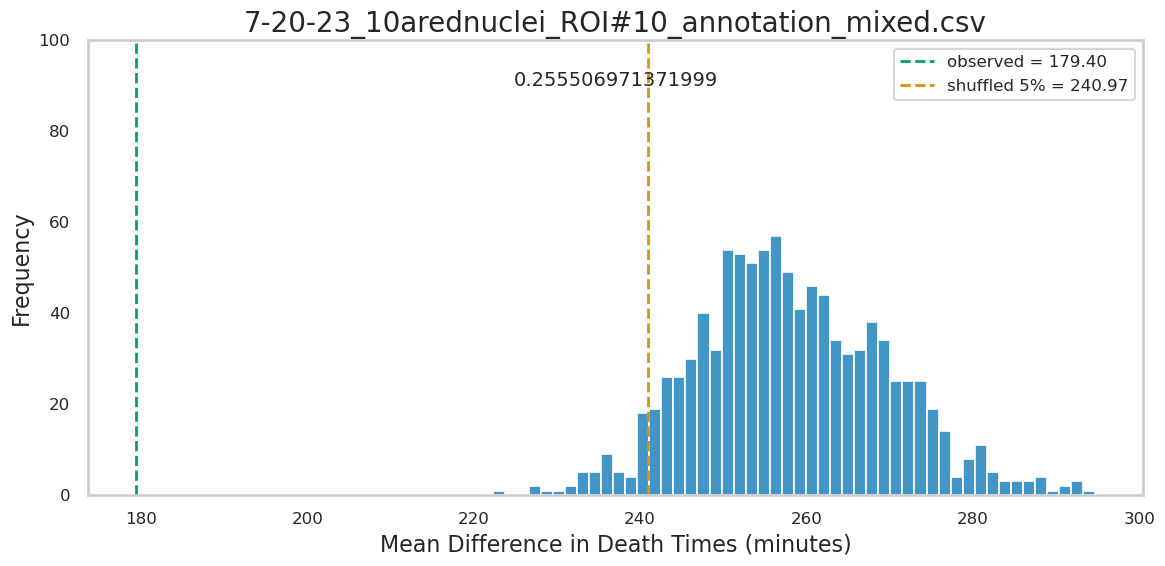

0.23382385801385389


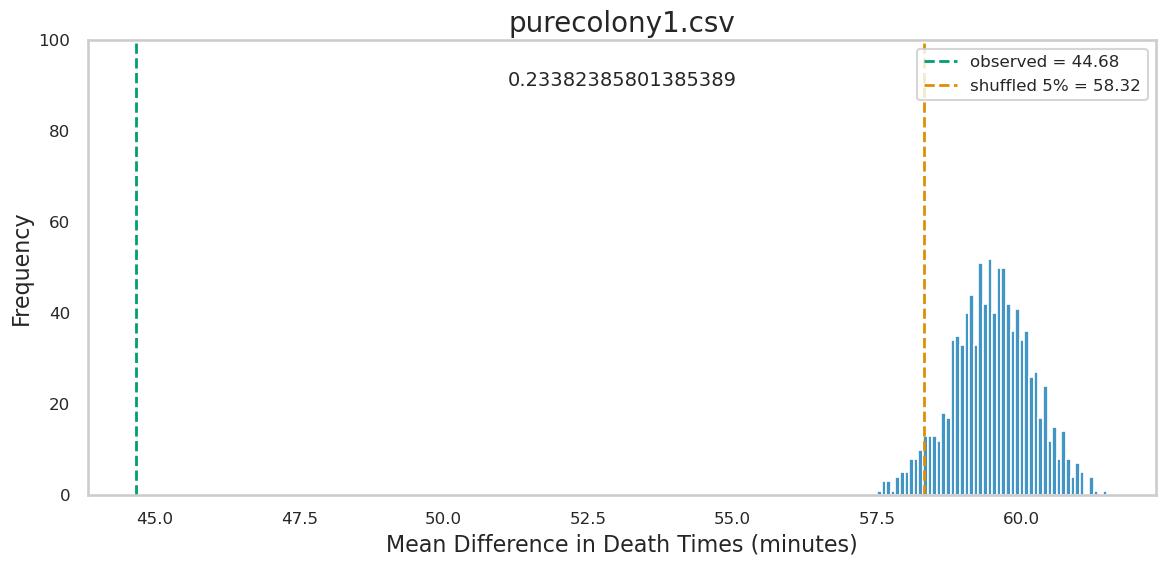

0.18341521937842775


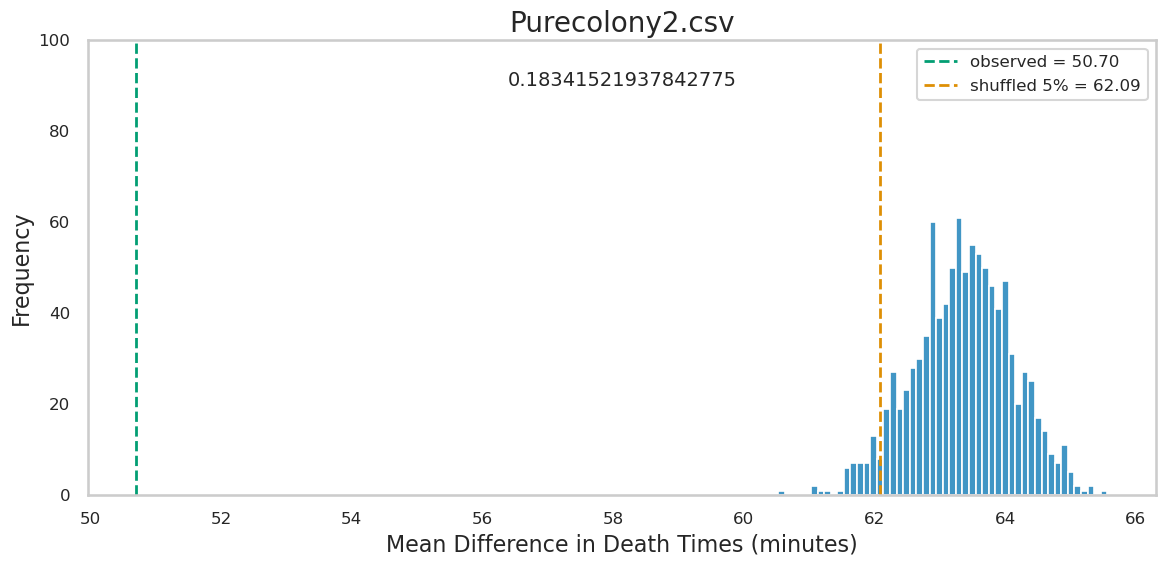

0.18679436540948646


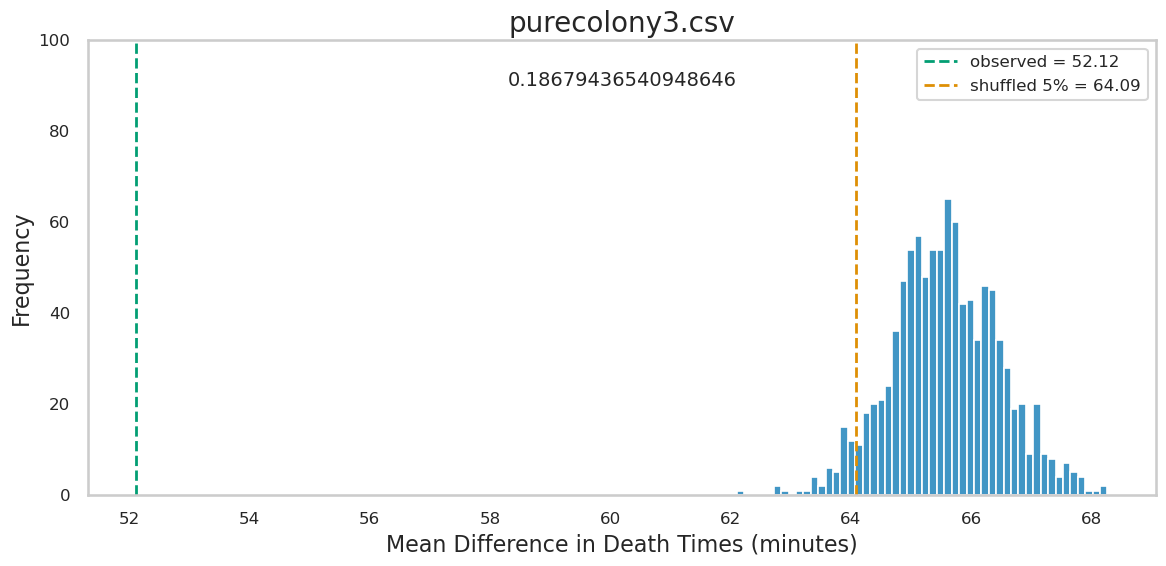

0.11615456238361276


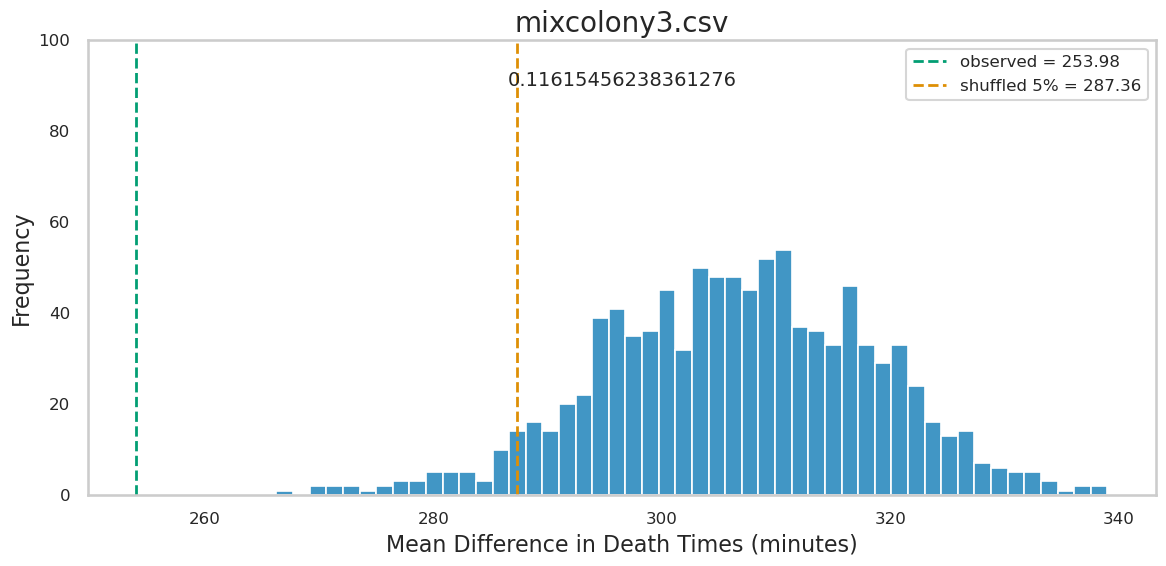

0.3516441700931221


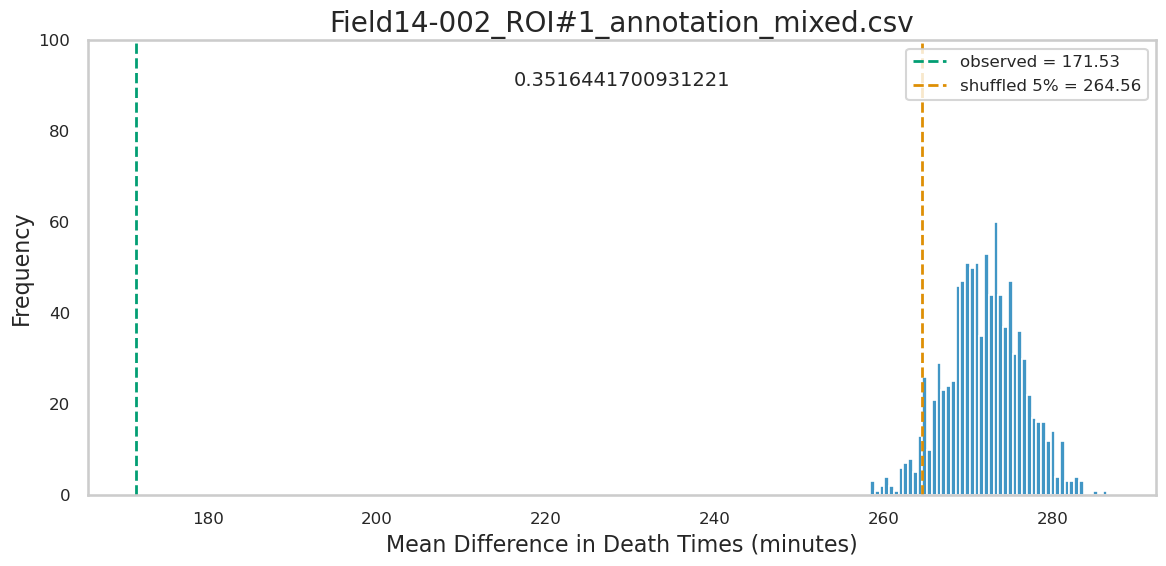

0.34932343469915444


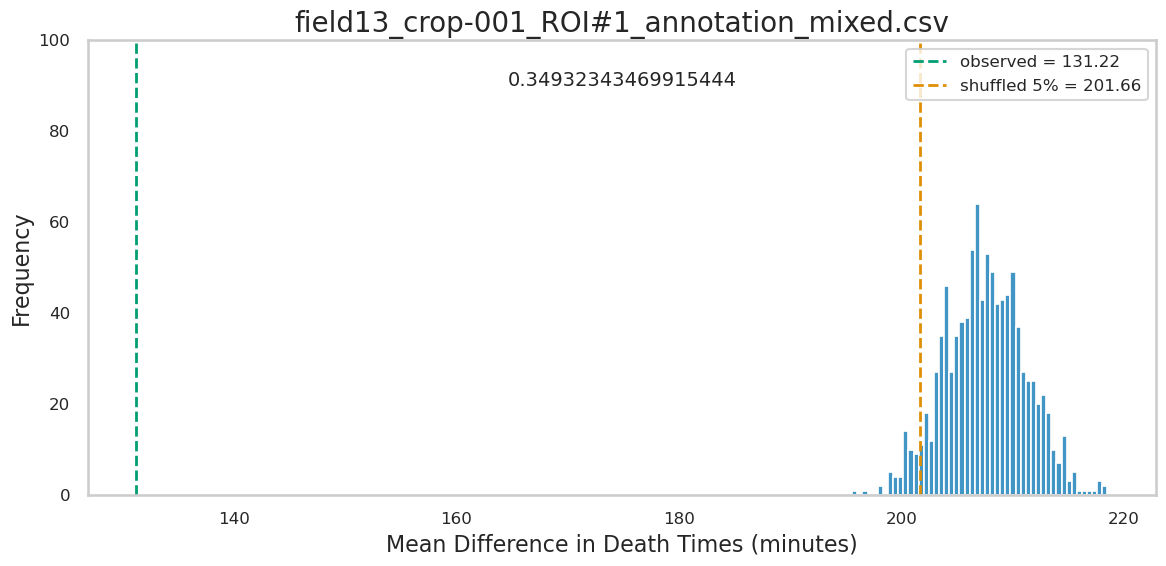

0.6173286897590361


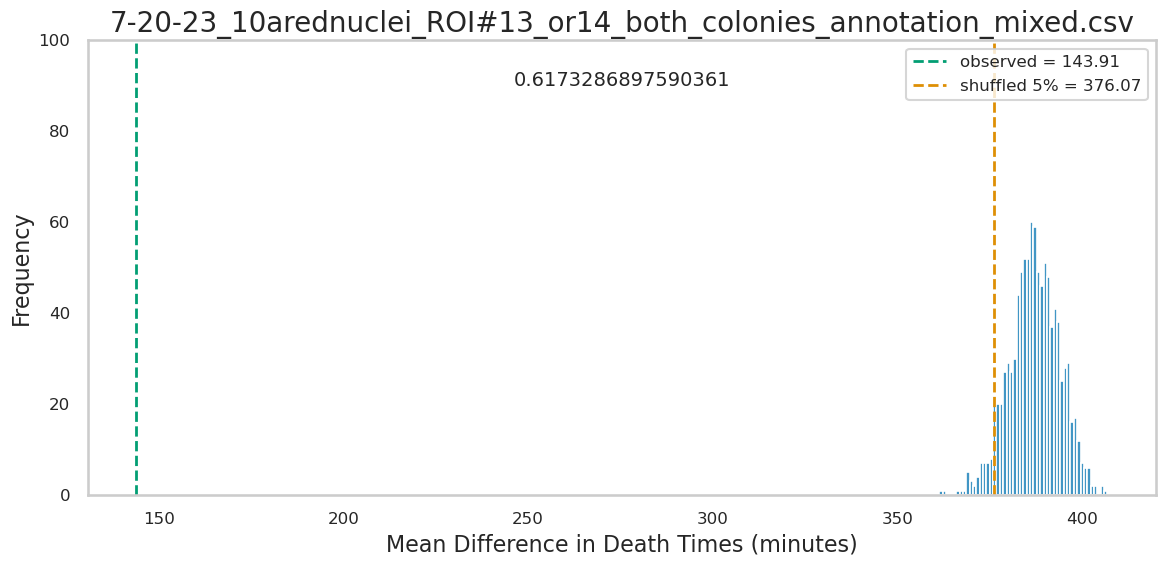

0.18616929202007962


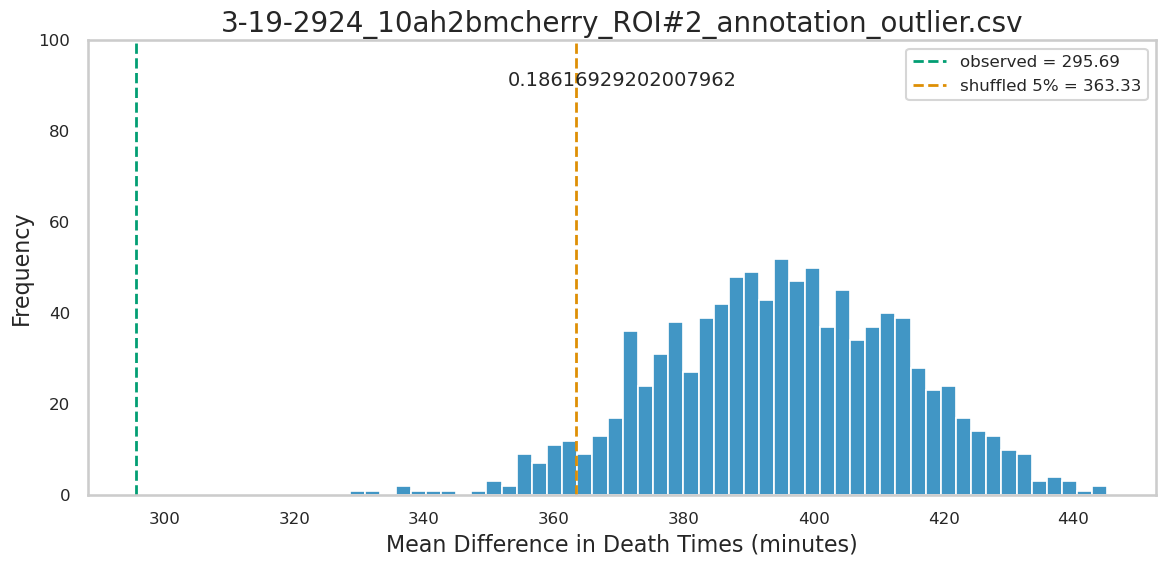

0.4405510283275126


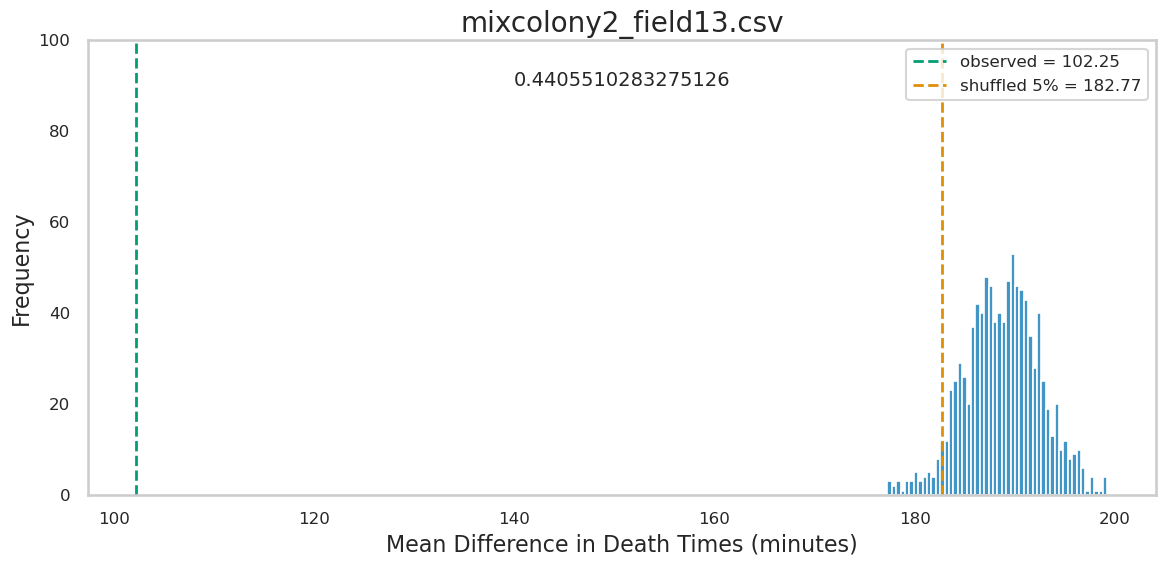

0.3735744542196156


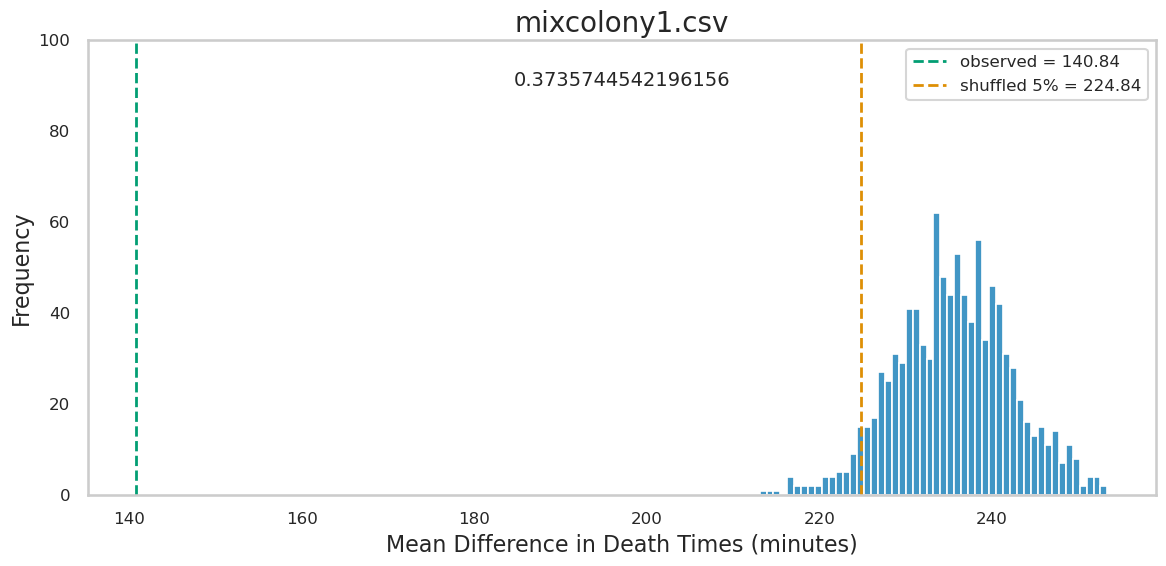

0.3696533923303835


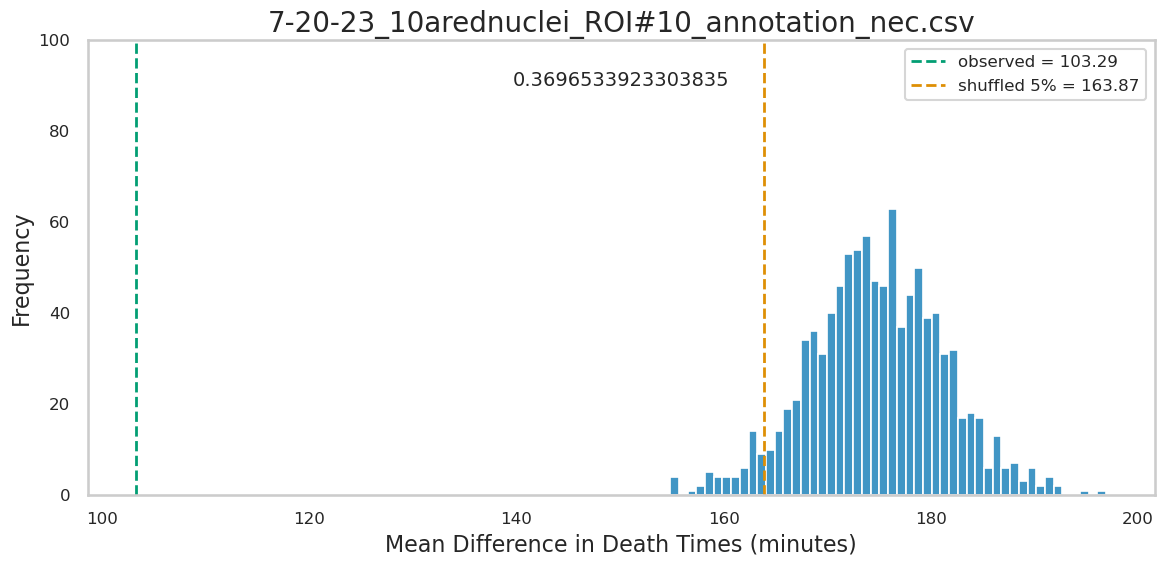

-86.0


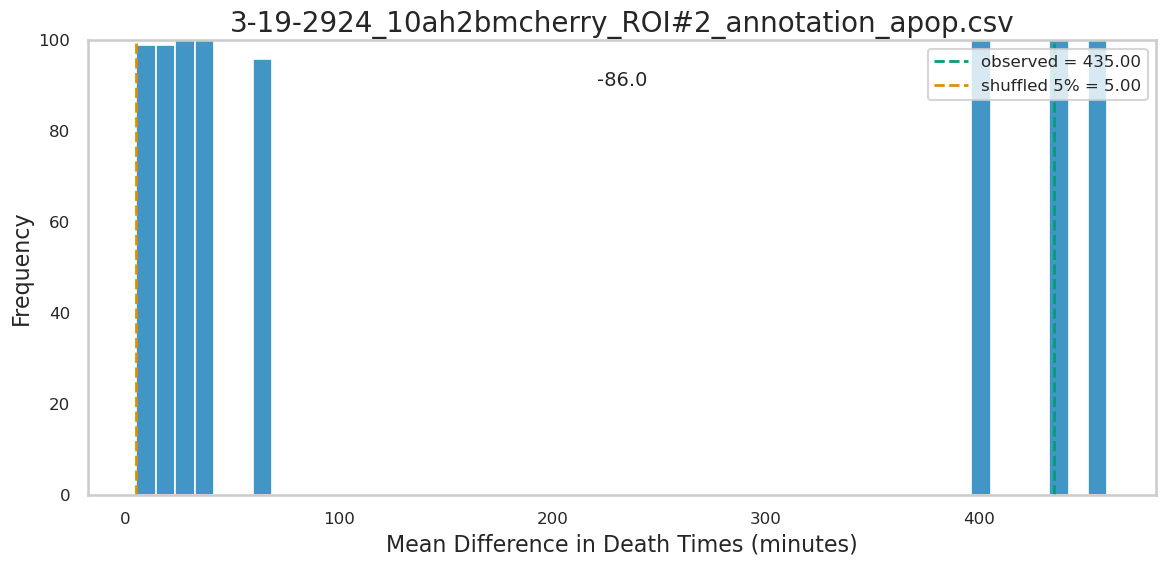

0.24738649370469293


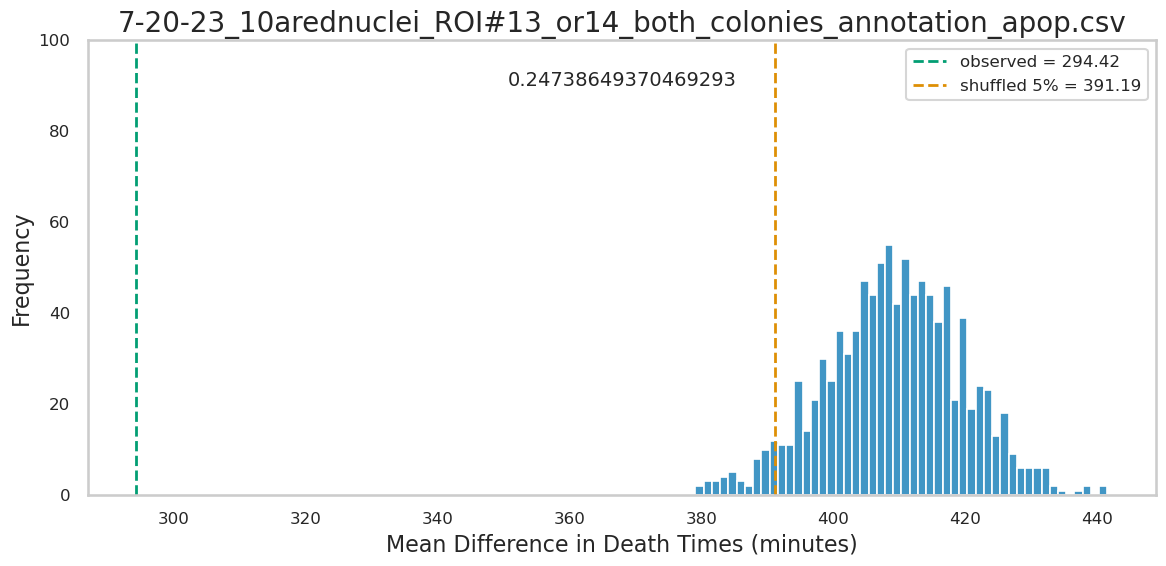

-0.5245365321701201


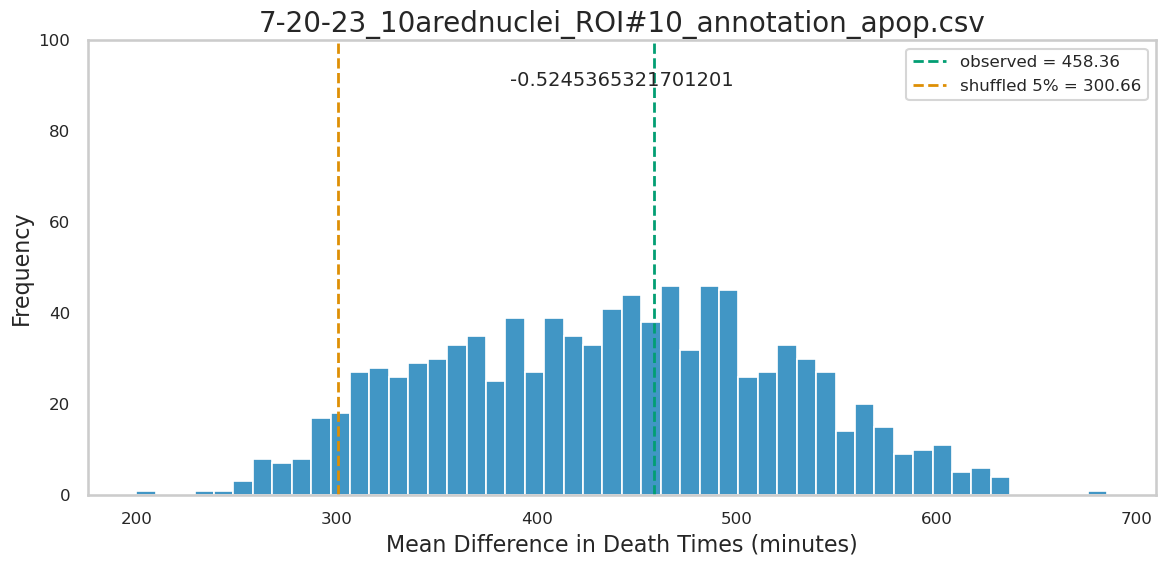

0.17067833698030632


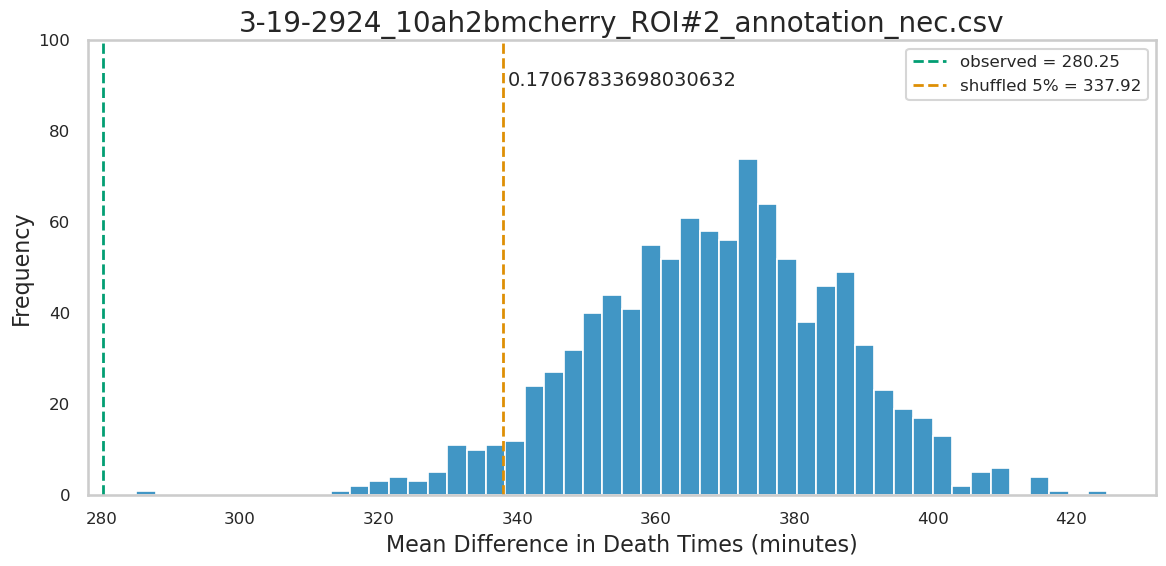

0.5777777777777778


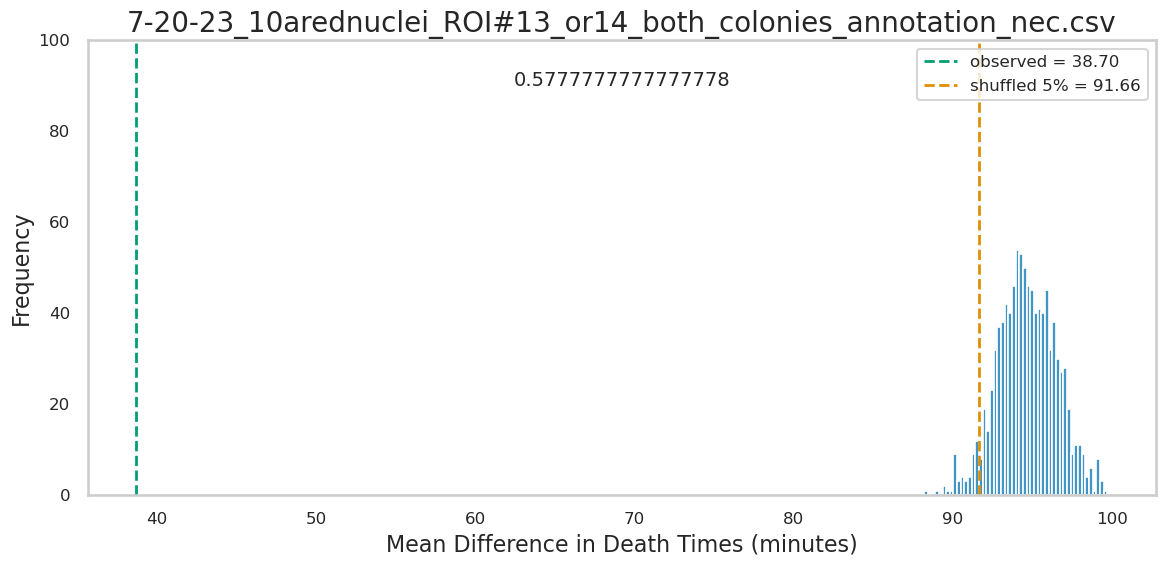

0.09041019440052088


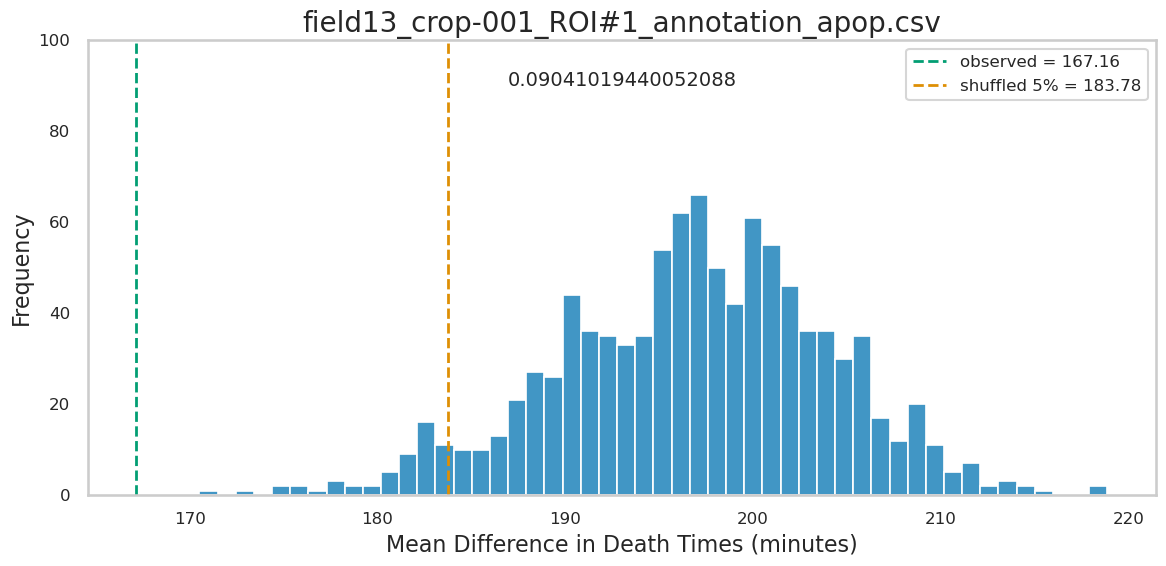

0.31378254211332324


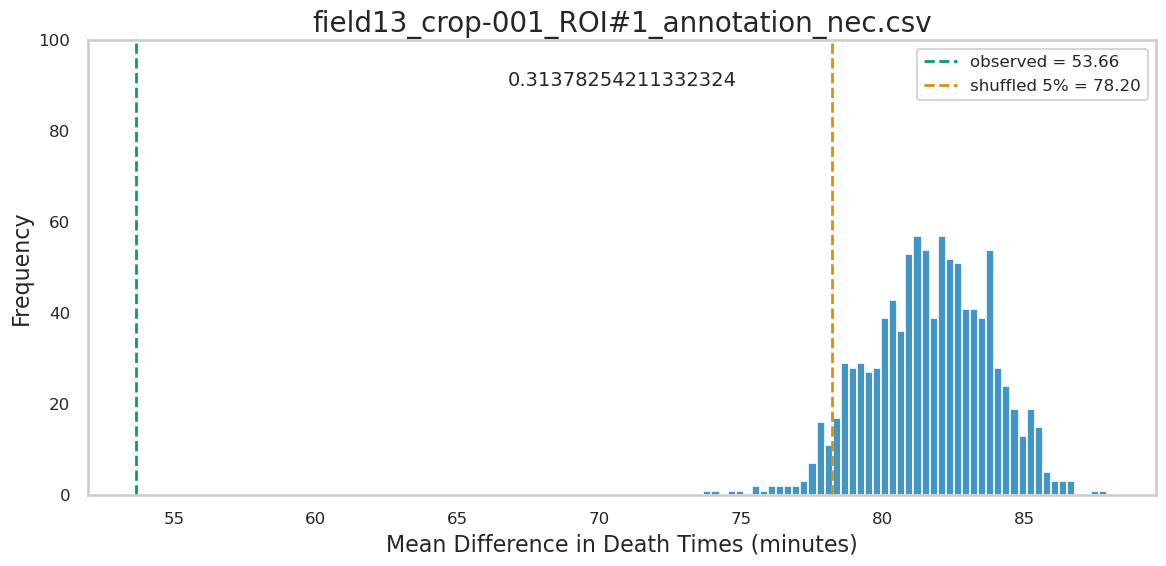

0.17181337181337186


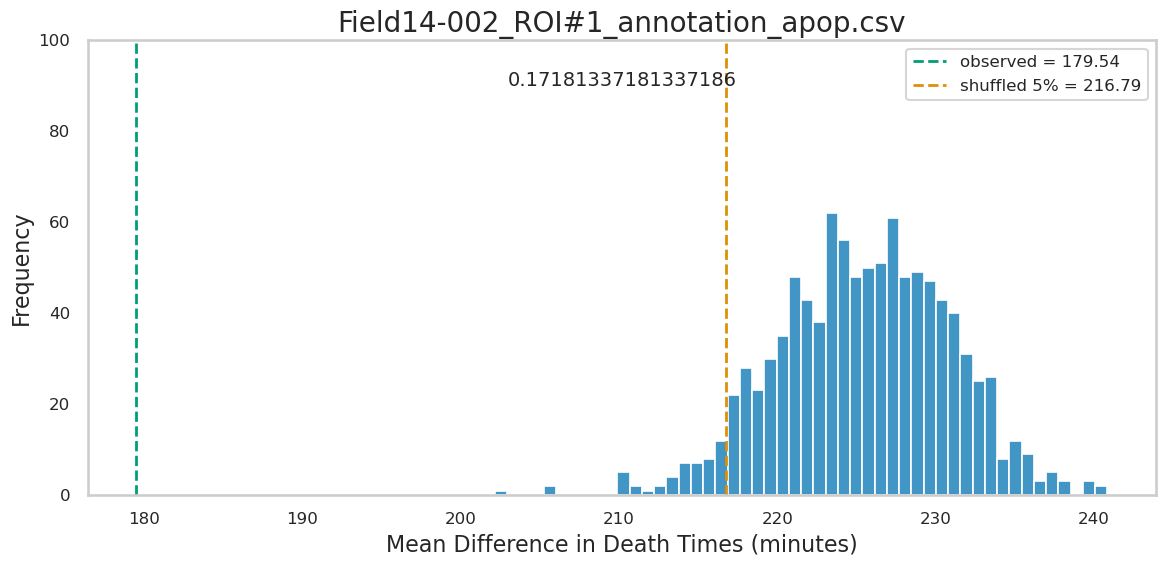

0.3143729189789123


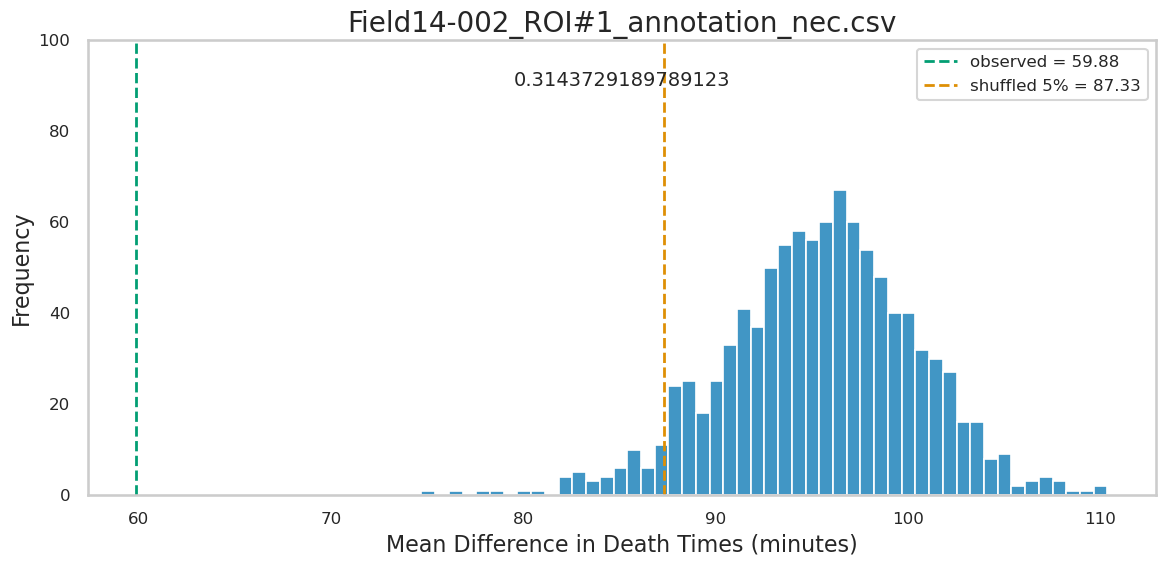

0.06944444444444445


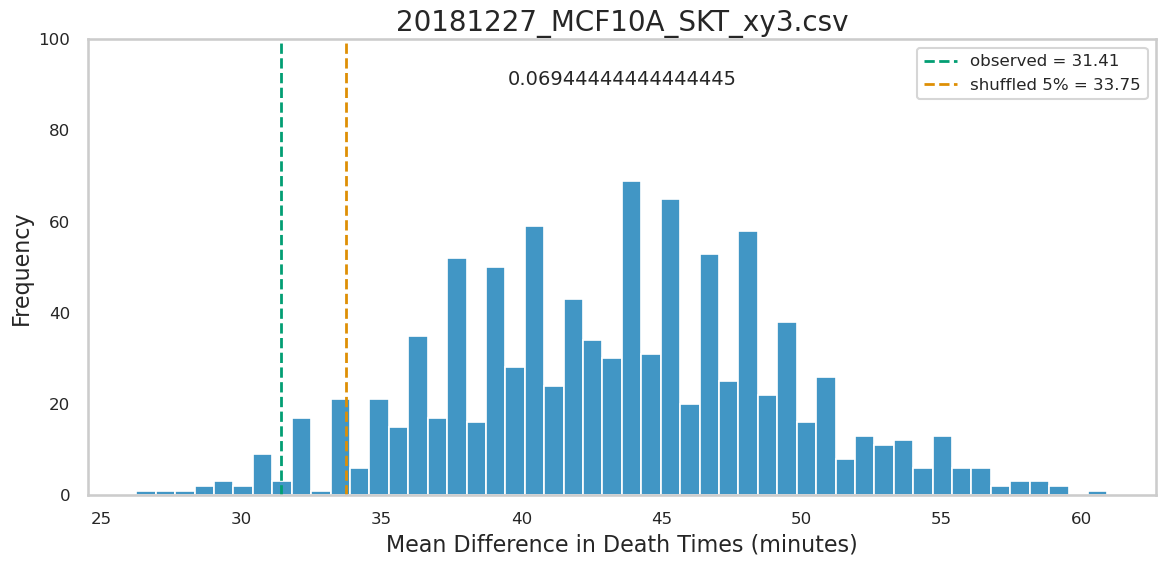

0.2972972972972973


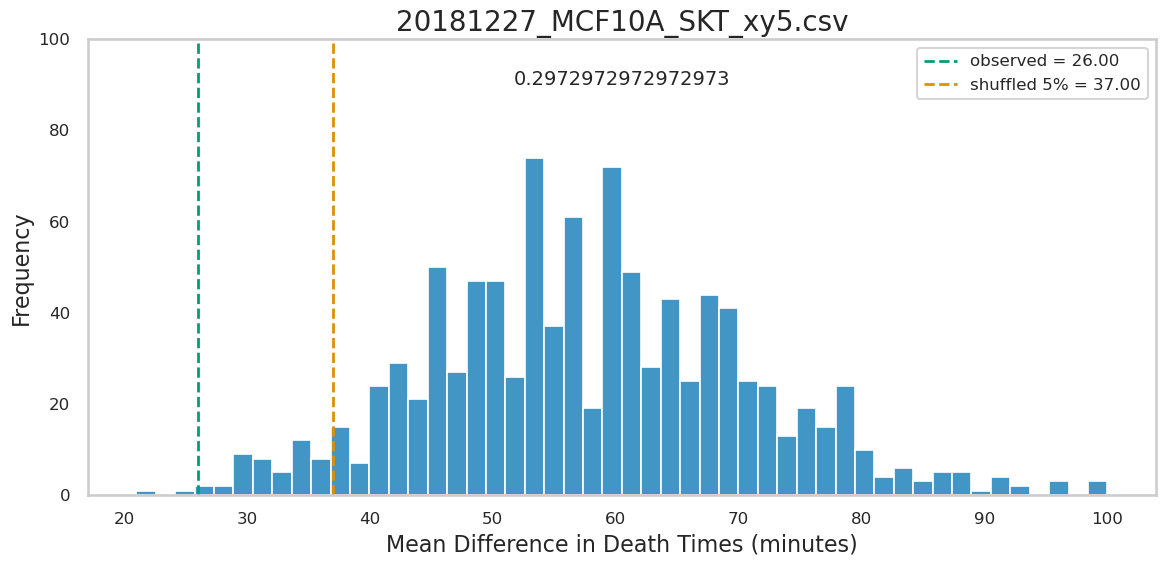

0.08064516129032263


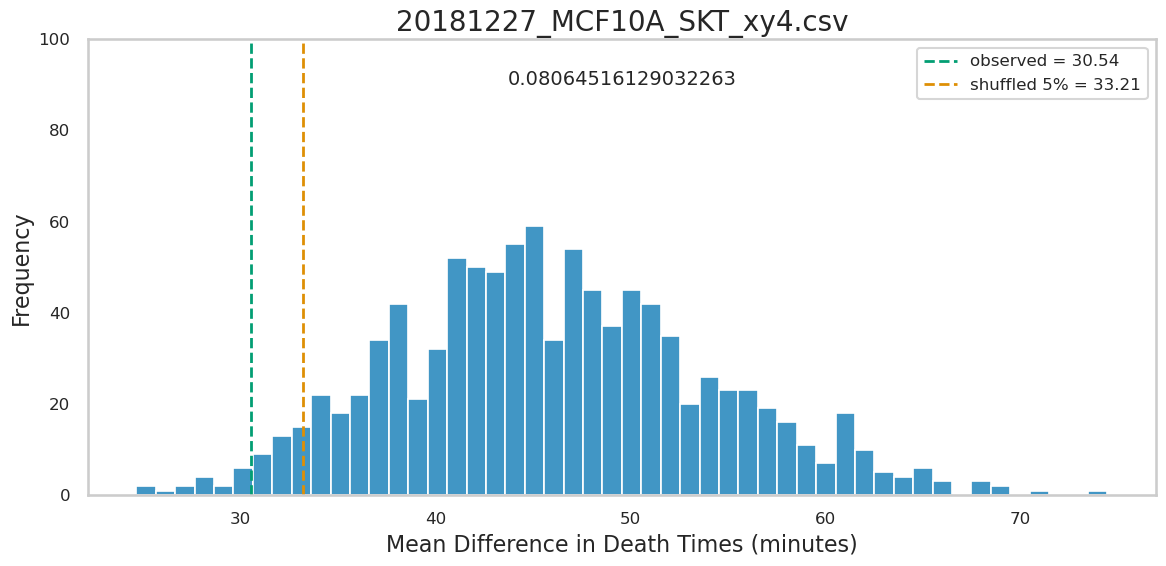

In [20]:
single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only/'#Field14-002_ROI#1_annotation_nec.csv'
# single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_sytox/'
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    ob = uSpiCalc(XY=cells_loci,
                        die_times=cells_times_of_death,
                        treatment='ML162',
                        temporal_resolution=10,
                        n_scramble=1000,
                        draw=False,
                        dist_threshold=50, 
                        filter_neighbors_by_distance=True,
                        filter_neighbors_by_level= 1,
                        time_unit='minutes',)
    print(ob.get_uspis())
    mean_of_shuffles = ob.all_mean_shuffles_sorted
    # flattened_array = np.concatenate(mean_of_shuffles).ravel().tolist()
    flattened_array = np.array(mean_of_shuffles)
    # print(flattened_array)
    mean_5_pre =  ob.scramble_signficance_95
    mean_observed = ob.original_difference_death_times
    plot_histogram_with_lines(flattened_array, observed=mean_observed, shuffled_5_per= mean_5_pre, bins=50, title=file, xlabel="Mean Difference in Death Times (minutes)", ylabel="Frequency", text = str(ob.get_uspis()))

## Median

0.5


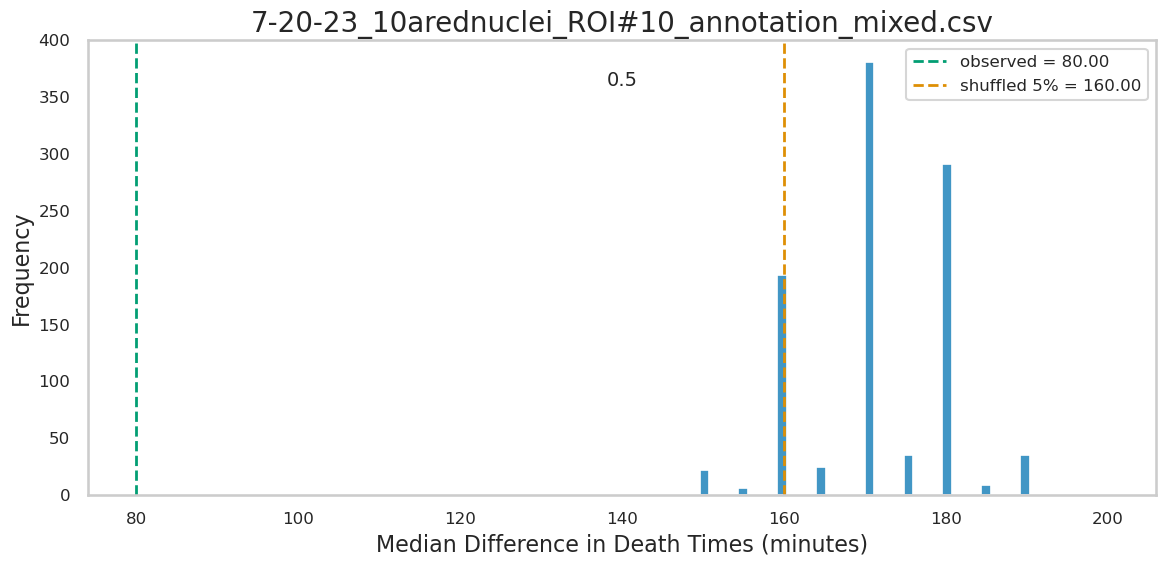

0.3


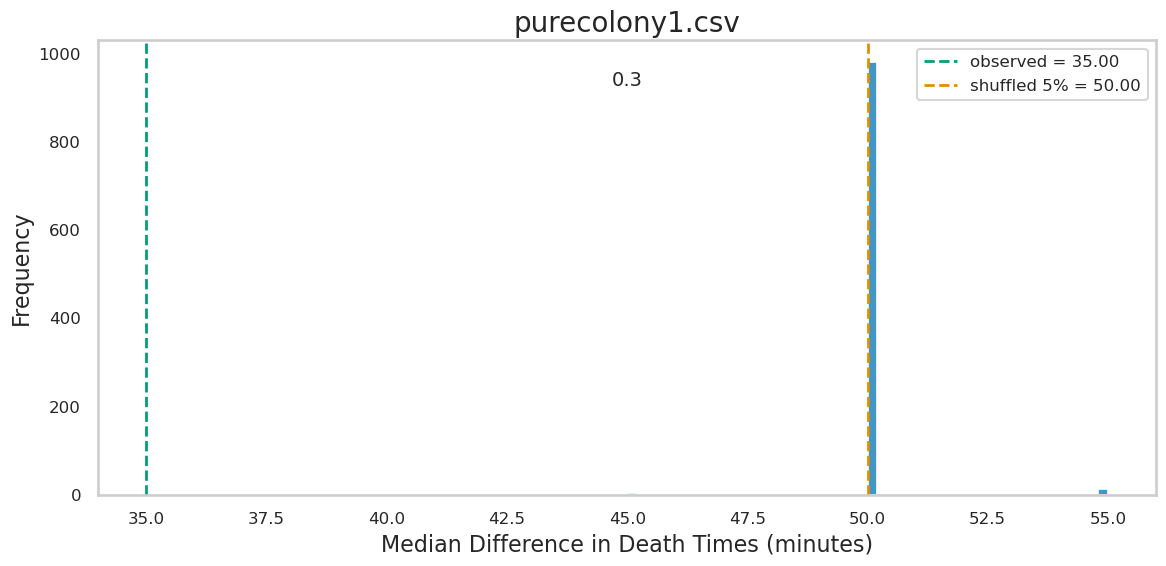

0.2


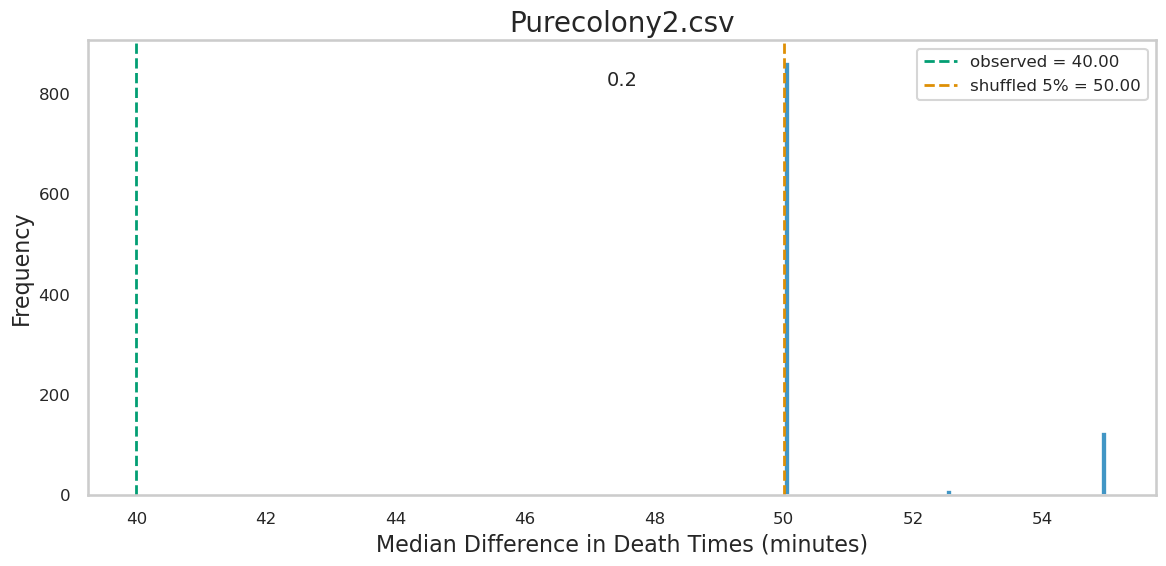

0.2


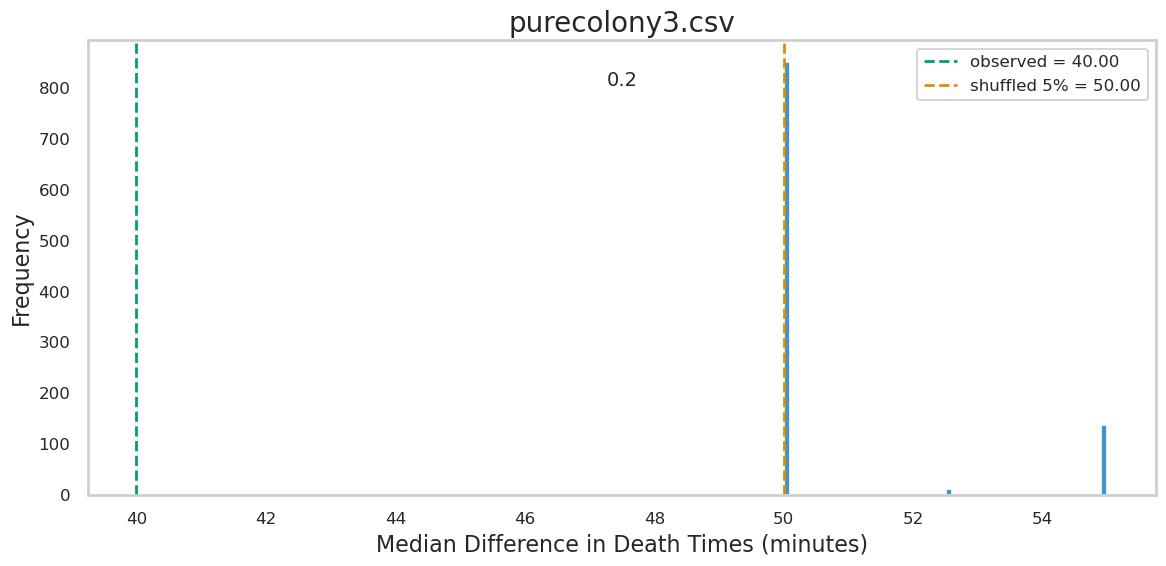

0.16


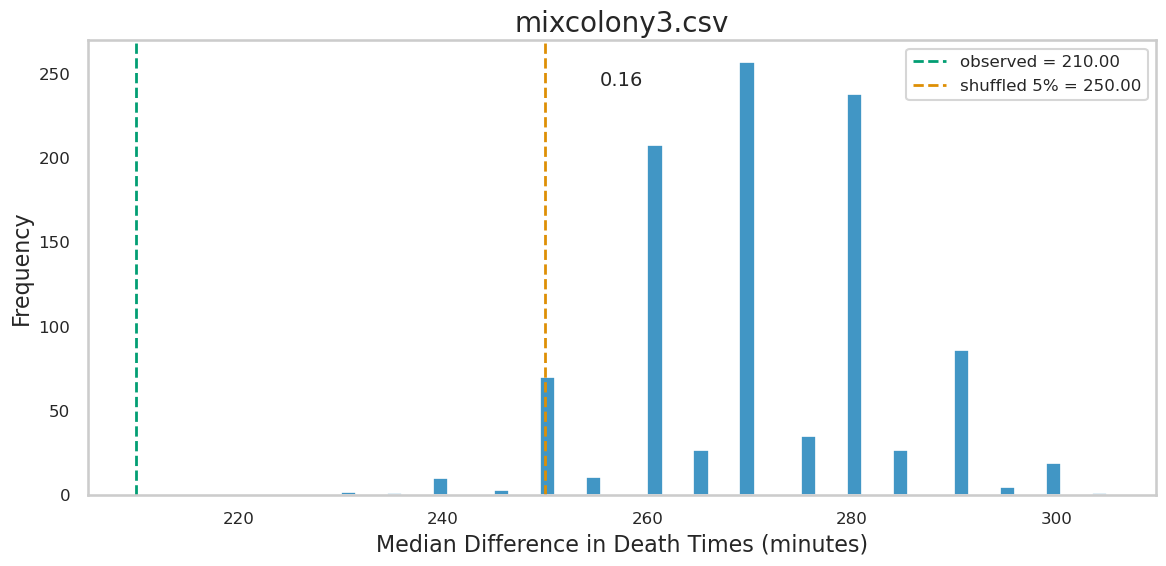

0.47619047619047616


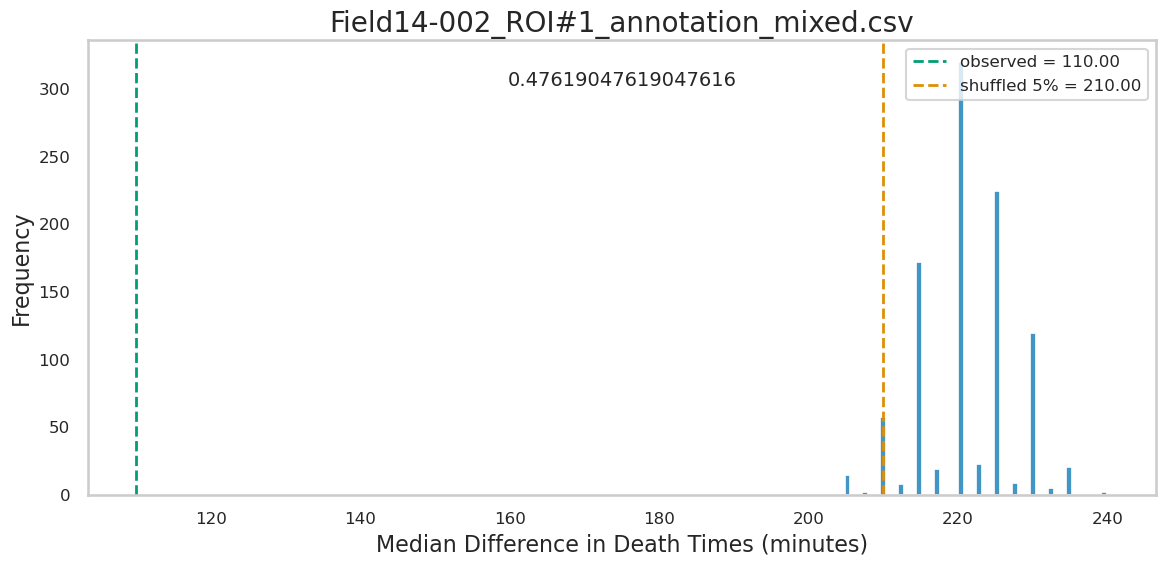

0.5806451612903226


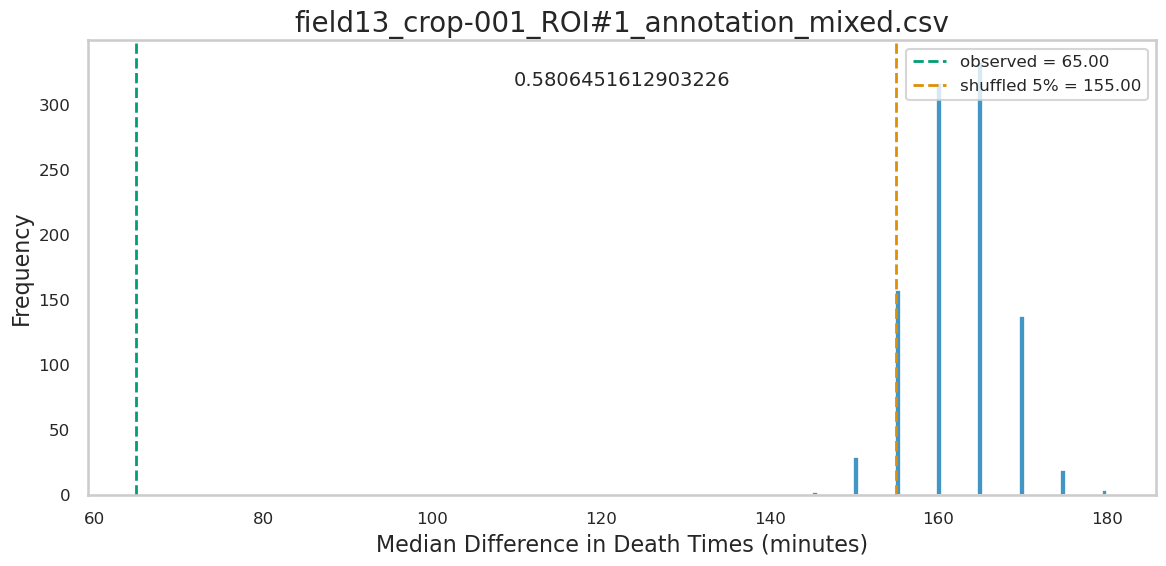

0.8


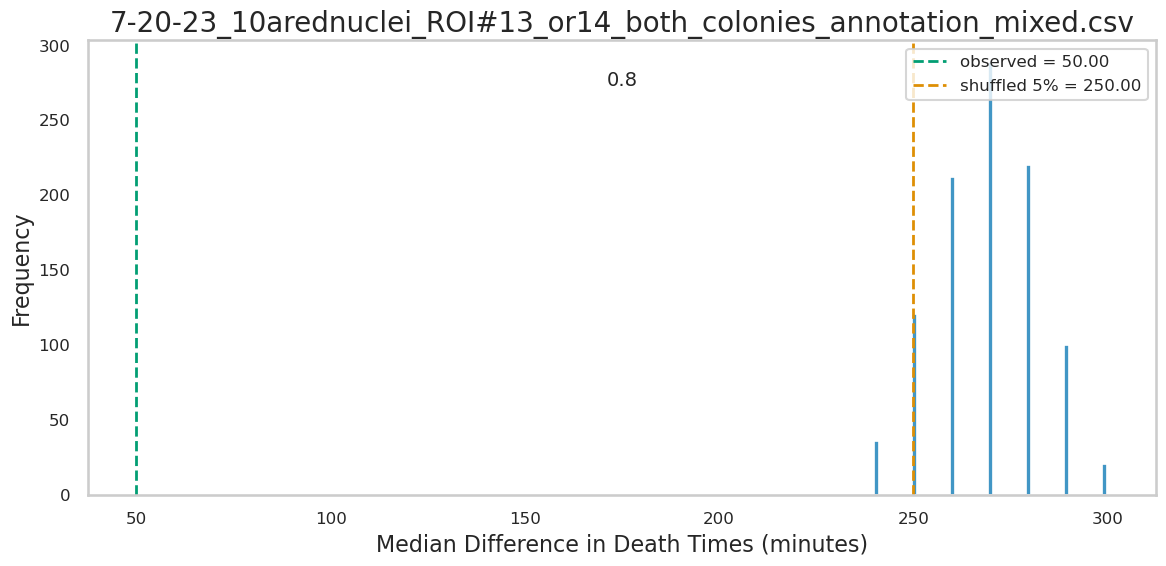

0.16393442622950818


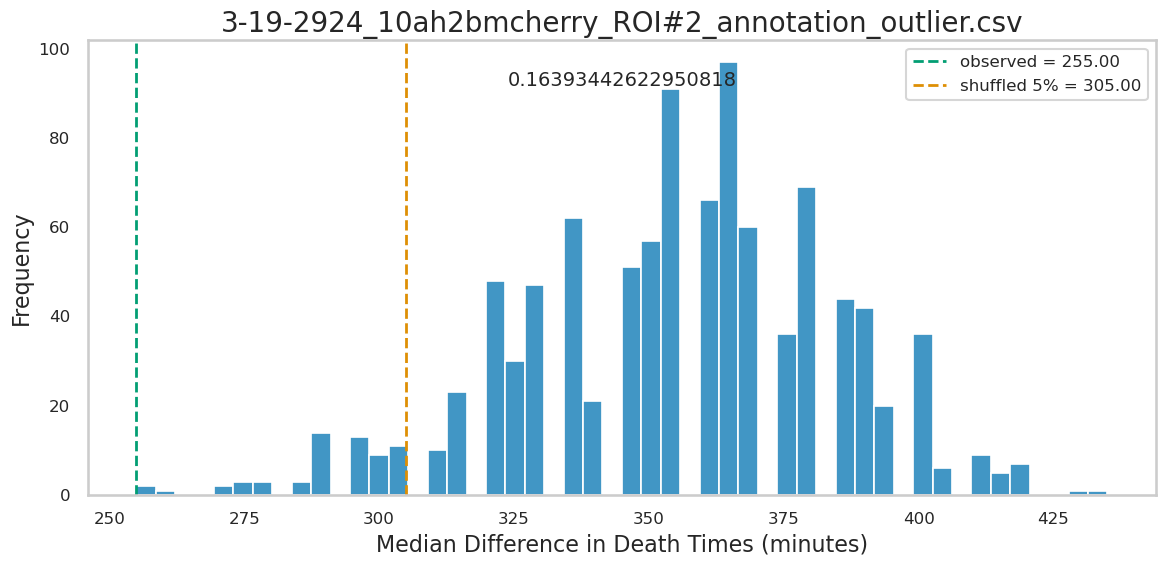

0.6363636363636364


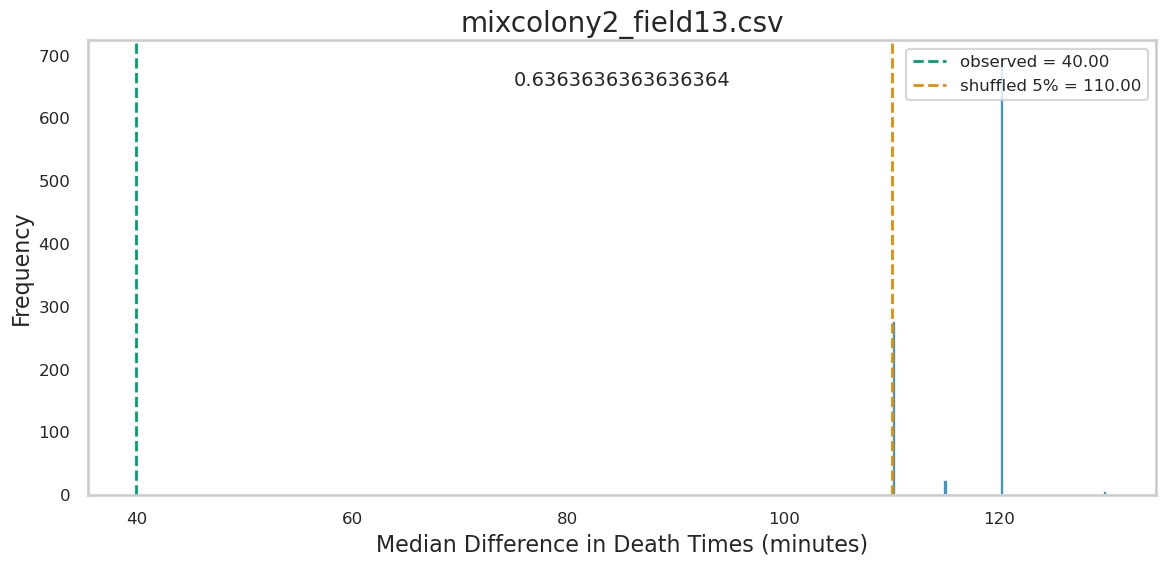

0.5714285714285714


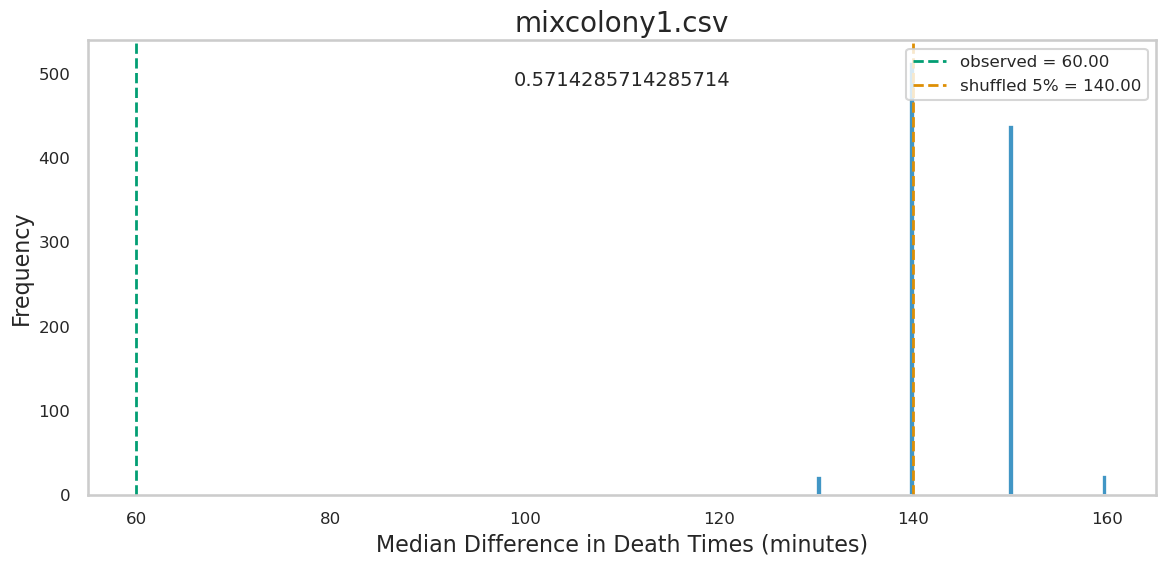

0.46153846153846156


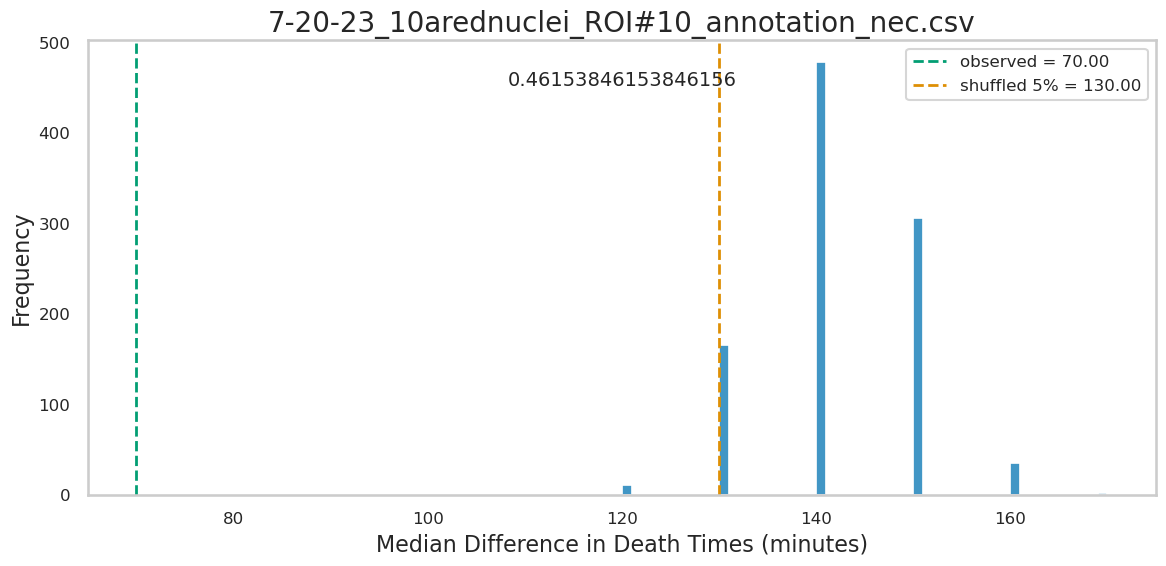

-17.555555555555557


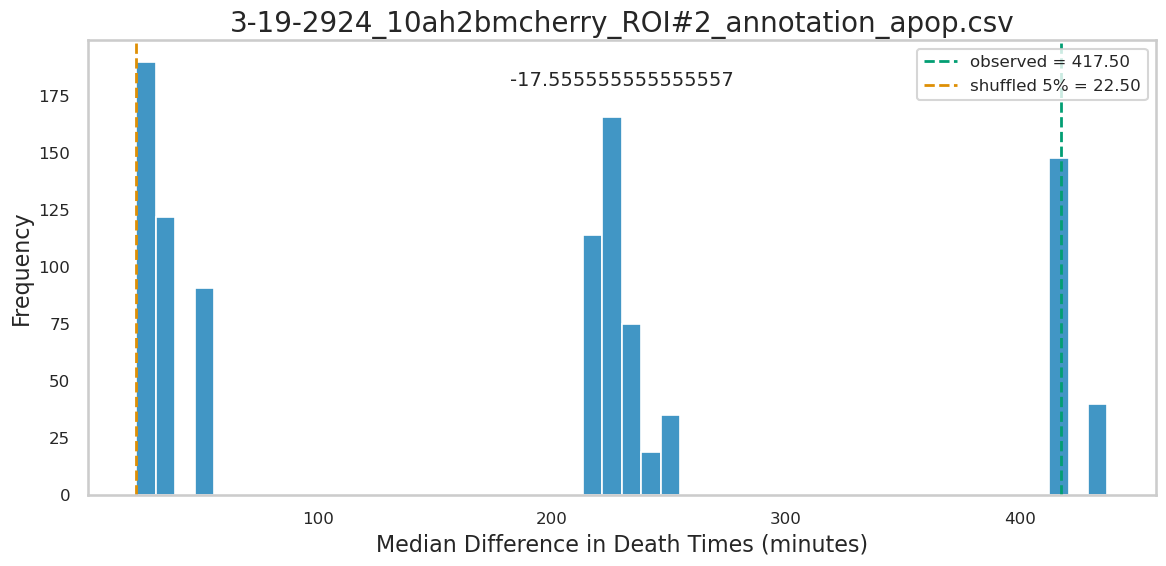

0.29411764705882354


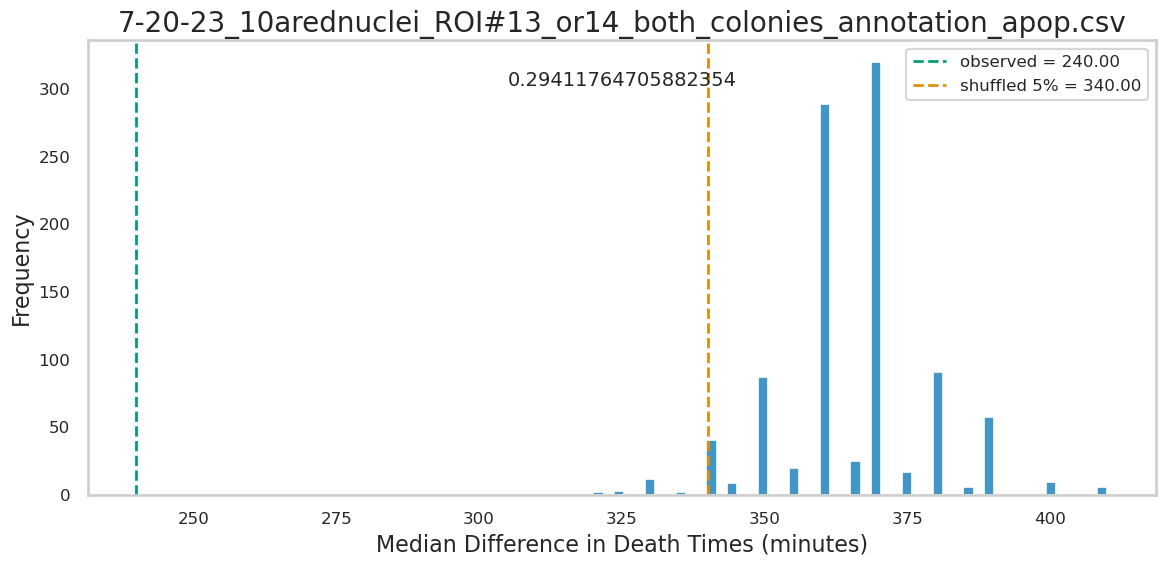

0.13953488372093023


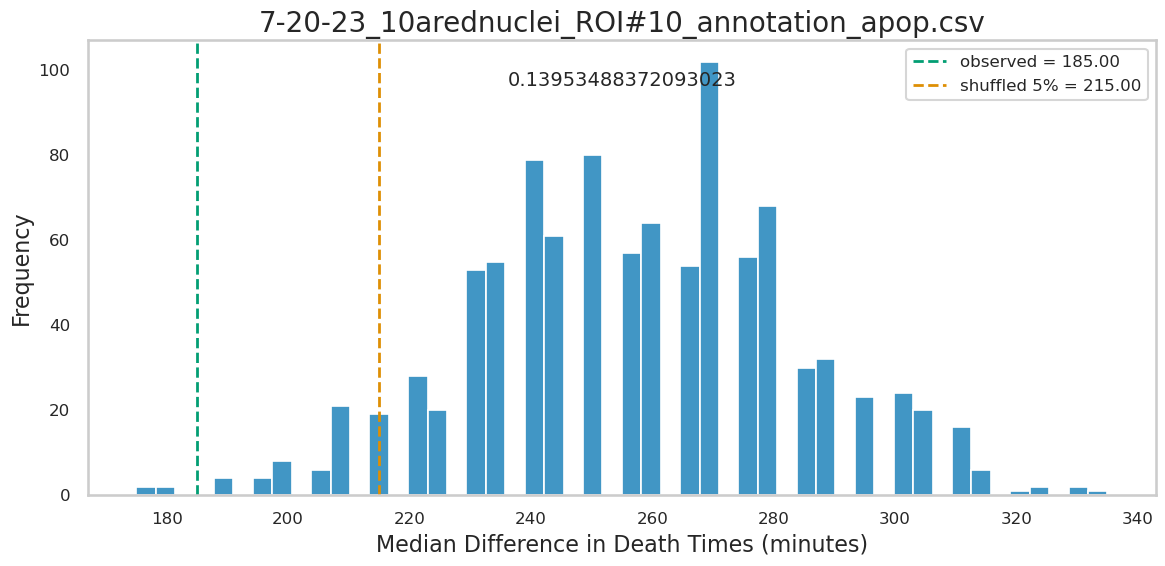

0.09090909090909091


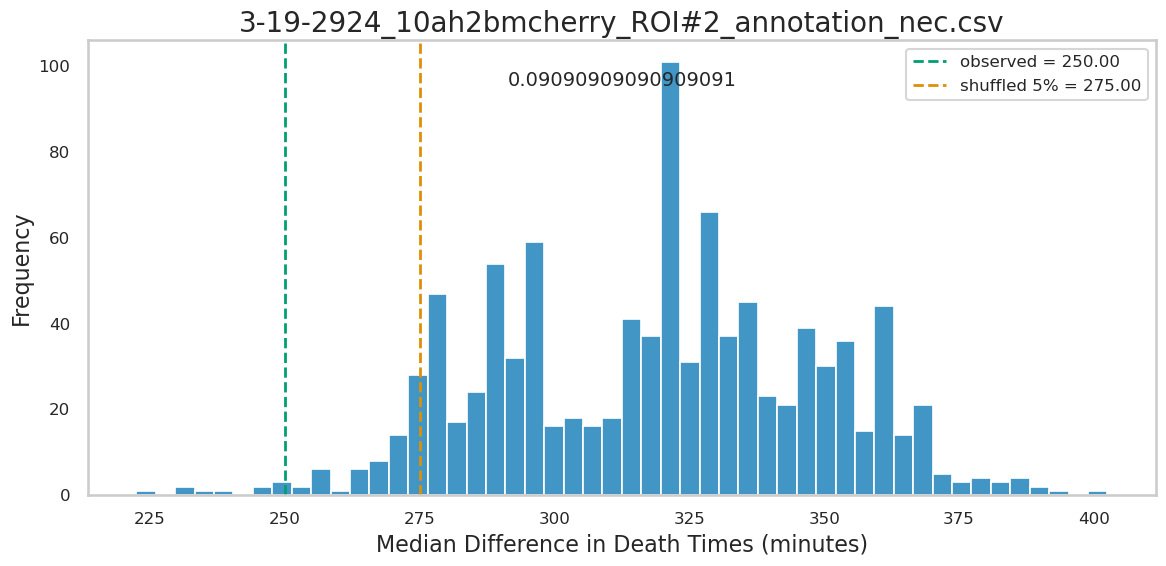

0.7142857142857143


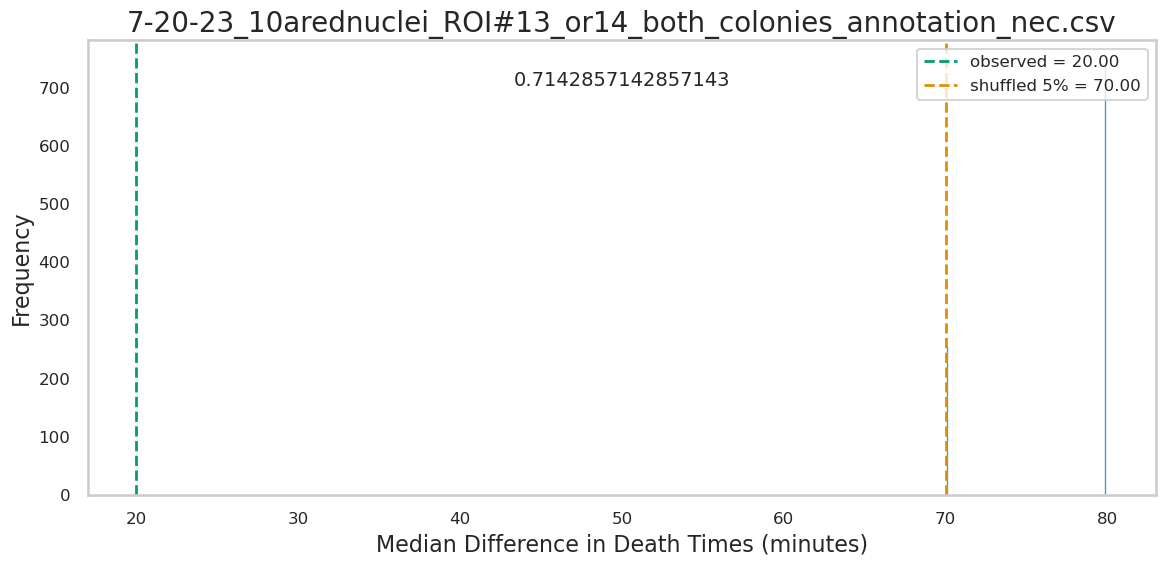

0.11538461538461539


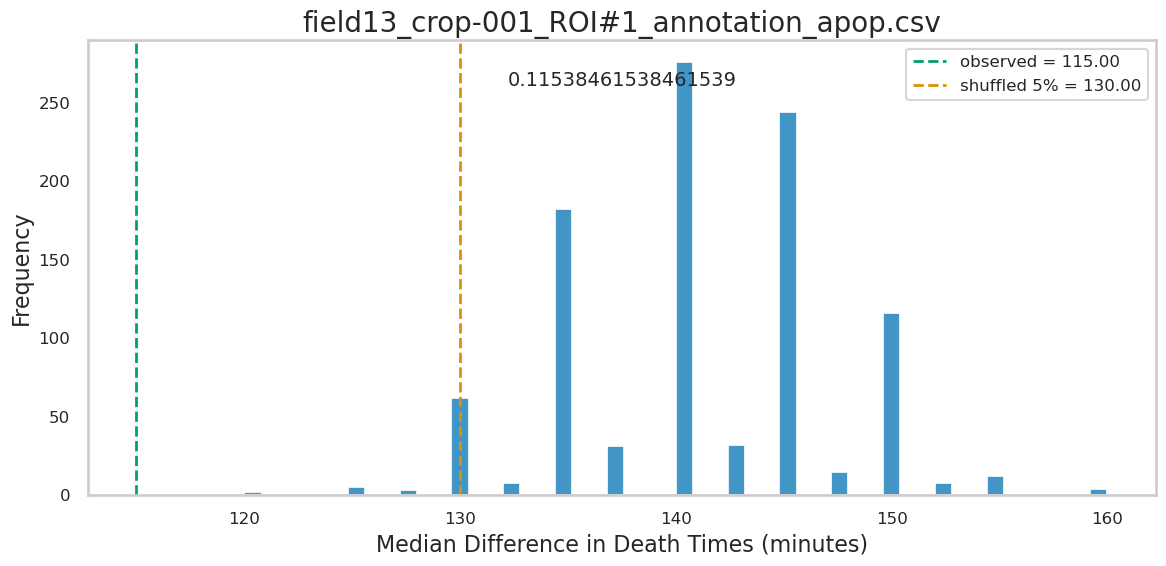

0.45454545454545453


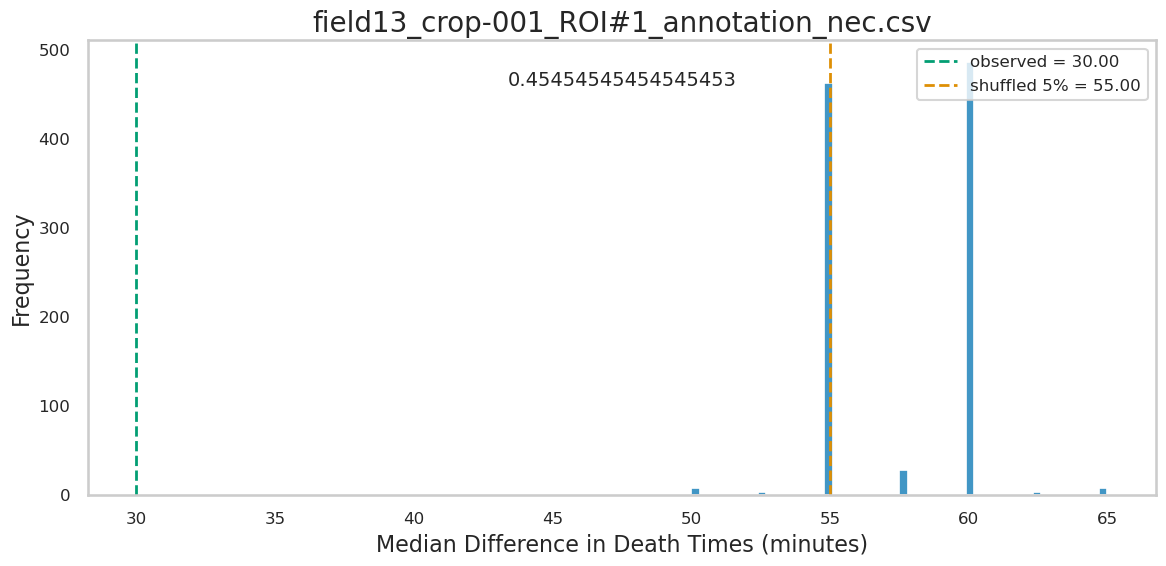

0.21212121212121213


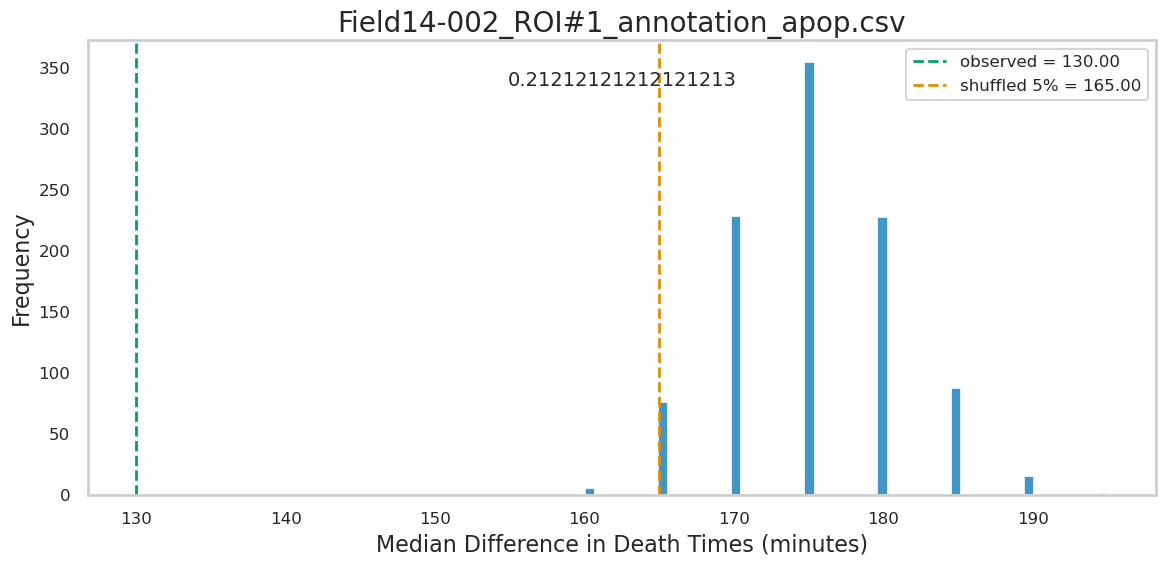

0.2


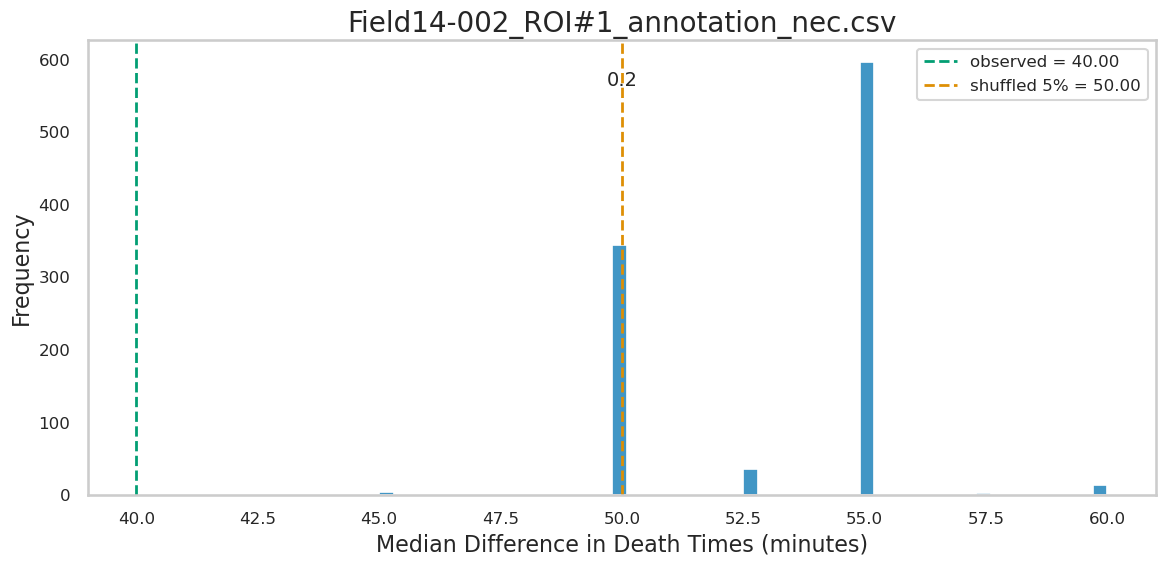

0.0


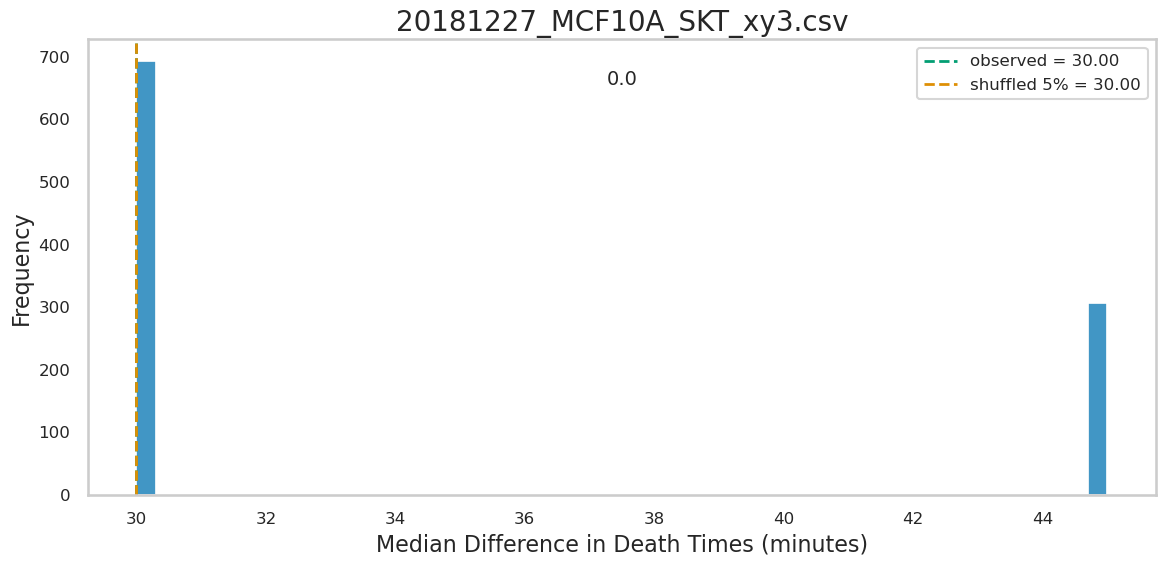

0.0


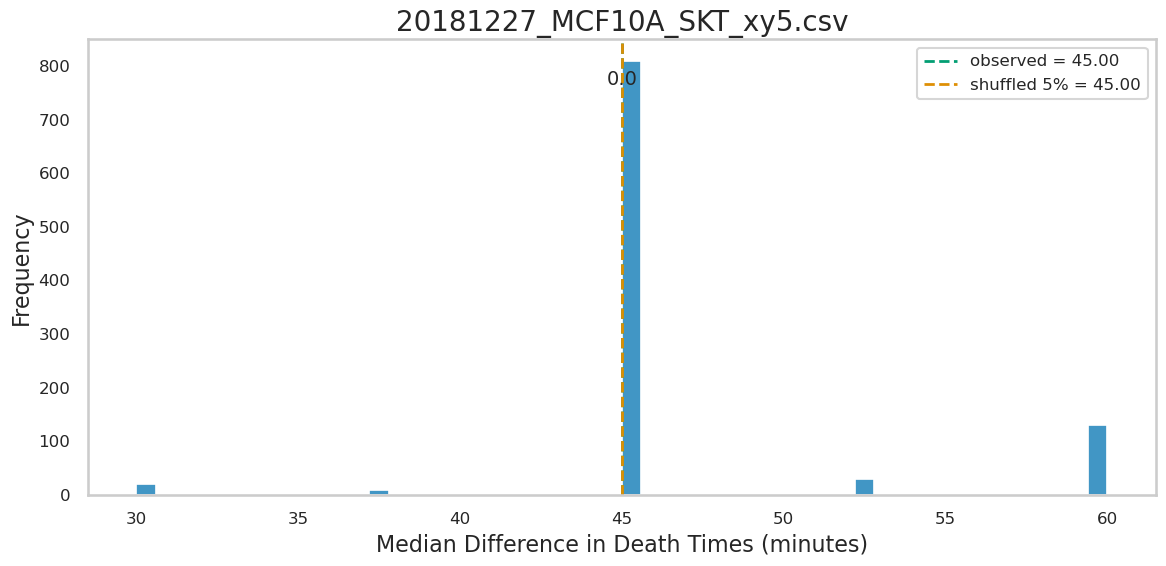

0.0


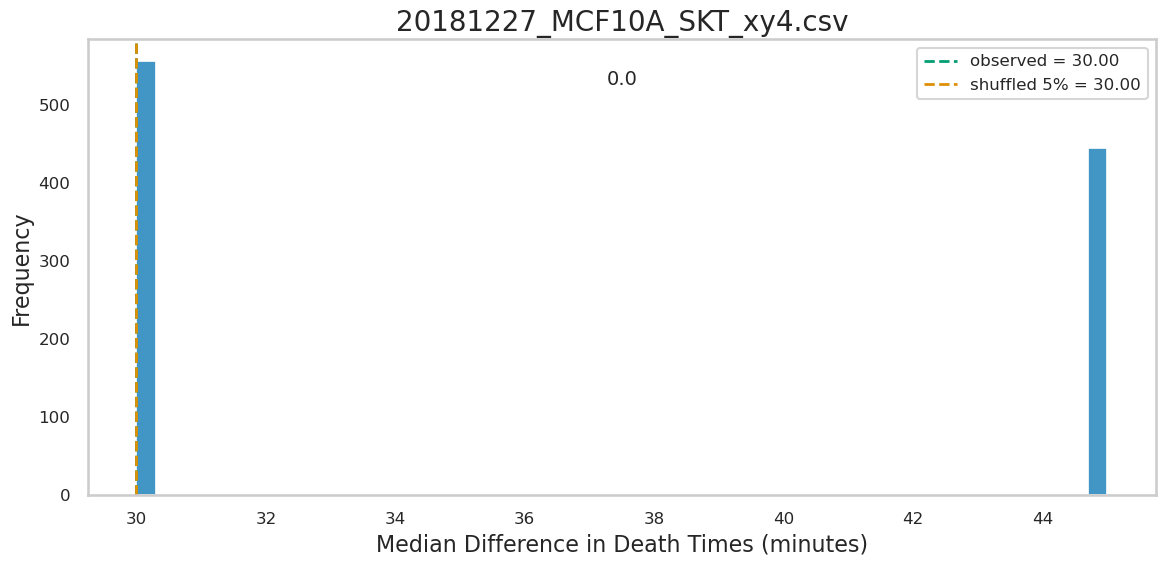

In [7]:
single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only/'#Field14-002_ROI#1_annotation_nec.csv'
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    ob_med = mSpiCalc(XY=cells_loci,
                        die_times=cells_times_of_death,
                        treatment='ML162',
                        temporal_resolution=10,
                        n_scramble=1000,
                        draw=False,
                        dist_threshold=50, 
                        filter_neighbors_by_distance=True,
                        filter_neighbors_by_level= 1,
                        time_unit='minutes',)
    print(ob_med.get_mspis())
    median_of_shuffles = ob_med.all_shuffled_median_sorted
    flattened_array = np.array(median_of_shuffles)
    # print(flattened_array)
    median_5_pre =  ob_med.scramble_signficance_95
    median_observed = ob_med.original_difference_death_times
    plot_histogram_with_lines(flattened_array, observed=median_observed, shuffled_5_per= median_5_pre.item(), bins=50, title=file, xlabel="Median Difference in Death Times (minutes)", ylabel="Frequency", text = str(ob_med.get_mspis()))

# SPI of pure vs mixed death

In [3]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [4]:
only_recent_death_flag_for_neighbors_calc = False
neighbors_dist_threshold = 100
sliding_time_window_size = 10
exps_dir_name = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'
meta_data_file_full_path = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
meta_data_df = pd.read_csv(meta_data_file_full_path)
all_previous_experiments_spi_and_ni_regeneration = calc_all_experiments_SPI_and_NI_for_landscape(
        exp_name=list(exp_names),
        exps_dir_path=exps_dir_name,
        meta_data_full_file_path=meta_data_file_full_path,
        dist_threshold=neighbors_dist_threshold,
        only_recent_death_flag_for_neighbors_calc=only_recent_death_flag_for_neighbors_calc,
        time_unit="minutes",
        sliding_time_window_size=sliding_time_window_size
    )


In [5]:
reformatting_all_previos_experiments_spi_and_ni_regeneration = {"Experiment_name":[],
                                                                "SPI":[],
                                                                "NI":[],
                                                                "Treatment":[],
                                                                "Cell Line + Treatment":[],
                                                                "Cell Line":[], 
                                                                "Mode":[],
                                                                "Density":[]}

for key,value in all_previous_experiments_spi_and_ni_regeneration.items():
    if value is None:
        continue
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Experiment_name"].append(key)
    exp_cell_line= meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["Cell Line"].values[0]
    if meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["DeathMode"].values[0] == 'mixed' and meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["Pureness"].values[0] =='mixed':
        reformatting_all_previos_experiments_spi_and_ni_regeneration['Mode'].append('mixed') 
    elif meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["DeathMode"].values[0] == 'pure' and meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["Pureness"].values[0] =='pure':
        reformatting_all_previos_experiments_spi_and_ni_regeneration['Mode'].append('pure')
    else:
        reformatting_all_previos_experiments_spi_and_ni_regeneration['Mode'].append('artificial')  
    reformatting_all_previos_experiments_spi_and_ni_regeneration["SPI"].append(value[0])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["NI"].append(value[1])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line"].append(exp_cell_line)
    treatment_  = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["Treatment"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line + Treatment"].append(replace_ugly_long_name(treatment_,exp_cell_line))
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Treatment"].append(treatment_)
    density = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Density(#Cells)"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Density"].append(density)
    

In [6]:
reformatting_all_previos_experiments_spi_and_ni_regeneration_df = pd.DataFrame(reformatting_all_previos_experiments_spi_and_ni_regeneration)
reformatting_all_previos_experiments_spi_and_ni_regeneration_df

,Experiment_name,SPI,NI,Treatment,Cell Line + Treatment,Cell Line,Mode,Density
0,field13_crop-001_ROI#1_annotation_apop.csv,0.056496,0.151899,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,237
1,field13_crop-001_ROI#1_annotation_nec.csv,0.260464,0.119741,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,309
2,Field14-002_ROI#1_annotation_apop.csv,0.162178,0.152455,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,387
3,Field14-002_ROI#1_annotation_nec.csv,0.200932,0.136546,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,249
4,3-19-2924_10ah2bmcherry_ROI#2_annotation_apop.csv,-10.636364,0.600000,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,5
5,3-19-2924_10ah2bmcherry_ROI#2_annotation_nec.csv,0.161690,0.142857,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,56
6,7-20-23_10arednuclei_ROI#10_annotation_apop.csv,0.033934,0.170213,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,47
7,7-20-23_10arednuclei_ROI#10_annotation_nec.csv,0.323847,0.147887,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,142
8,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,0.247991,0.141129,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,248
9,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,0.546522,0.089337,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,348


In [17]:
reformatting_all_previos_experiments_spi_and_ni_regeneration_df = pd.DataFrame(reformatting_all_previos_experiments_spi_and_ni_regeneration)
reformatting_all_previos_experiments_spi_and_ni_regeneration_df

,Experiment_name,SPI,NI,Treatment,Cell Line + Treatment,Cell Line,Mode,Density
0,field13_crop-001_ROI#1_annotation_apop.csv,0.094713,0.202532,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,237
1,field13_crop-001_ROI#1_annotation_nec.csv,0.310440,0.126214,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,309
2,Field14-002_ROI#1_annotation_apop.csv,0.168775,0.186047,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,387
3,Field14-002_ROI#1_annotation_nec.csv,0.312766,0.160643,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,249
4,3-19-2924_10ah2bmcherry_ROI#2_annotation_apop.csv,-42.000000,0.800000,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,5
5,3-19-2924_10ah2bmcherry_ROI#2_annotation_nec.csv,0.169662,0.178571,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,56
6,7-20-23_10arednuclei_ROI#10_annotation_apop.csv,-0.527869,0.297872,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,47
7,7-20-23_10arednuclei_ROI#10_annotation_nec.csv,0.370929,0.176056,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,142
8,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,0.248762,0.145161,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,248
9,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,0.577919,0.100865,Ml162+ starvation,MCF10A+ML162,MCF10A,artificial,348


In [21]:
subset_temp = reformatting_all_previos_experiments_spi_and_ni_regeneration_df[(reformatting_all_previos_experiments_spi_and_ni_regeneration_df["Mode"]!='artificial') & (reformatting_all_previos_experiments_spi_and_ni_regeneration_df["Treatment"]!='SKT')]

In [7]:
subset_temp = subset_temp[subset_temp["Density"]>65]

NameError: name 'subset_temp' is not defined

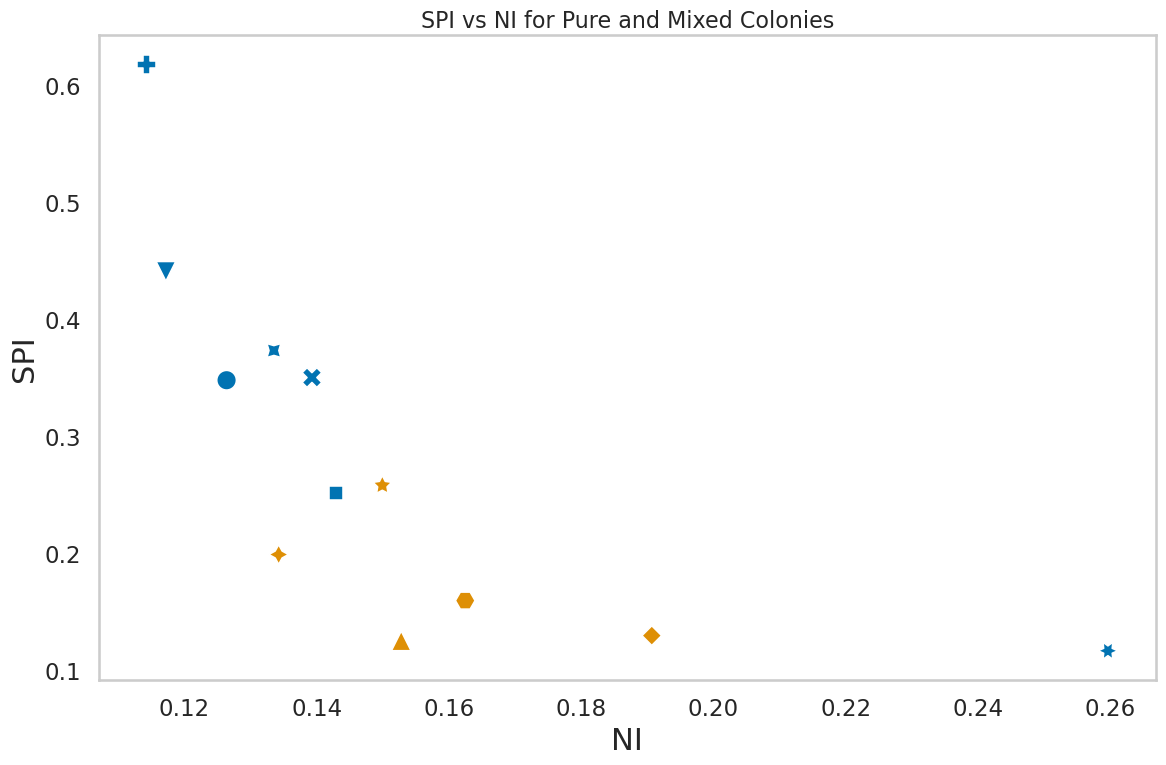

In [32]:
def plot_spi_vs_ni(dataframe):
    """
    Plots SPI vs NI for pure and mixed colonies based on the 'Mode' column and uses 'Experiment_name' as marker style.

    Parameters:
    - dataframe: pandas DataFrame containing SPI, NI, Mode, and Experiment_name columns.
    """
    sns.set_palette("colorblind")
    sns.set_context("talk")
    sns.set_style("whitegrid")

    plt.figure(figsize=(12, 8))
    ax = sns.scatterplot(
        data=dataframe,
        x="NI",
        y="SPI",
        hue="Mode",
        style="Experiment_name",
        s=200
    )

    plt.title("SPI vs NI for Pure and Mixed Colonies", fontsize=16)
    plt.xlabel("NI", fontsize=22)
    plt.ylabel("SPI", fontsize=22)
    ax.legend_.remove()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# Example usage
plot_spi_vs_ni(subset_temp)


# Exploring Pockets

In [3]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
sys.path.append("/sise/assafzar-group/assafzar/Esraa/CellDeathQuantification/")
from src.NucleationAndPropagationMeasurements import *
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [ ]:
single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only/'#Field14-002_ROI#1_annotation_nec.csv'
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    print(file)
    ob = uSpiCalc(XY=cells_loci,
                        die_times=cells_times_of_death,
                        treatment='ML162',
                        temporal_resolution=10,
                        n_scramble=1000,
                        draw=False,
                        dist_threshold=50, 
                        filter_neighbors_by_distance=True,
                        filter_neighbors_by_level= 3,
                        time_unit='minutes',)
    print(ob.get_uspis())
    tod_list, dist_dist, comm = ob.get_tod_dist_from_nucluator(3)
    
    correlation, p_value = pearsonr(tod_list, dist_dist)
    print("Pearson correlation:", correlation)
    print("P-value:", p_value)
    correlation, p_value = spearmanr(tod_list, dist_dist)
    print("Pearson correlation:", correlation)
    print("P-value:", p_value)

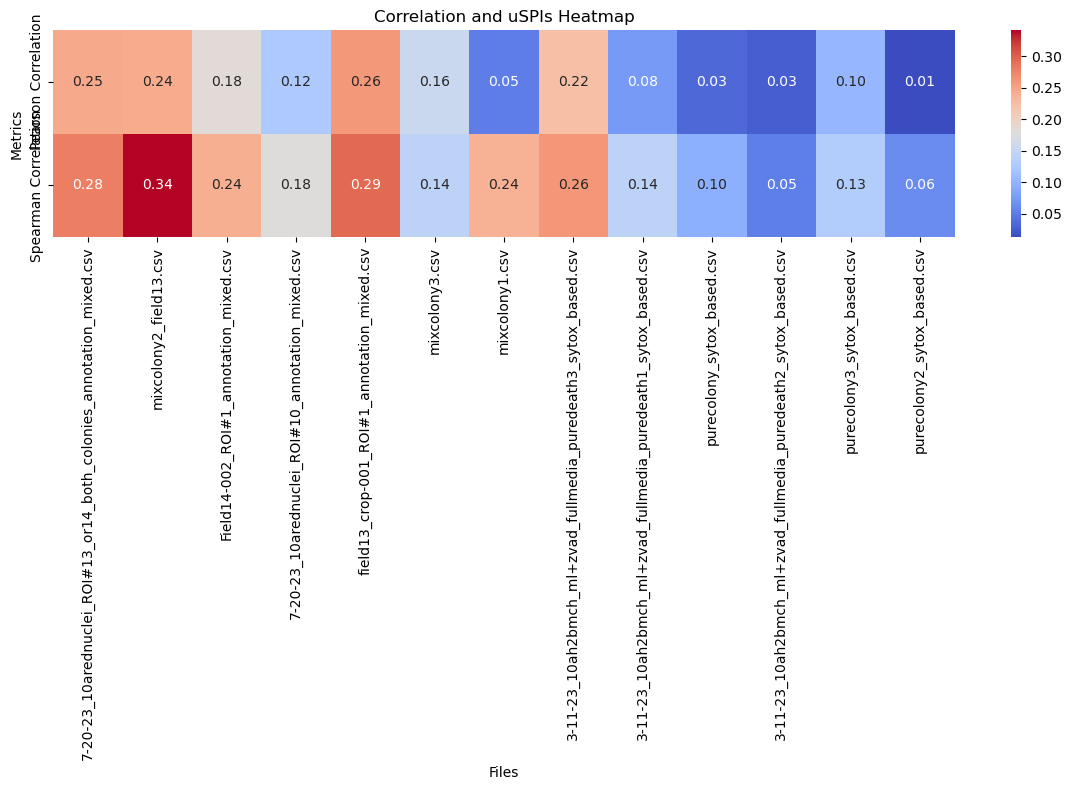

In [19]:
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

# Initialize a list to store data for the heatmap
heatmap_data = []
single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'
# Iterate through files and calculate correlations and uSPIs
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    if 'nec' in file or 'apop' in file or 'SKT' in file or 'outli' in file:
        continue
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    ob = uSpiCalc(XY=cells_loci,
                  die_times=cells_times_of_death,
                  treatment='ML162',
                  temporal_resolution=10,
                  n_scramble=1000,
                  draw=False,
                  dist_threshold=100, 
                  filter_neighbors_by_distance=True,
                  filter_neighbors_by_level=3,
                  time_unit='minutes',)
    
    tod_list, dist_dist, comm = ob.get_tod_dist_from_nucluator(3)
    try:
        pearson_corr, pearson_p_value = pearsonr(tod_list, dist_dist)
        spearman_corr, spearman_p_value = spearmanr(tod_list, dist_dist)
    except Exception:
        print(file)
        pearson_corr, pearson_p_value = 0, 1 
        spearman_corr, spearman_p_value = 0, 1 
    uspis = ob.get_uspis()
    
    # Append data for the heatmap
    heatmap_data.append({
        'File': file,
        'Pearson Correlation': pearson_corr,
        'Pearson P-value': pearson_p_value,
        'Spearman Correlation': spearman_corr,
        'Spearman P-value': spearman_p_value,
    })

# Convert the data to a DataFrame
heatmap_df = pd.DataFrame(heatmap_data)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df[['Pearson Correlation', 'Spearman Correlation']].T, 
            annot=True, fmt=".2f", cmap="coolwarm", xticklabels=heatmap_df['File'])
plt.title("Correlation and uSPIs Heatmap")
plt.xlabel("Files")
plt.ylabel("Metrics")
plt.tight_layout()
plt.show()

# Display p-values for Pearson and Spearman correlations
# print("P-values for Pearson and Spearman correlations:")
# print(heatmap_df[['File', 'Pearson Correlation', 'Spearman Correlation']])

In [20]:
heatmap_df = pd.DataFrame(heatmap_data)
heatmap_df = heatmap_df[~heatmap_df['File'].str.contains('skt|nec|apop|outl', case=False, regex=True)]

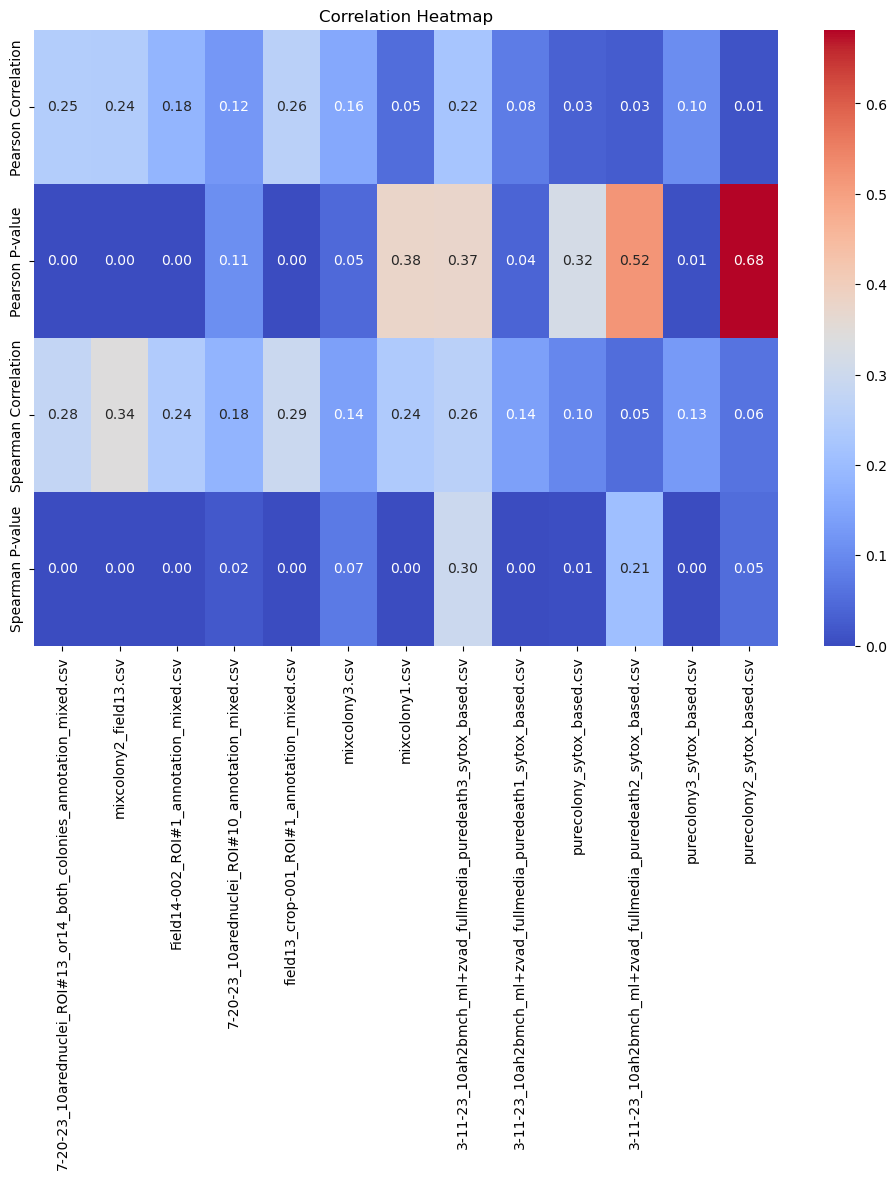

In [21]:


# Plot the heatmap
plt.figure(figsize=(12, 8))
# sns.heatmap(heatmap_df[['Pearson Correlation', 'Spearman Correlation', 'uSPIs']].T, 
#             annot=True, fmt=".2f", cmap="coolwarm", xticklabels=heatmap_df['File'])
plt.title("Correlation Heatmap")
plt.xlabel("Files")
plt.ylabel("Metrics")
sns.heatmap(heatmap_df[['Pearson Correlation', 'Pearson P-value', 'Spearman Correlation', 'Spearman P-value']].T, 
            annot=True, fmt=".2f", cmap="coolwarm", xticklabels=heatmap_df['File'])
plt.show()

# # Display p-values for Pearson and Spearman correlations
# print("P-values for Pearson and Spearman correlations:")
# print(heatmap_df[['File', 'Pearson Correlation', 'Spearman Correlation']])

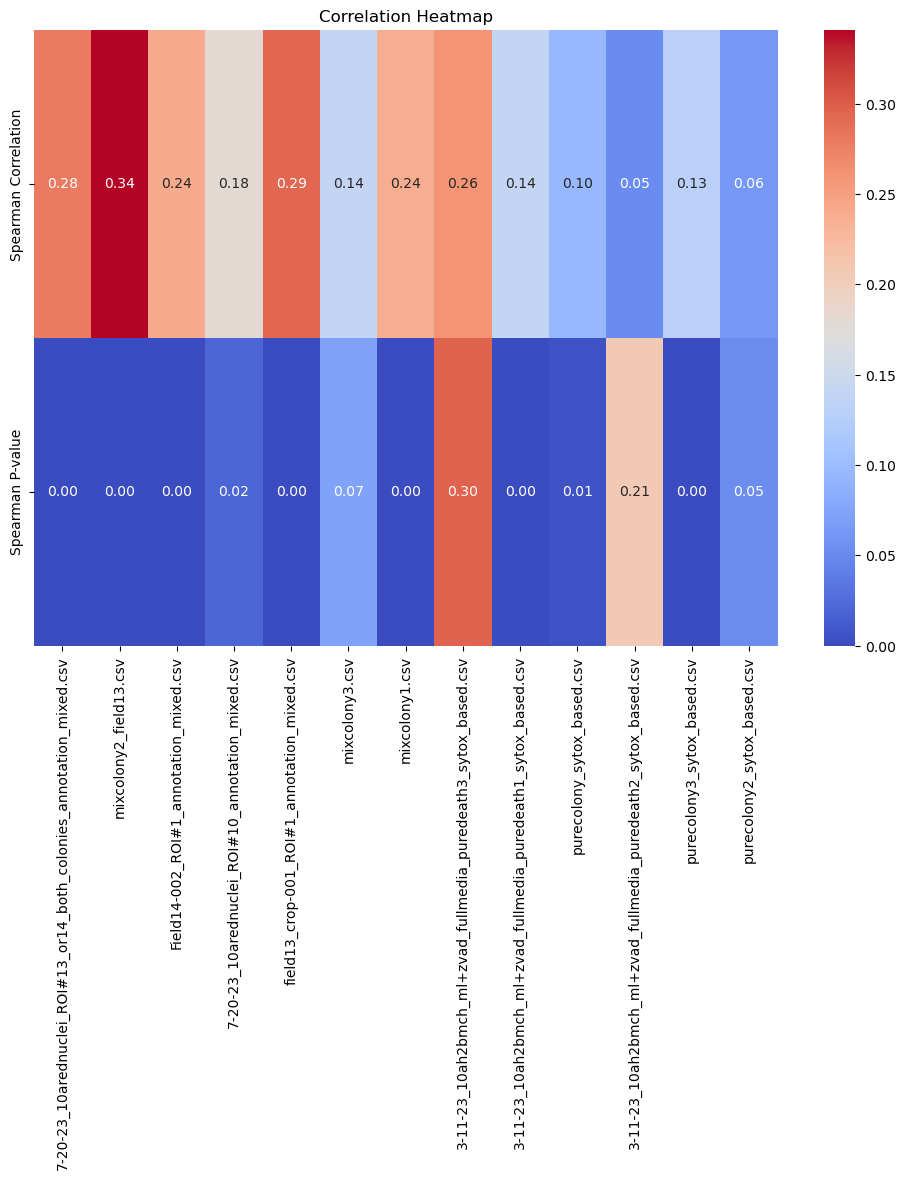

In [23]:


# Plot the heatmap
plt.figure(figsize=(12, 8))
# sns.heatmap(heatmap_df[['Pearson Correlation', 'Spearman Correlation', 'uSPIs']].T, 
#             annot=True, fmt=".2f", cmap="coolwarm", xticklabels=heatmap_df['File'])
plt.title("Correlation Heatmap")
plt.xlabel("Files")
plt.ylabel("Metrics")
sns.heatmap(heatmap_df[['Spearman Correlation', 'Spearman P-value']].T, 
            annot=True, fmt=".2f", cmap="coolwarm", xticklabels=heatmap_df['File'])
plt.show()

In [27]:
heatmap_df = heatmap_df[~heatmap_df['File'].str.contains('death3', case=False, regex=True)]

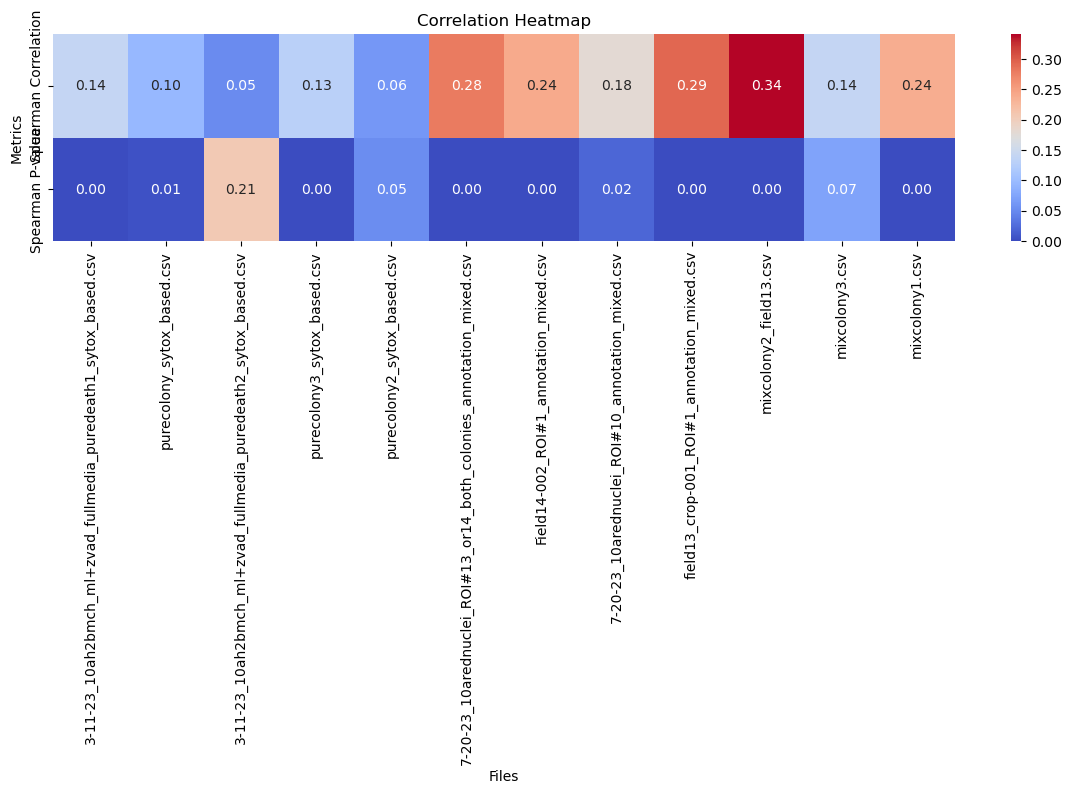

In [28]:
# Reorder heatmap_df: 'pure' files first, then 'mixed'
pure_mask = heatmap_df['File'].str.contains('pure', case=False)
mixed_mask = heatmap_df['File'].str.contains('mixed', case=False)

# Sort rows: pure first, then mixed, then all others (if any)
heatmap_df_sorted = pd.concat([
    heatmap_df[pure_mask],
    heatmap_df[mixed_mask & ~pure_mask],
    heatmap_df[~pure_mask & ~mixed_mask]
], axis=0)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_df_sorted[[ 'Spearman Correlation', 'Spearman P-value']].T, 
    annot=True, fmt=".2f", cmap="coolwarm", xticklabels=heatmap_df_sorted['File']
)
plt.title("Correlation Heatmap")
plt.xlabel("Files")
plt.ylabel("Metrics")
plt.tight_layout()
plt.show()


# Original time of death distribution

In [2]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
sys.path.append("/sise/assafzar-group/assafzar/Esraa/CellDeathQuantification/")
from src.NucleationAndPropagationMeasurements import *
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

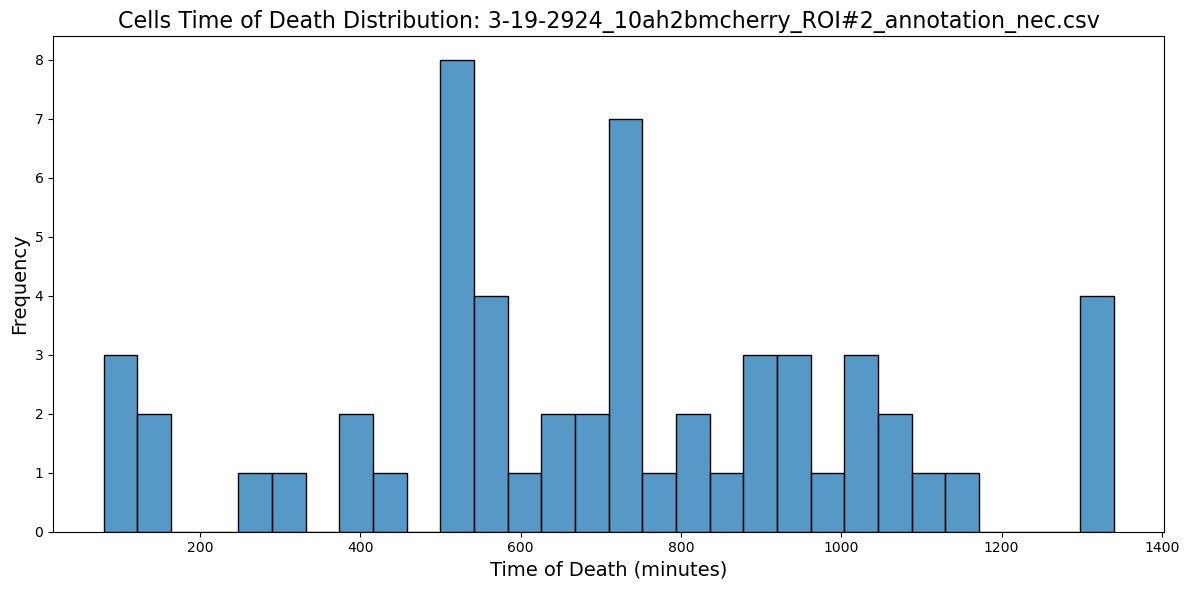

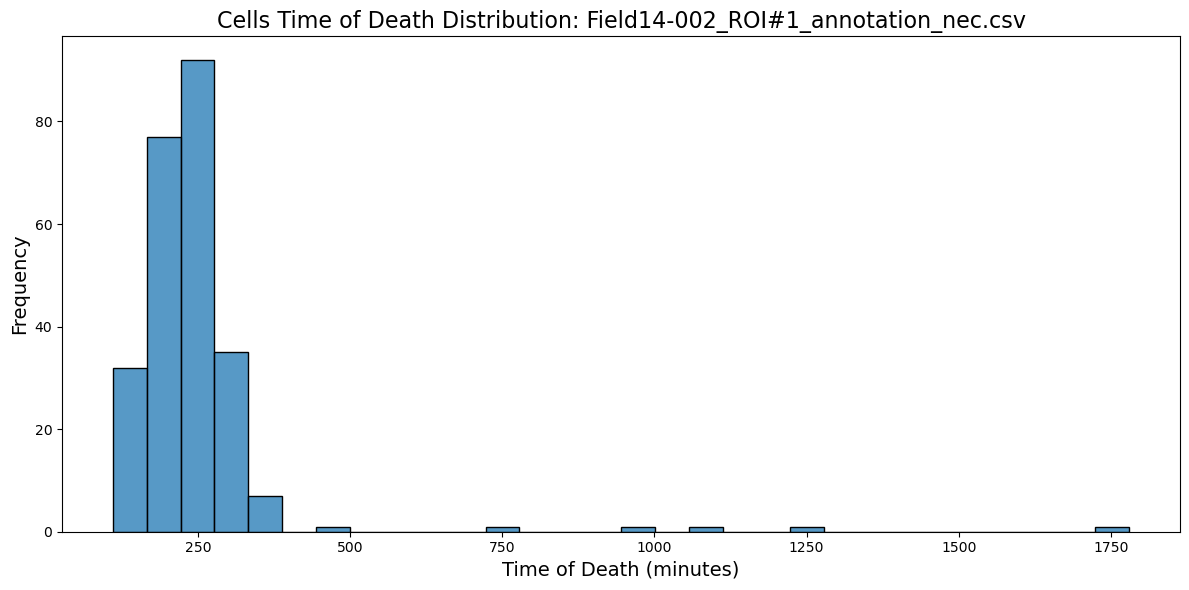

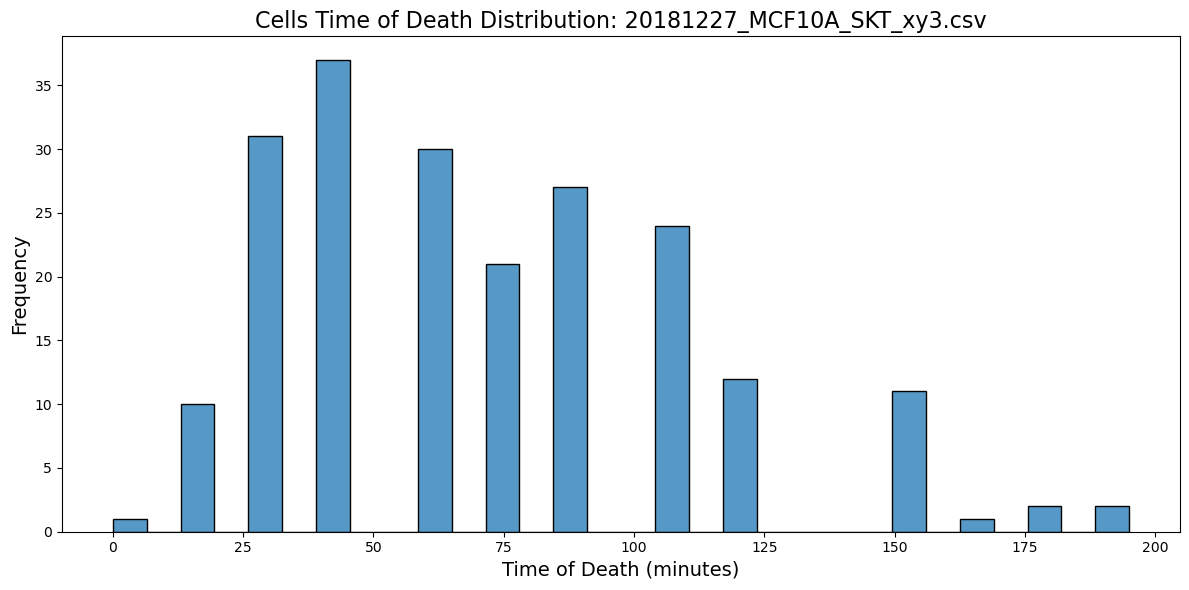

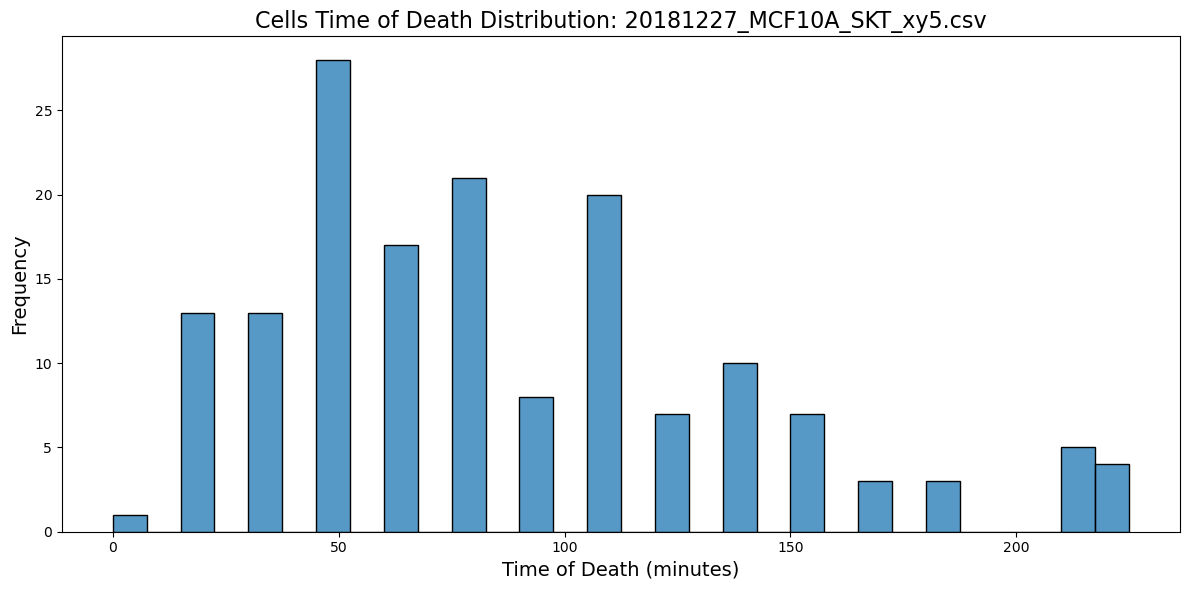

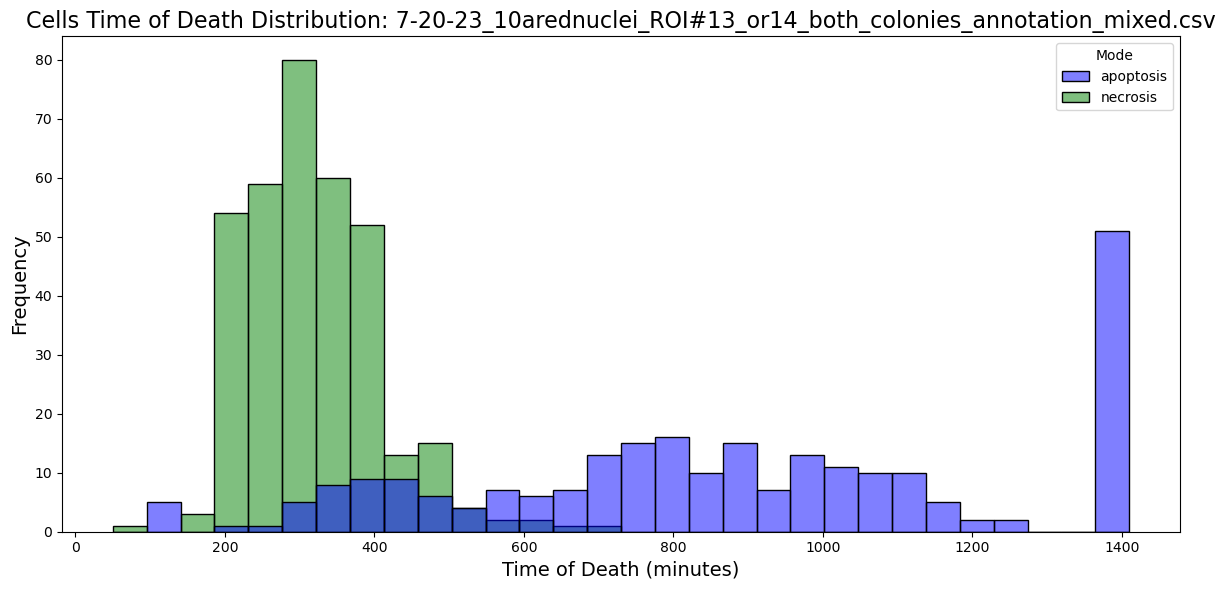

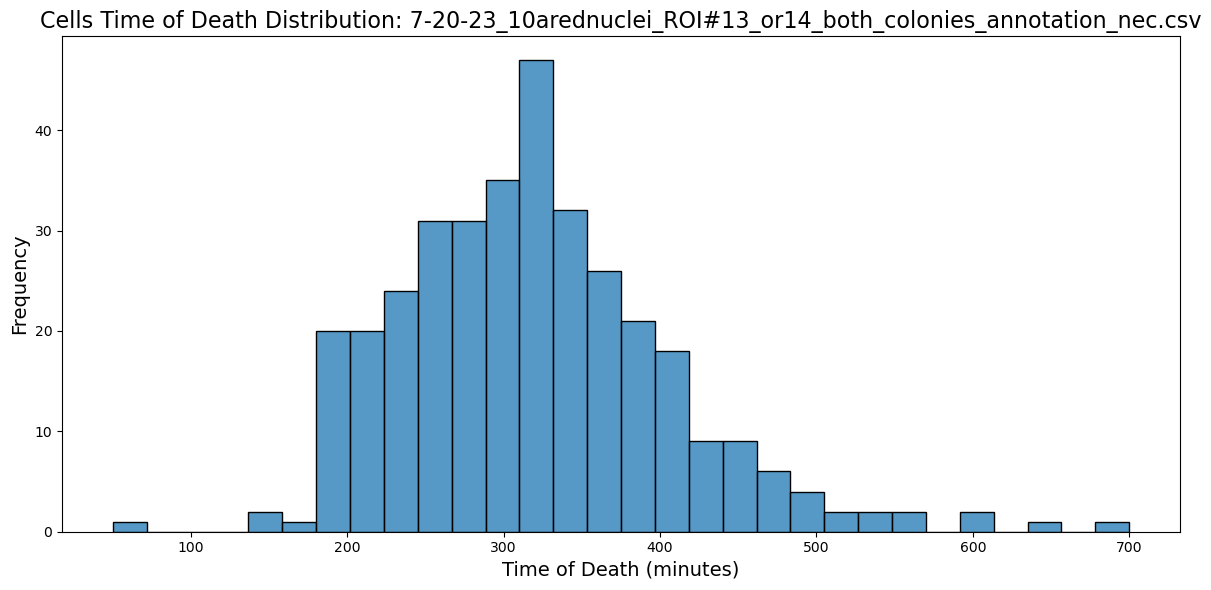

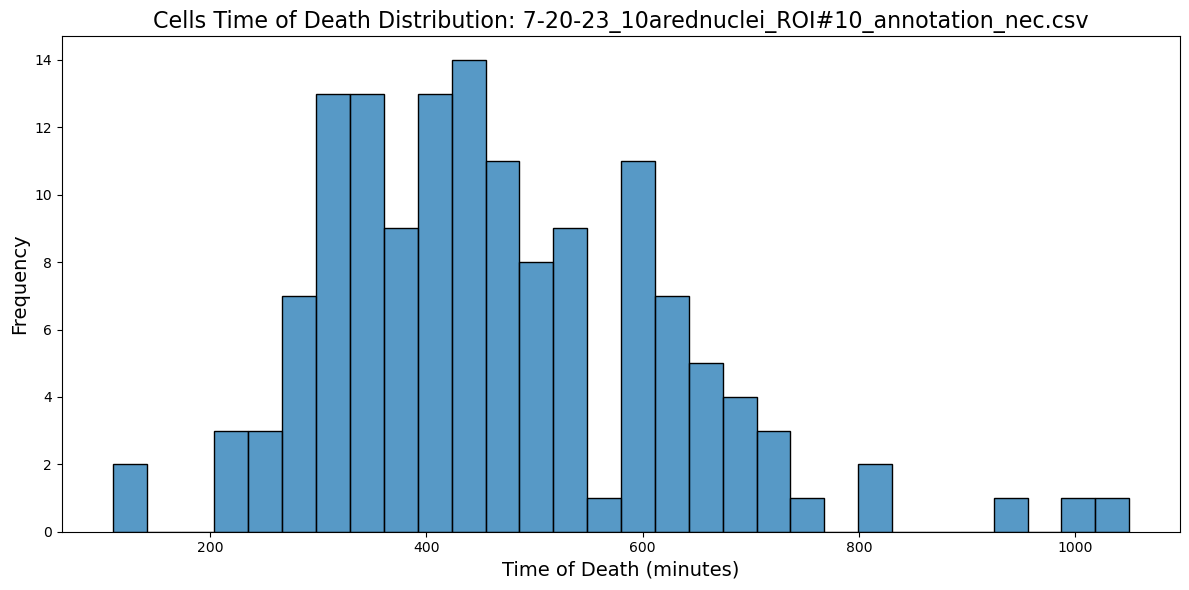

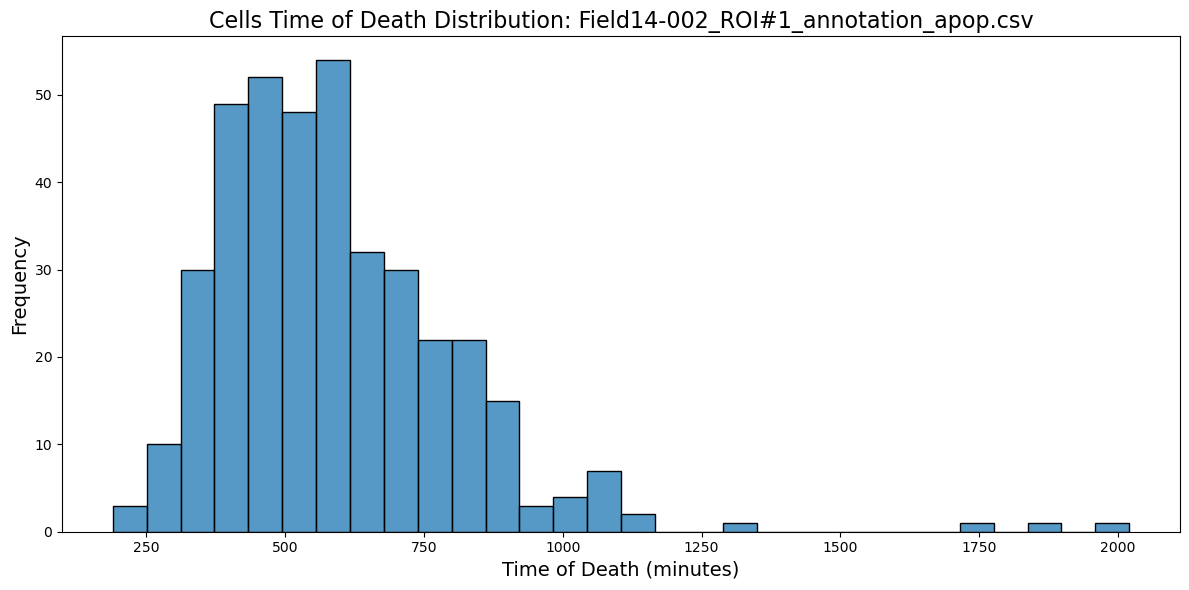

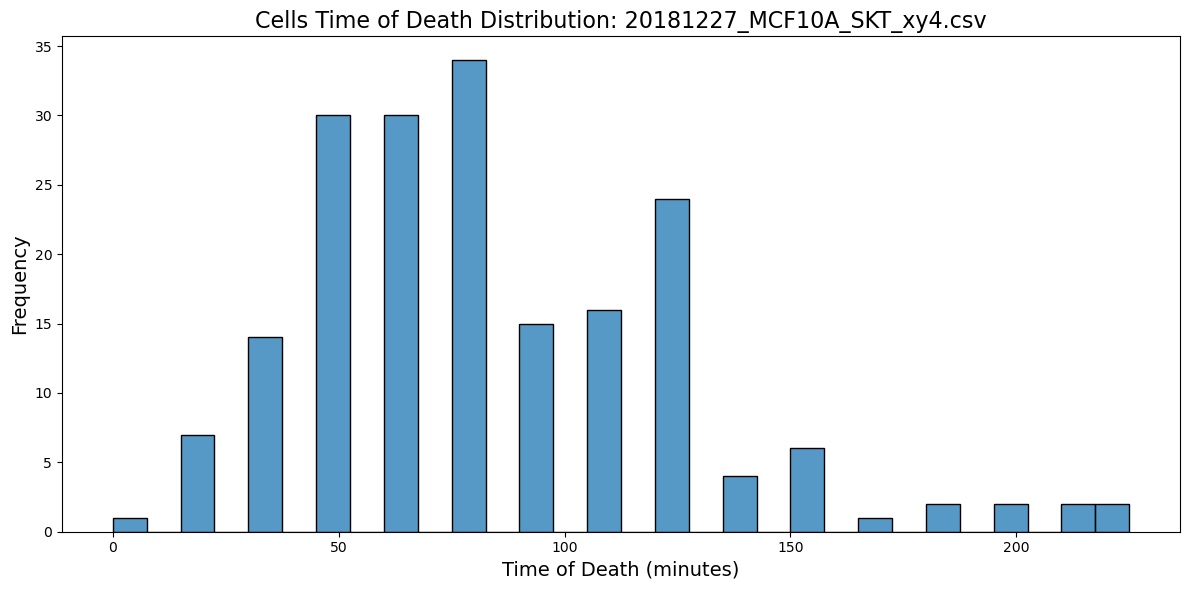

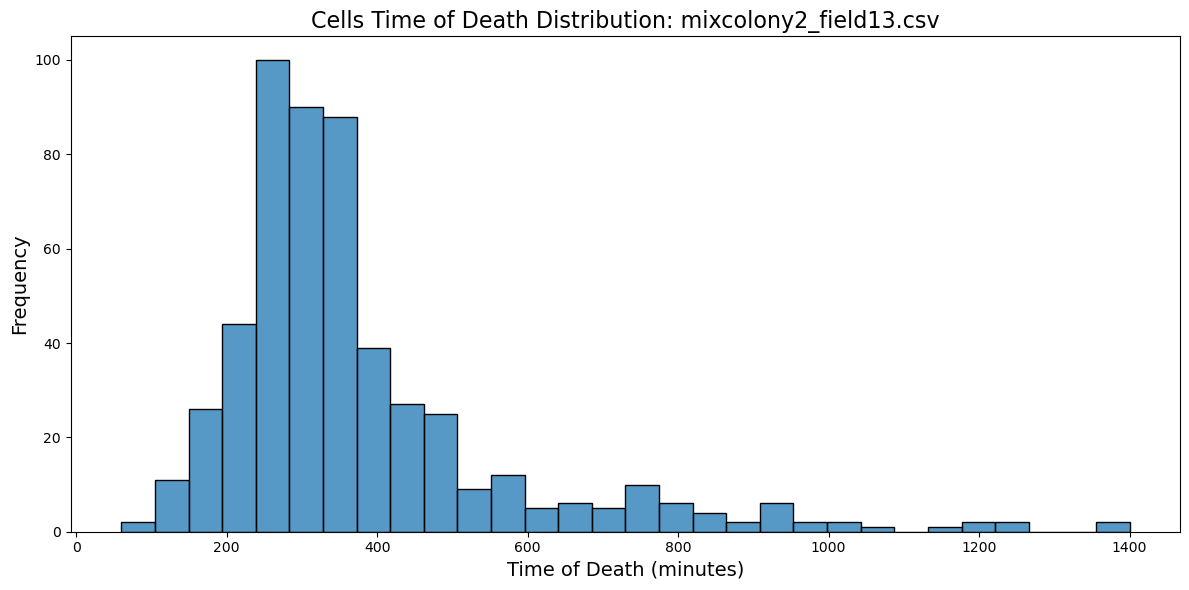

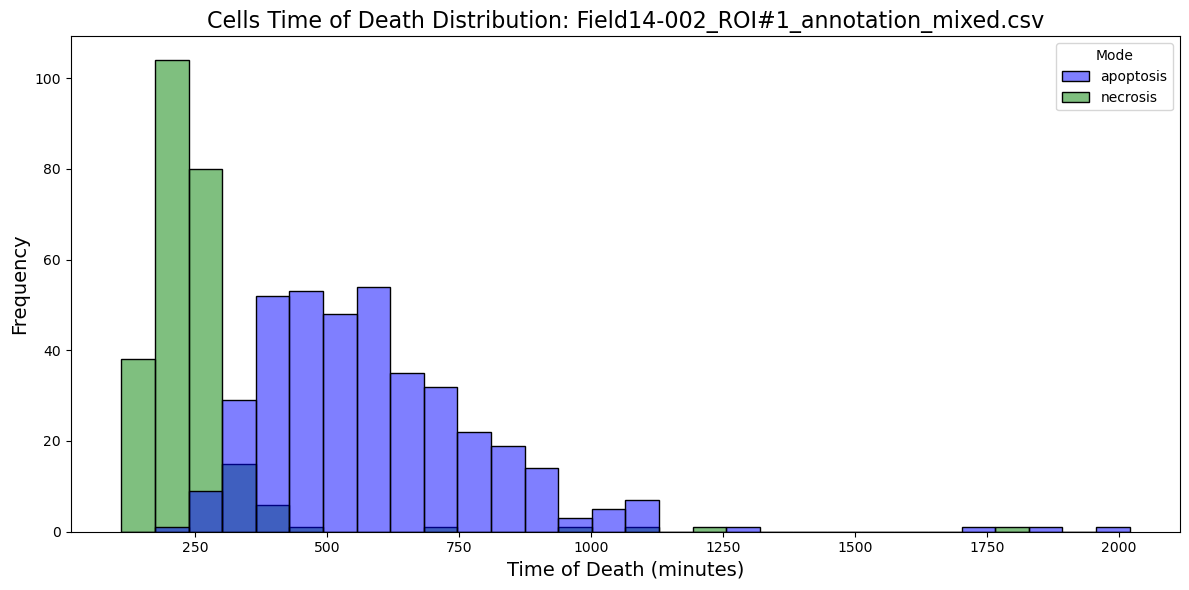

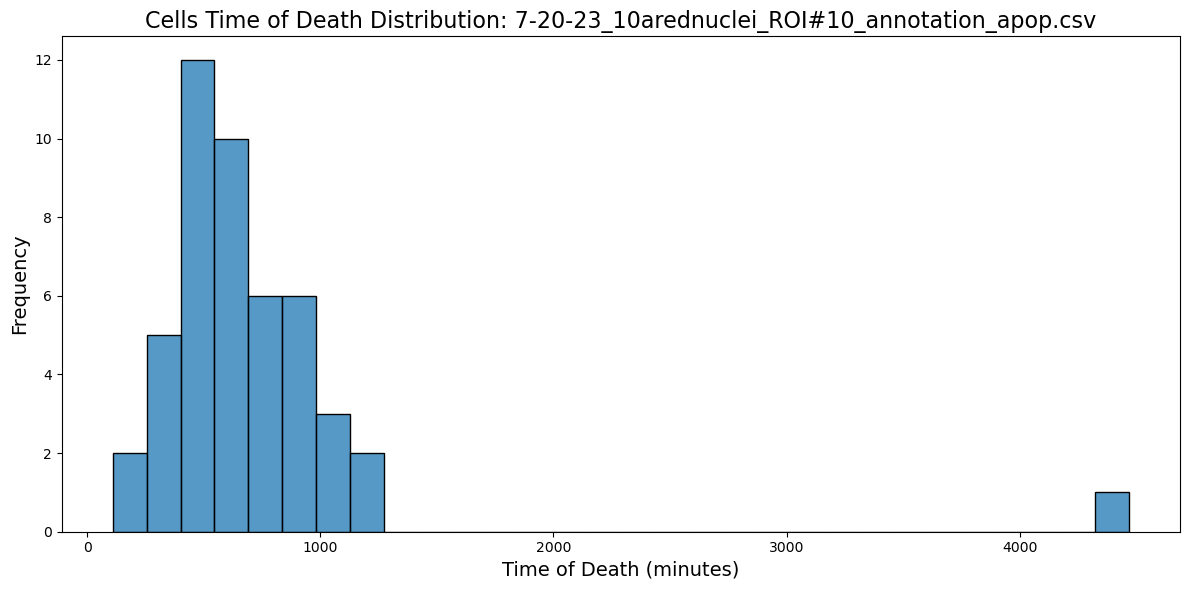

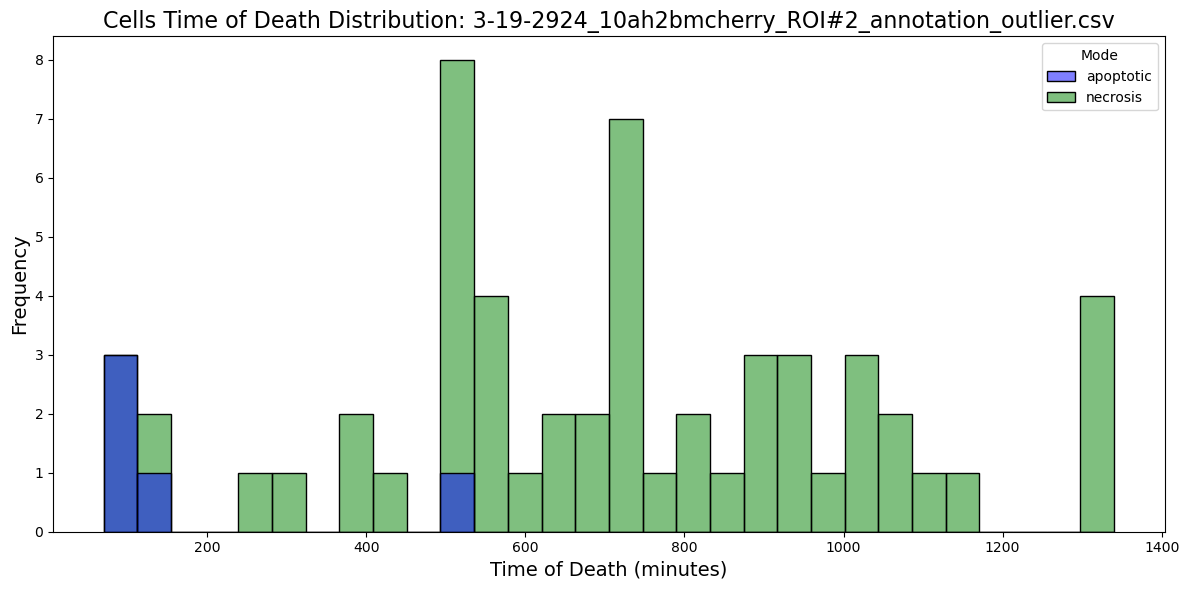

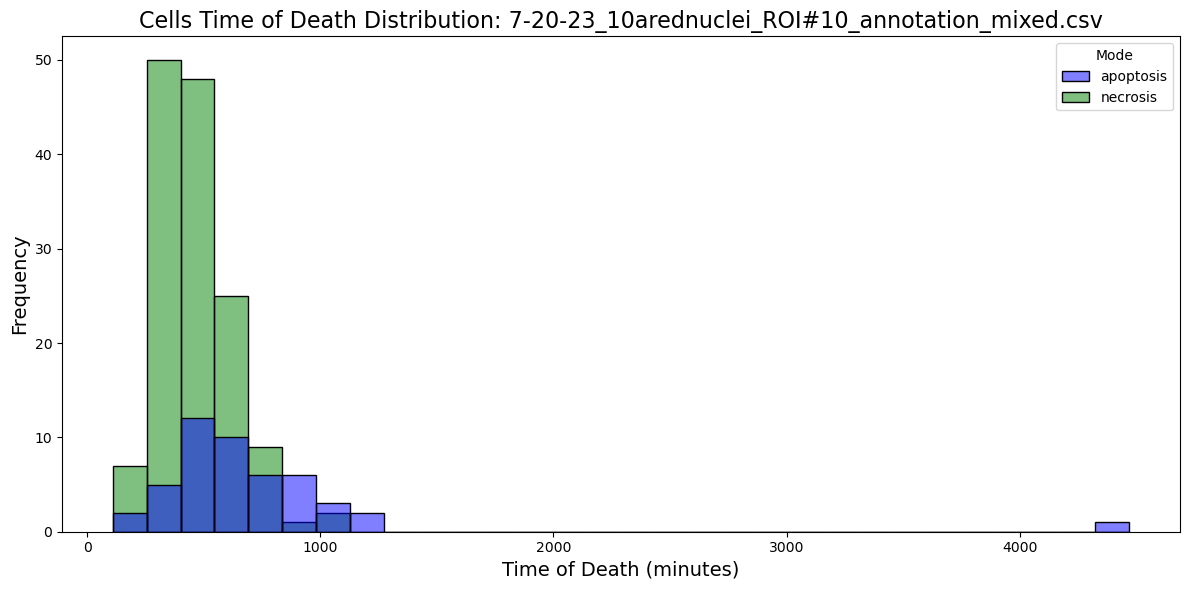

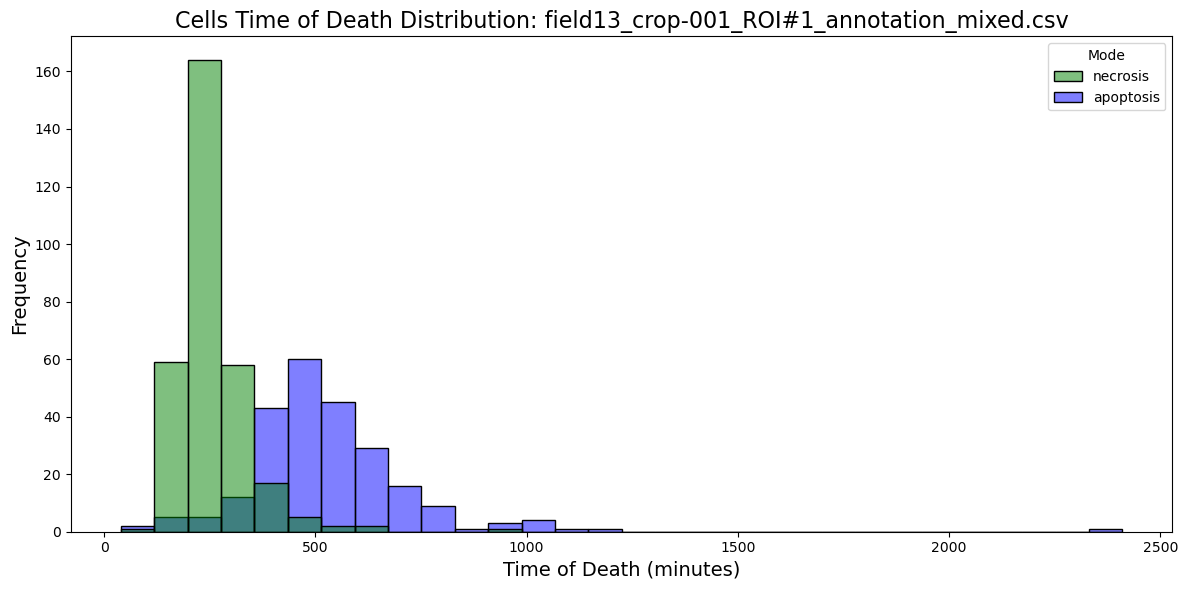

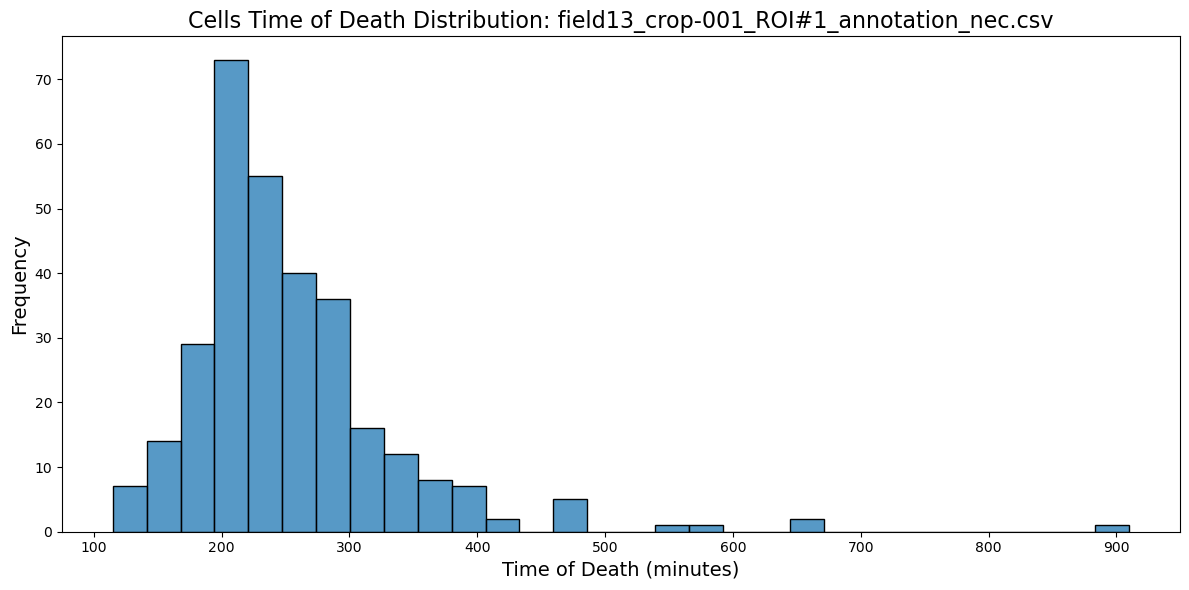

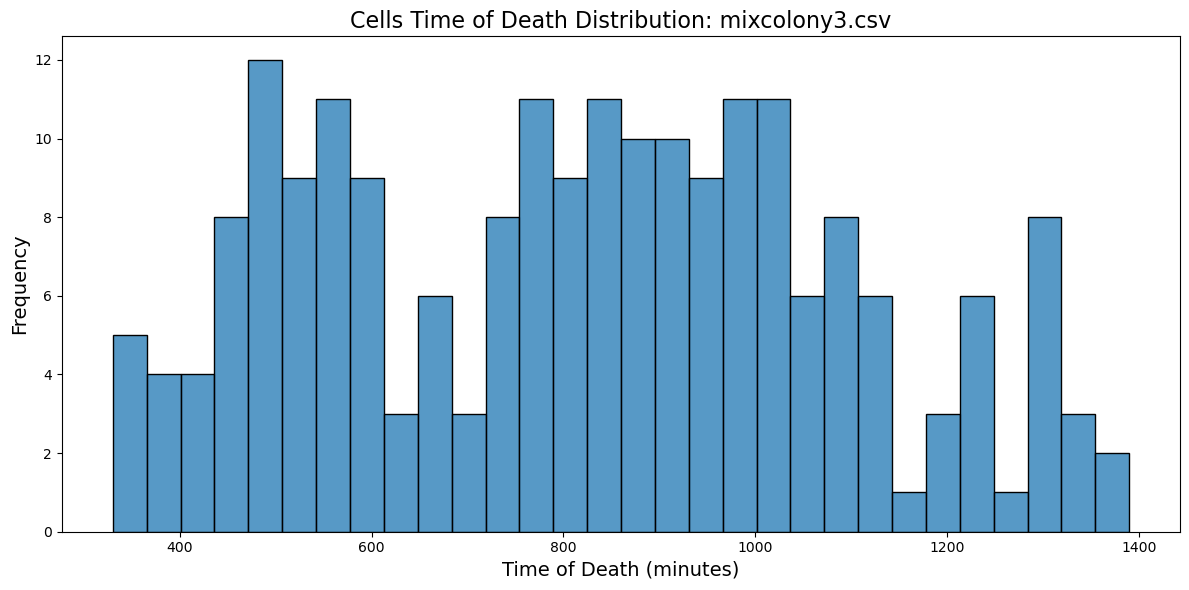

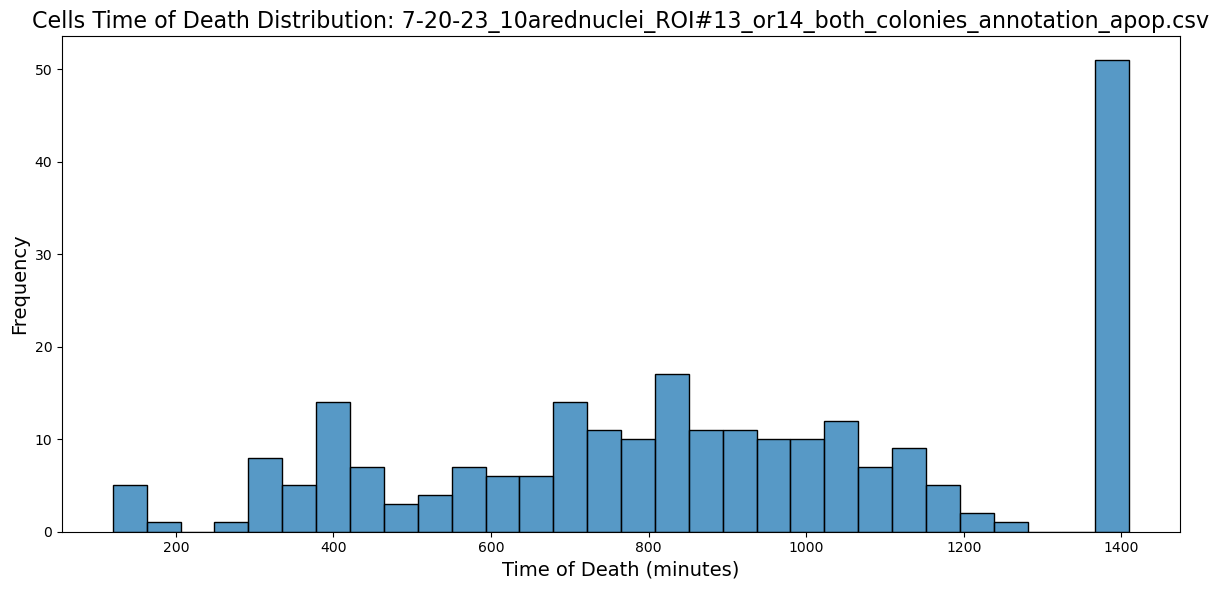

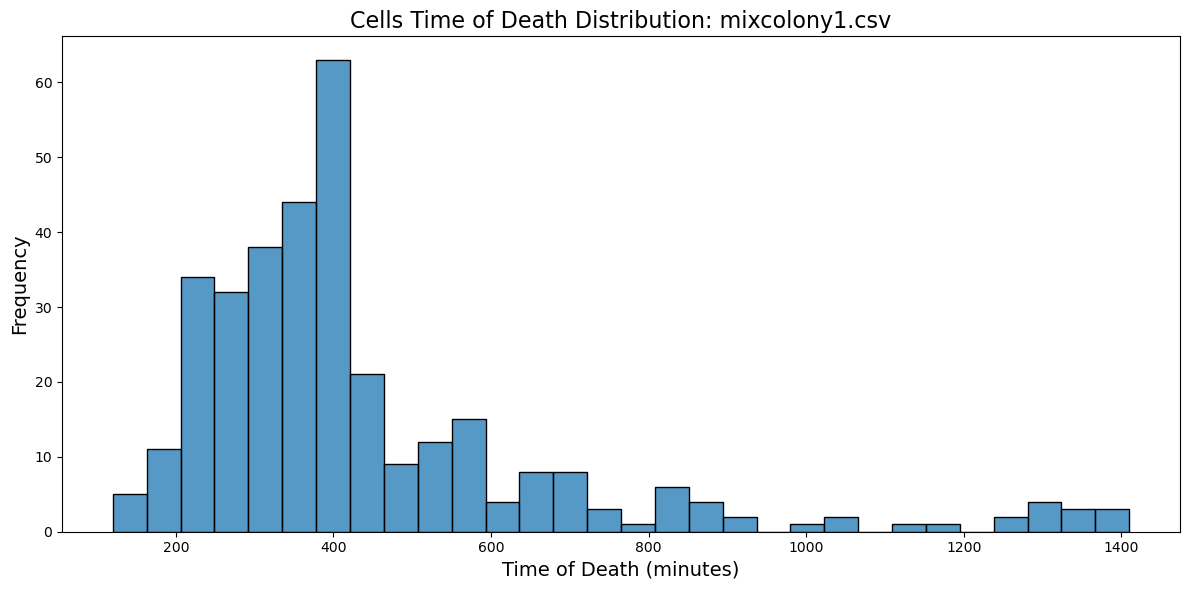

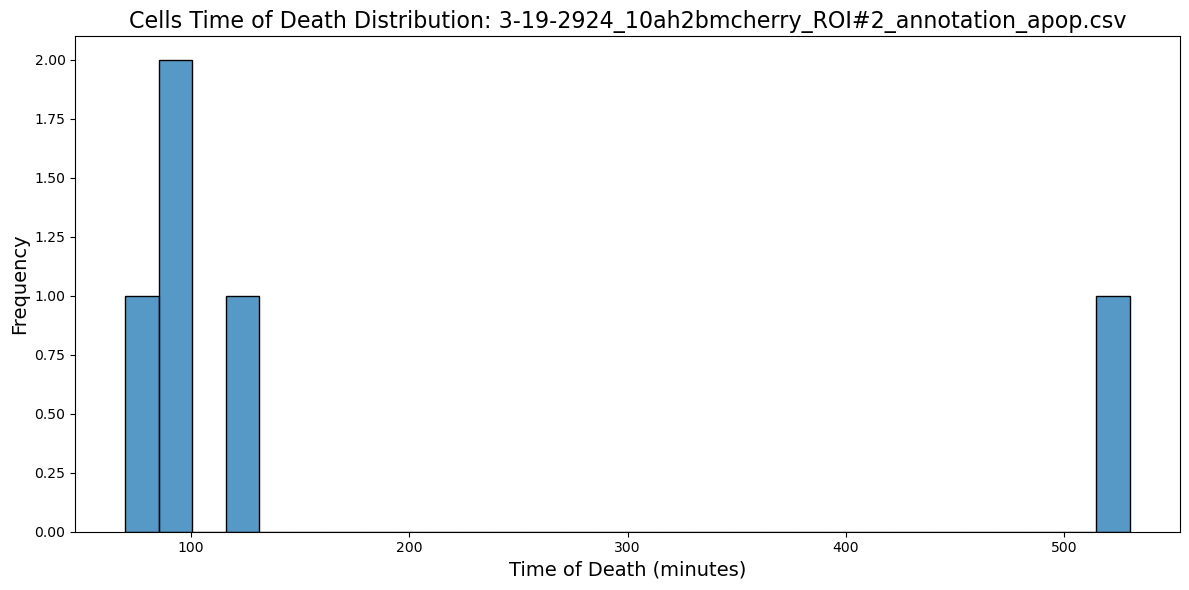

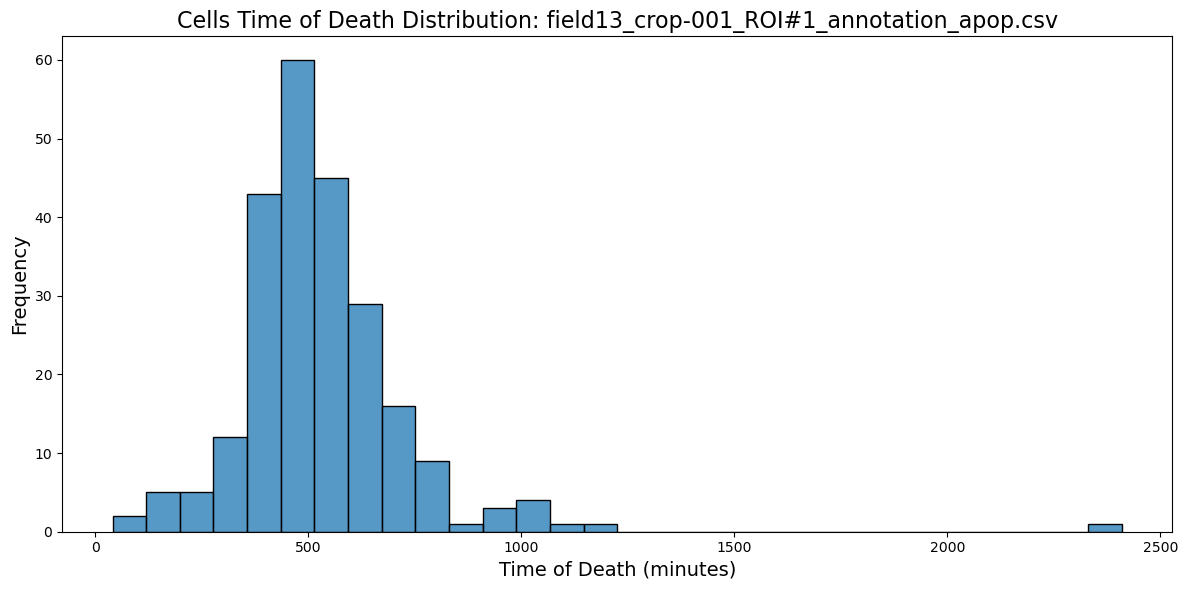

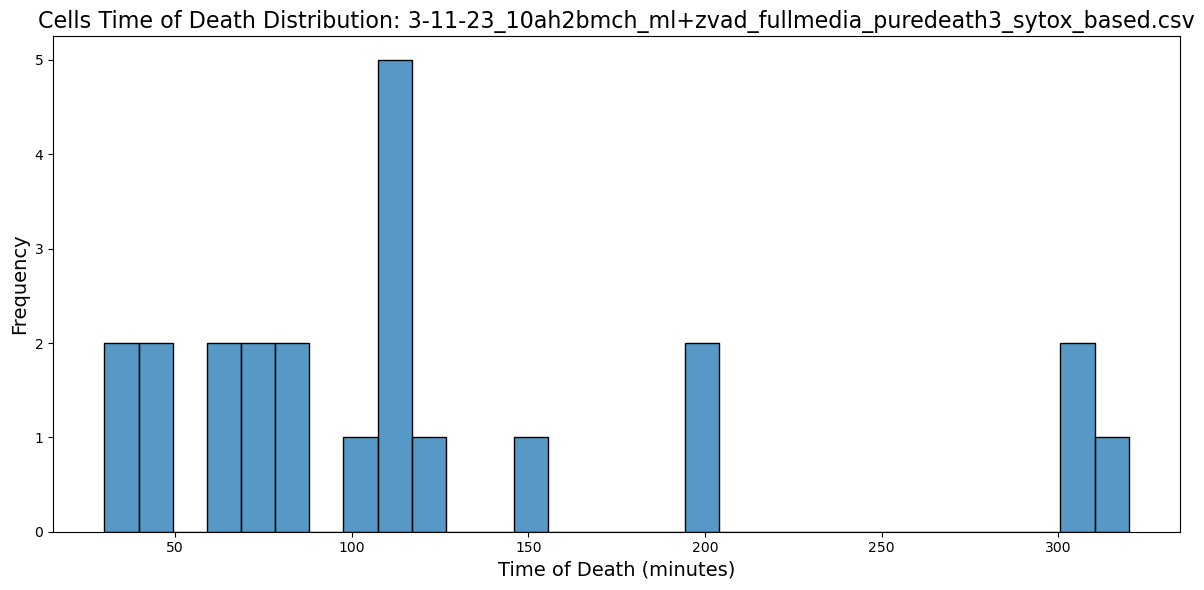

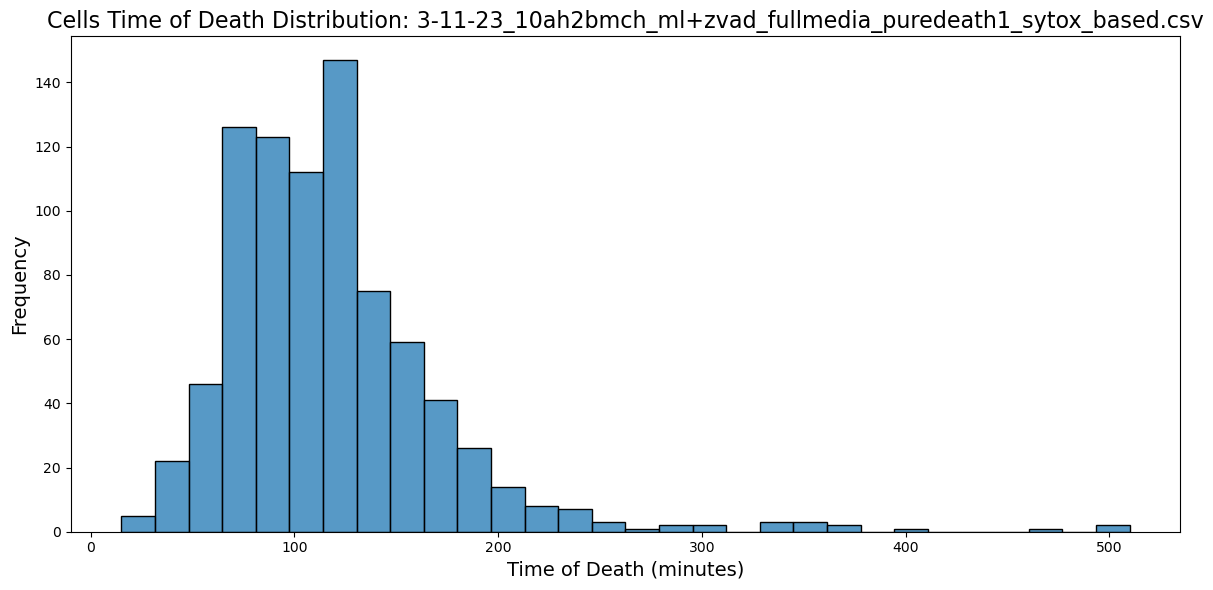

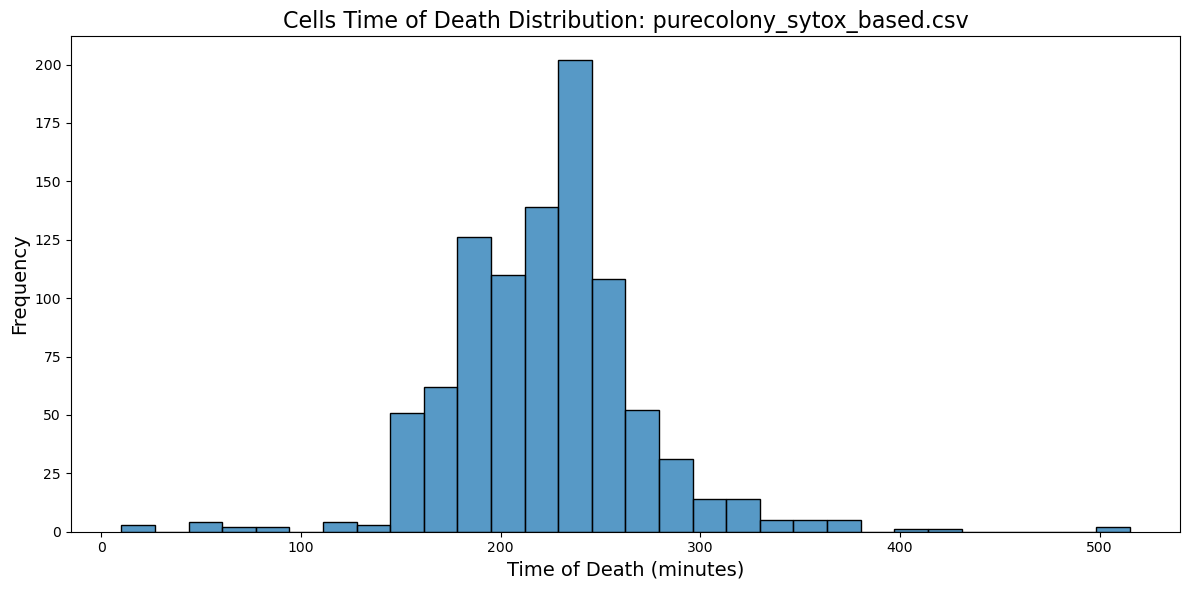

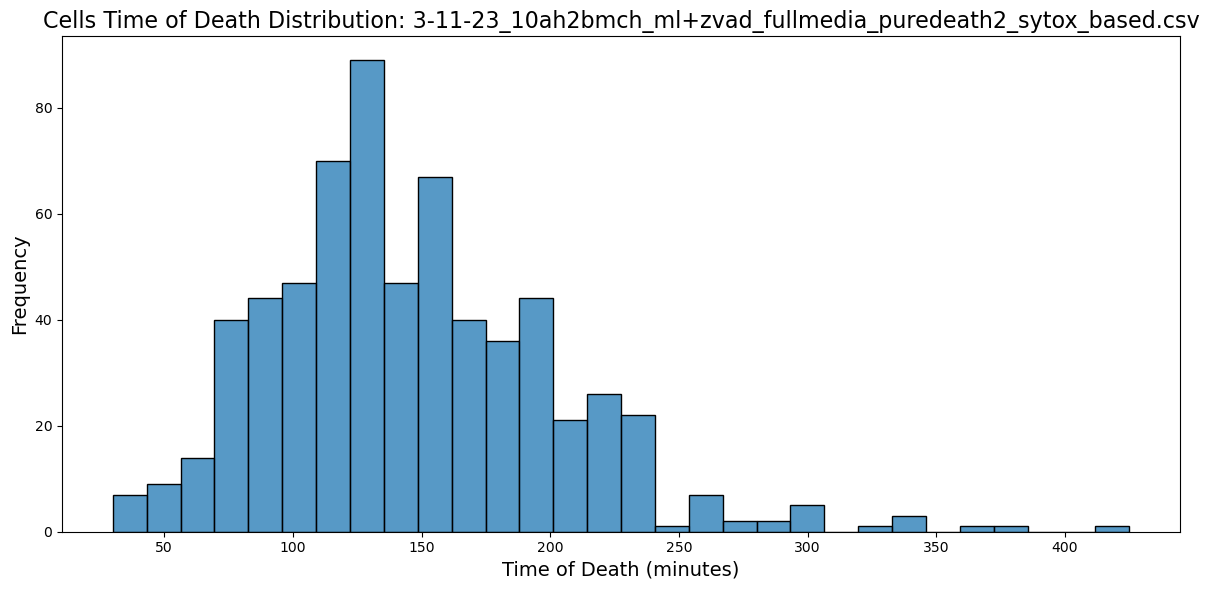

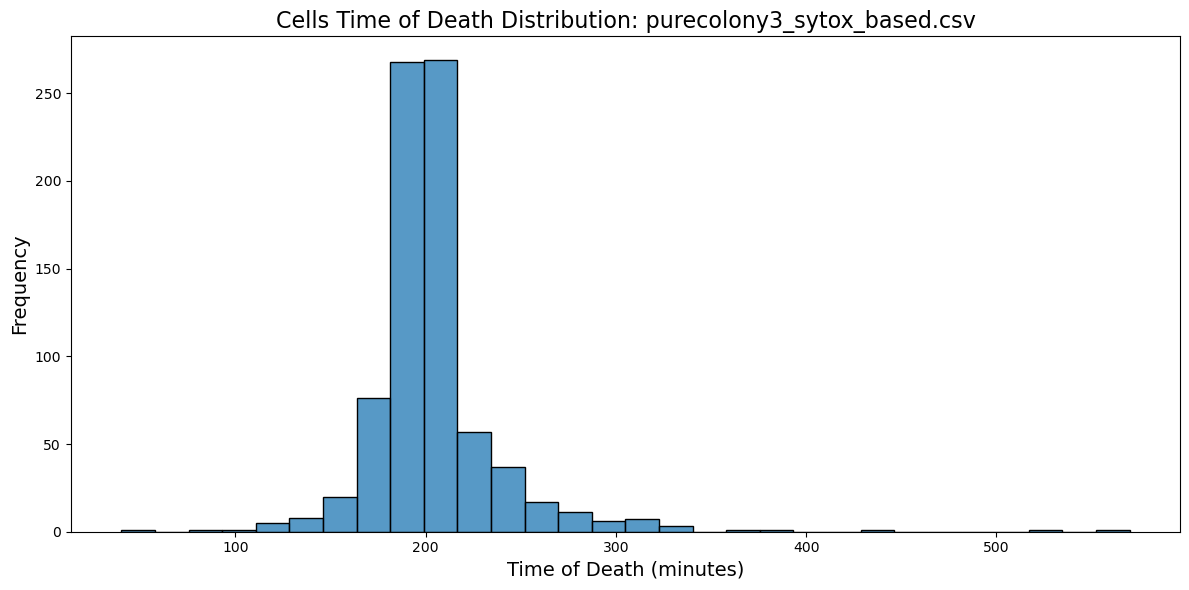

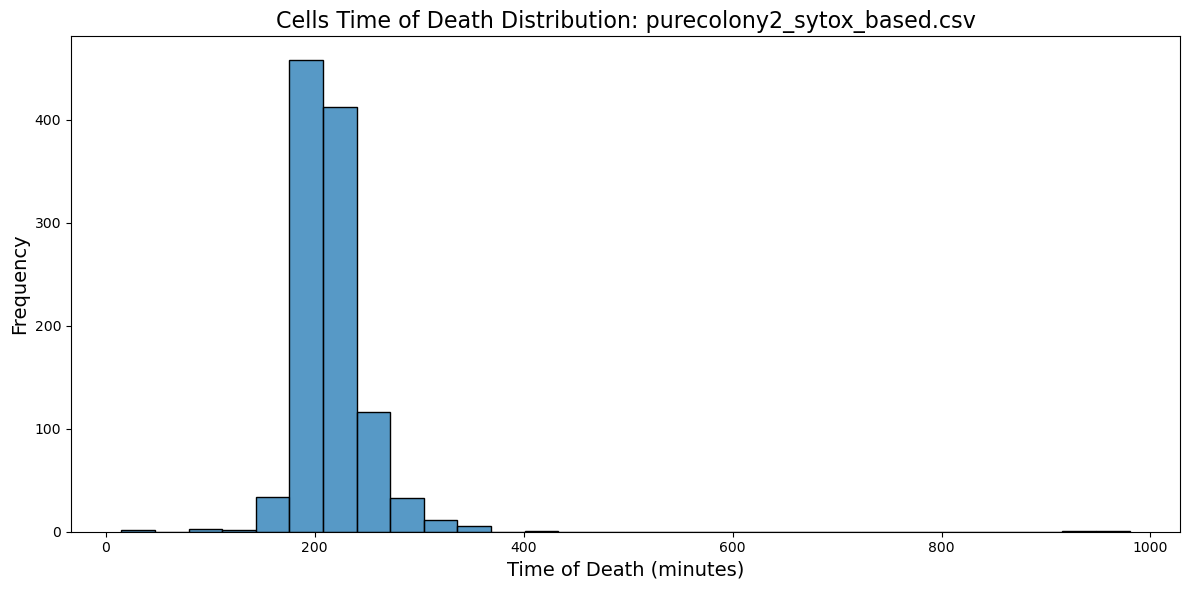

In [5]:
single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    if '_mixed' in file or 'outl' in file:
        
        
        csv = pd.read_csv(os.path.join(single_exp_full_paths, file))
        csv = csv[csv["Mode"].str.contains("apop|necr", case=False, regex=True)]
        death_mode = csv["Mode"].values
        # Plot cells_time_of_death distribution with colors based on death_mode
        plt.figure(figsize=(12, 6))
        sns.histplot(data=csv, x="death_time", hue="Mode", palette={"necrosis": "green", "apoptosis": "blue", "apoptotic": "blue"}, kde=False, bins=30)
        plt.title(f"Cells Time of Death Distribution: {file}", fontsize=16)
        plt.xlabel("Time of Death (minutes)", fontsize=14)
        plt.ylabel("Frequency", fontsize=14)
        plt.tight_layout()
        plt.grid(False)
        plt.show()
    else:
        csv = pd.read_csv(os.path.join(single_exp_full_paths, file))
        plt.figure(figsize=(12, 6))
        sns.histplot(data=csv, x="death_time",  kde=False, bins=30)
        plt.title(f"Cells Time of Death Distribution: {file}", fontsize=16)
        plt.xlabel("Time of Death (minutes)", fontsize=14)
        plt.ylabel("Frequency", fontsize=14)
        plt.tight_layout()
        plt.grid(False)
        plt.show()
